# **PROJECT ASSIGNMENT 2 A Go to Market Strategy for XYZ Company to Acquire a Cab Company**

XYZ Company plans on acquiring a cab company. It has provided multiple data sets on ytwo different cab companies. Tho objective of this project is to dtermine which company is the best acquisition for XYZ

Cab medallions are typically managed and recorded by local government agencies responsible for transportation and taxi licensing. For example, in New York City, the NYC Taxi and Limousine Commission (TLC) oversees the issuance and regulation of taxi medallions. The data related to these medallions is often available through open data portals such as the NYC Open Data website.

# **Downloading and Accessing the Dataset for this Project**

This project clones an existing github repository from DataGlacier called https://github.com/DataGlacier/DataSets.git This repository is generated as a local repo on my Google drive rather than on my computer. The easiest way to do this is to fork from github and import the repository to Bitbucket. Once this is done, make a directory /content/drive/MyDrive/DATAGLACIER/repository/G2M/DataSets. Download the files to this directory one by one or clone the full repository.

In [1]:
# Clone the Version Control Repository from data glacier
# ! executes shell commands

In [2]:
# install git
!apt-get install git

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.12).
0 upgraded, 0 newly installed, 0 to remove and 20 not upgraded.


In [3]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Do this just once to download the US Holidays
!pip install azureml-core
!pip install azureml-opendatasets

In [4]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import os

In [5]:
# Verify import path
import_path = '/content/drive/MyDrive/DATAGLACIER/repository/G2M/DataSets'
print(os.path.exists(import_path))  # Output: True if the file exists

#make the path if it does not exist
if not os.path.exists(import_path):
    os.makedirs(import_path)
    print(f"Directory '{import_path}' created successfully.")
else:
    print(f"Directory '{import_path}' already exists.")

True
Directory '/content/drive/MyDrive/DATAGLACIER/repository/G2M/DataSets' already exists.


In [6]:
# Navigate to google drive as the Target Directory
%cd /content/drive/MyDrive/DATAGLACIER/repository/G2M

/content/drive/MyDrive/DATAGLACIER/repository/G2M


In [7]:
# Use the Bash to list the filenames in the G2M directory
! ls

Cab_Data.csv	 City.csv	  DataSets	      us_holidays_df.csv
Cab_Data.gsheet  Customer_ID.csv  Transaction_ID.csv


# **Dataset Files**

There are 4 original files in this dataset: Cab_Data.csv, City.csv, Customer_ID.csv, and Transaction_ID.csv. Each of these files is explored by converting them to data frames. The time period of data is from 31/01/2016 to 31/12/2018.


# **Explore Each Dataset and Make a Master Dataset**

Build data frames for each of the datasets and explore the data frames. Convert Cab_Data.csv to pandas data frame cab_df. Explore the cab_df dataframe. *Note* The Date of Travel attribute in Cab_Data.csv was converted to a date timestamp using Excel.

**Build Dataframes for each given dataset**

In [8]:
# Build the data frame for Cab_Data.csv and deal with time stamp
import pandas as pd

# Build the data frame for Cab_Data.csv
cab_df = pd.read_csv('/content/drive/MyDrive/DATAGLACIER/repository/G2M/Cab_Data.csv')

# Convert 'Date Time Stamp' to datetime objects
cab_df['Date Time Stamp'] = pd.to_datetime(cab_df['Date Time Stamp'])

# Extract date and time components
cab_df['date'] = cab_df['Date Time Stamp'].dt.date
cab_df['time'] = cab_df['Date Time Stamp'].dt.time
cab_df['month'] = cab_df['Date Time Stamp'].dt.month
cab_df['year'] = cab_df['Date Time Stamp'].dt.year
cab_df['day'] = cab_df['Date Time Stamp'].dt.day
cab_df['day_name'] = cab_df['Date Time Stamp'].dt.day_name()
cab_df['month_name'] = cab_df['Date Time Stamp'].dt.month_name()
cab_df['day_code'] = cab_df['Date Time Stamp'].dt.dayofweek  # 0=Monday, 6=Sunday
# Display the updated DataFrame
cab_df.head()

<ipython-input-8-6f9f2b5f370c>:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cab_df['Date Time Stamp'] = pd.to_datetime(cab_df['Date Time Stamp'])


,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,time,month,year,day,day_name,month_name,day_code
0,10000011,42377,2016-01-08,Pink Cab,ATLANTA GA,30.45,370.95,313.635,2016-01-08,00:00:00,1,2016,8,Friday,January,4
1,10000012,42375,2016-01-06,Pink Cab,ATLANTA GA,28.62,358.52,334.854,2016-01-06,00:00:00,1,2016,6,Wednesday,January,2
2,10000013,42371,2016-01-02,Pink Cab,ATLANTA GA,9.04,125.20,97.632,2016-01-02,00:00:00,1,2016,2,Saturday,January,5
3,10000014,42376,2016-01-07,Pink Cab,ATLANTA GA,33.17,377.40,351.602,2016-01-07,00:00:00,1,2016,7,Thursday,January,3
4,10000015,42372,2016-01-03,Pink Cab,ATLANTA GA,8.73,114.62,97.776,2016-01-03,00:00:00,1,2016,3,Sunday,January,6


In [9]:
cab_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359392 entries, 0 to 359391
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Transaction ID   359392 non-null  int64         
 1   Date of Travel   359392 non-null  int64         
 2   Date Time Stamp  359392 non-null  datetime64[ns]
 3   Company          359392 non-null  object        
 4   City             359392 non-null  object        
 5   KM Travelled     359392 non-null  float64       
 6   Price Charged    359392 non-null  float64       
 7   Cost of Trip     359392 non-null  float64       
 8   date             359392 non-null  object        
 9   time             359392 non-null  object        
 10  month            359392 non-null  int32         
 11  year             359392 non-null  int32         
 12  day              359392 non-null  int32         
 13  day_name         359392 non-null  object        
 14  month_name       359

In [10]:
# Build the transaction data frame
transaction_df = pd.read_csv('/content/drive/MyDrive/DATAGLACIER/repository/G2M/Transaction_ID.csv')
transaction_df.head()

,Transaction ID,Customer ID,Payment_Mode
0,10000011,29290,Card
1,10000012,27703,Card
2,10000013,28712,Cash
3,10000014,28020,Cash
4,10000015,27182,Card


In [11]:
# Build the customer data frame
customer_df = pd.read_csv('/content/drive/MyDrive/DATAGLACIER/repository/G2M/Customer_ID.csv')
customer_df.head()

,Customer ID,Gender,Age,Income (USD/Month)
0,29290,Male,28,10813
1,27703,Male,27,9237
2,28712,Male,53,11242
3,28020,Male,23,23327
4,27182,Male,33,8536


In [12]:
# build the city data frame
city_df = pd.read_csv('/content/drive/MyDrive/DATAGLACIER/repository/G2M/City.csv')
city_df.head()

,City,Population,Users
0,NEW YORK NY,"8,405,837","302,149"
1,CHICAGO IL,"1,955,130","164,468"
2,LOS ANGELES CA,"1,595,037","144,132"
3,MIAMI FL,"1,339,155","17,675"
4,SILICON VALLEY,"1,177,609","27,247"


**Merge the Data Frames**

Merge cab_df with transaction_df via Transaction ID. Merge cab_transaction_df with customer_df via Customer ID.

In [13]:
# Merge cab_df and transaction_df
cab_transaction_df = pd.merge(cab_df, transaction_df, on='Transaction ID')
cab_transaction_df.head()

,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,time,month,year,day,day_name,month_name,day_code,Customer ID,Payment_Mode
0,10000011,42377,2016-01-08,Pink Cab,ATLANTA GA,30.45,370.95,313.635,2016-01-08,00:00:00,1,2016,8,Friday,January,4,29290,Card
1,10000012,42375,2016-01-06,Pink Cab,ATLANTA GA,28.62,358.52,334.854,2016-01-06,00:00:00,1,2016,6,Wednesday,January,2,27703,Card
2,10000013,42371,2016-01-02,Pink Cab,ATLANTA GA,9.04,125.20,97.632,2016-01-02,00:00:00,1,2016,2,Saturday,January,5,28712,Cash
3,10000014,42376,2016-01-07,Pink Cab,ATLANTA GA,33.17,377.40,351.602,2016-01-07,00:00:00,1,2016,7,Thursday,January,3,28020,Cash
4,10000015,42372,2016-01-03,Pink Cab,ATLANTA GA,8.73,114.62,97.776,2016-01-03,00:00:00,1,2016,3,Sunday,January,6,27182,Card


In [14]:
# Merge cab_transaction_df and customer_df
cab_transaction_customer_df = pd.merge(cab_transaction_df, customer_df, on='Customer ID')
cab_transaction_customer_df.head()

,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,time,...,year,day,day_name,month_name,day_code,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month)
0,10000011,42377,2016-01-08,Pink Cab,ATLANTA GA,30.45,370.95,313.635,2016-01-08,00:00:00,...,2016,8,Friday,January,4,29290,Card,Male,28,10813
1,10000012,42375,2016-01-06,Pink Cab,ATLANTA GA,28.62,358.52,334.854,2016-01-06,00:00:00,...,2016,6,Wednesday,January,2,27703,Card,Male,27,9237
2,10000013,42371,2016-01-02,Pink Cab,ATLANTA GA,9.04,125.20,97.632,2016-01-02,00:00:00,...,2016,2,Saturday,January,5,28712,Cash,Male,53,11242
3,10000014,42376,2016-01-07,Pink Cab,ATLANTA GA,33.17,377.40,351.602,2016-01-07,00:00:00,...,2016,7,Thursday,January,3,28020,Cash,Male,23,23327
4,10000015,42372,2016-01-03,Pink Cab,ATLANTA GA,8.73,114.62,97.776,2016-01-03,00:00:00,...,2016,3,Sunday,January,6,27182,Card,Male,33,8536


In [15]:
# Merge cab_transaction_df and customer_df
master1_df = pd.merge(cab_transaction_customer_df, city_df, on='City')
master1_df.head()

,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,time,...,day_name,month_name,day_code,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users
0,10000011,42377,2016-01-08,Pink Cab,ATLANTA GA,30.45,370.95,313.635,2016-01-08,00:00:00,...,Friday,January,4,29290,Card,Male,28,10813,"814,885","24,701"
1,10000012,42375,2016-01-06,Pink Cab,ATLANTA GA,28.62,358.52,334.854,2016-01-06,00:00:00,...,Wednesday,January,2,27703,Card,Male,27,9237,"814,885","24,701"
2,10000013,42371,2016-01-02,Pink Cab,ATLANTA GA,9.04,125.20,97.632,2016-01-02,00:00:00,...,Saturday,January,5,28712,Cash,Male,53,11242,"814,885","24,701"
3,10000014,42376,2016-01-07,Pink Cab,ATLANTA GA,33.17,377.40,351.602,2016-01-07,00:00:00,...,Thursday,January,3,28020,Cash,Male,23,23327,"814,885","24,701"
4,10000015,42372,2016-01-03,Pink Cab,ATLANTA GA,8.73,114.62,97.776,2016-01-03,00:00:00,...,Sunday,January,6,27182,Card,Male,33,8536,"814,885","24,701"


In [16]:
# Modify the Master with Additions
master1_df['Profit'] = master1_df['Price Charged'] - master1_df['Cost of Trip']
master1_df['Profit Per KM'] = master1_df['Profit'] / master1_df['KM Travelled']
master1_df['Miles Travelled'] = master1_df['KM Travelled'] / 1.609
master1_df.head()


,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,time,...,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled
0,10000011,42377,2016-01-08,Pink Cab,ATLANTA GA,30.45,370.95,313.635,2016-01-08,00:00:00,...,29290,Card,Male,28,10813,"814,885","24,701",57.315,1.882266,18.924798
1,10000012,42375,2016-01-06,Pink Cab,ATLANTA GA,28.62,358.52,334.854,2016-01-06,00:00:00,...,27703,Card,Male,27,9237,"814,885","24,701",23.666,0.826904,17.787446
2,10000013,42371,2016-01-02,Pink Cab,ATLANTA GA,9.04,125.20,97.632,2016-01-02,00:00:00,...,28712,Cash,Male,53,11242,"814,885","24,701",27.568,3.049558,5.618397
3,10000014,42376,2016-01-07,Pink Cab,ATLANTA GA,33.17,377.40,351.602,2016-01-07,00:00:00,...,28020,Cash,Male,23,23327,"814,885","24,701",25.798,0.777751,20.615289
4,10000015,42372,2016-01-03,Pink Cab,ATLANTA GA,8.73,114.62,97.776,2016-01-03,00:00:00,...,27182,Card,Male,33,8536,"814,885","24,701",16.844,1.929439,5.425730


In [17]:
master1_df.shape

(359392, 26)

In [18]:
master1_df.nunique()

,0
Transaction ID,359392
Date of Travel,1095
Date Time Stamp,1095
Company,2
City,19
KM Travelled,874
Price Charged,99176
Cost of Trip,16291
date,1095
time,1


# **Master Dataset Section**

In [19]:
# Compare the Transaction IDs in cab_df and master1_df
print("master1_df counts:", master1_df['Transaction ID'].nunique())
print("cab_df counts:", cab_df['Transaction ID'].nunique())

master1_df counts: 359392
cab_df counts: 359392


In [20]:
# output the number of rows and columns
master1_df.shape

(359392, 26)

In [21]:
# output the number of payment modes that are credit card and cash
(master1_df['Payment_Mode'].value_counts())

,count
Payment_Mode,
Card,215504
Cash,143888


In [22]:
# Check for missing values. If the value is not 0, the values are missing
master1_df.isnull().sum()

,0
Transaction ID,0
Date of Travel,0
Date Time Stamp,0
Company,0
City,0
KM Travelled,0
Price Charged,0
Cost of Trip,0
date,0
time,0


In [23]:
#Output the number of rows and columns in master1_df
master1_df.shape

(359392, 26)

In [25]:
# Output the number of unique entries for each attribute in master1_df
master1_df.nunique()

,0
index,359392
Transaction ID,359392
Date of Travel,1095
Date Time Stamp,1095
Company,2
City,19
KM Travelled,874
Price Charged,99176
Cost of Trip,16291
date,1095


In [26]:
# summarize the attributes and datatypes of master1_df
master1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359392 entries, 0 to 359391
Data columns (total 27 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               359392 non-null  int64         
 1   Transaction ID      359392 non-null  int64         
 2   Date of Travel      359392 non-null  int64         
 3   Date Time Stamp     359392 non-null  datetime64[ns]
 4   Company             359392 non-null  object        
 5   City                359392 non-null  object        
 6   KM Travelled        359392 non-null  float64       
 7   Price Charged       359392 non-null  float64       
 8   Cost of Trip        359392 non-null  float64       
 9   date                359392 non-null  object        
 10  time                359392 non-null  object        
 11  month               359392 non-null  int32         
 12  year                359392 non-null  int32         
 13  day                 359392 no

# **Adding US Holidays From Azure**

[Azure Holiday Data Set](https://learn.microsoft.com/en-us/azure/open-datasets/dataset-public-holidays?tabs=azureml-opendatasets)

In [ ]:
# Only use this once the data is stored as a .csv
# This is azure Test for the only US holiday this year
from azureml.opendatasets import PublicHolidays

from datetime import datetime
from dateutil import parser
from dateutil.relativedelta import relativedelta


end_date = datetime.today()
start_date = datetime.today() - relativedelta(months=1)
hol = PublicHolidays(start_date=start_date, end_date=end_date)
hol_test_df = hol.to_pandas_dataframe()

In [ ]:
# This code specifies the dates of 1-31-2016 to 12-31-2018 for azure holidays package
from azureml.opendatasets import PublicHolidays
from datetime import datetime

# Update start and end dates to the desired range
start_date = datetime(2016, 1, 31)  # January 31, 2016
end_date = datetime(2018, 12, 31)  # December 31, 2018

# Create PublicHolidays object with the updated dates
hol = PublicHolidays(start_date=start_date, end_date=end_date)
hol_df = hol.to_pandas_dataframe()

In [ ]:
# Make US Holidays data frame
us_holidays_df = hol_df[hol_df['countryOrRegion'] == 'United States']
us_holidays_df.head(10)

In [29]:
# Read us_holidays_df.csv
hol_test_df = pd.read_csv('/content/drive/MyDrive/DATAGLACIER/repository/G2M/us_holidays_df.csv')

In [116]:
# Output the first 5 rows of hol_test_df
hol_test_df.head(32)
# Columbus day and veteran's day are not paid time off

,holidayName,normalizeHolidayName,countryRegionCode,date
0,Washington's Birthday,Washington's Birthday,US,2016-01-08
1,Memorial Day,Memorial Day,US,2016-01-06
2,Independence Day,Independence Day,US,2016-01-02
3,Labor Day,Labor Day,US,2016-01-07
4,Columbus Day,Columbus Day,US,2016-01-03
5,Veterans Day,Veterans Day,US,2016-01-07
6,Thanksgiving,Thanksgiving,US,2016-01-03
7,Christmas Day,Christmas Day,US,2016-01-07
8,Christmas Day (Observed),Christmas Day,US,2016-01-12
9,New Year's Day,New Year's Day,US,2016-01-06


In [117]:
# Count number of holidays
hol_test_df['holidayName'].nunique()

13

In [37]:
# Summarize hol_test_df
hol_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   countryOrRegion       32 non-null     object
 1   holidayName           32 non-null     object
 2   normalizeHolidayName  32 non-null     object
 3   isPaidTimeOff         30 non-null     object
 4   countryRegionCode     32 non-null     object
 5   date                  32 non-null     object
dtypes: object(6)
memory usage: 1.6+ KB


In [38]:
# Give the number of holidays in this 3 year time period
hol_test_df['date'].unique()

array(['2016-02-15', '2016-05-30', '2016-07-04', '2016-09-05',
       '2016-10-10', '2016-11-11', '2016-11-24', '2016-12-25',
       '2016-12-26', '2017-01-01', '2017-01-02', '2017-01-16',
       '2017-02-20', '2017-05-29', '2017-07-04', '2017-09-04',
       '2017-10-09', '2017-11-10', '2017-11-11', '2017-11-23',
       '2017-12-25', '2018-01-01', '2018-01-15', '2018-02-19',
       '2018-05-28', '2018-07-04', '2018-09-03', '2018-10-08',
       '2018-11-11', '2018-11-12', '2018-11-22', '2018-12-25'],
      dtype=object)

In [41]:
# Count the number of holidays in this 3 year time period
hol_test_df['date'].nunique()

32

In [56]:
# Drop countryOrRegion
hol_test_df.drop('countryOrRegion', axis=1, inplace=True)
holiday_df = hol_test_df
holiday_df.head()

,holidayName,normalizeHolidayName,isPaidTimeOff,countryRegionCode,date
0,Washington's Birthday,Washington's Birthday,True,US,2016-02-15
1,Memorial Day,Memorial Day,True,US,2016-05-30
2,Independence Day,Independence Day,True,US,2016-07-04
3,Labor Day,Labor Day,True,US,2016-09-05
4,Columbus Day,Columbus Day,False,US,2016-10-10


from matplotlib import pyplot as plt
import seaborn as sns
_df_0.groupby('holidayName').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('normalizeHolidayName').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_2.groupby('isPaidTimeOff').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_3.groupby('date').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['date']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'date'}, axis=1)
              .sort_values('date', ascending=True))
  xs = counted['date']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_6.sort_values('date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('isPaidTimeOff')):
  _plot_series(series, series_name, i)
  fig.legend(title='isPaidTimeOff', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['date']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'date'}, axis=1)
              .sort_values('date', ascending=True))
  xs = counted['date']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_7.sort_values('date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('date')):
  _plot_series(series, series_name, i)
  fig.legend(title='date', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['normalizeHolidayName'].value_counts()
    for x_label, grp in _df_8.groupby('holidayName')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('holidayName')
_ = plt.ylabel('normalizeHolidayName')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['isPaidTimeOff'].value_counts()
    for x_label, grp in _df_9.groupby('normalizeHolidayName')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('normalizeHolidayName')
_ = plt.ylabel('isPaidTimeOff')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['date'].value_counts()
    for x_label, grp in _df_10.groupby('isPaidTimeOff')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('isPaidTimeOff')
_ = plt.ylabel('date')

In [72]:
# Drop countryOrRegion
holiday_df.drop('isPaidTimeOff', axis=1, inplace=True)
holiday_df.head()

,holidayName,normalizeHolidayName,countryRegionCode,date
0,Washington's Birthday,Washington's Birthday,US,2016-01-08
1,Memorial Day,Memorial Day,US,2016-01-06
2,Independence Day,Independence Day,US,2016-01-02
3,Labor Day,Labor Day,US,2016-01-07
4,Columbus Day,Columbus Day,US,2016-01-03


In [118]:
# change 'date' into 'holiday_date'
holiday_df.rename(columns={'date': 'holiday_date'}, inplace=True)
holiday_df.head()

,holidayName,normalizeHolidayName,countryRegionCode,holiday_date
0,Washington's Birthday,Washington's Birthday,US,2016-01-08
1,Memorial Day,Memorial Day,US,2016-01-06
2,Independence Day,Independence Day,US,2016-01-02
3,Labor Day,Labor Day,US,2016-01-07
4,Columbus Day,Columbus Day,US,2016-01-03


In [73]:
# Convert the 'date' attributes to matiching types for a successful merge
#holiday_df['date'] = pd.to_datetime(holiday_df['date'])
#master1_df['date'] = pd.to_datetime(master1_df['date'])

In [119]:
# Concatenate master1_df and holiday_df
master2_df = pd.concat([master1_df, holiday_df], axis=1)
master2_df.head()

,index,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,...,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled,holidayName,normalizeHolidayName,countryRegionCode,holiday_date
0,0,10000011,42377,2016-01-08,Pink Cab,ATLANTA GA,30.45,370.95,313.635,2016-01-08,...,10813,"814,885","24,701",57.315,1.882266,18.924798,Washington's Birthday,Washington's Birthday,US,2016-01-08
1,1,10000012,42375,2016-01-06,Pink Cab,ATLANTA GA,28.62,358.52,334.854,2016-01-06,...,9237,"814,885","24,701",23.666,0.826904,17.787446,Memorial Day,Memorial Day,US,2016-01-06
2,2,10000013,42371,2016-01-02,Pink Cab,ATLANTA GA,9.04,125.20,97.632,2016-01-02,...,11242,"814,885","24,701",27.568,3.049558,5.618397,Independence Day,Independence Day,US,2016-01-02
3,3,10000014,42376,2016-01-07,Pink Cab,ATLANTA GA,33.17,377.40,351.602,2016-01-07,...,23327,"814,885","24,701",25.798,0.777751,20.615289,Labor Day,Labor Day,US,2016-01-07
4,4,10000015,42372,2016-01-03,Pink Cab,ATLANTA GA,8.73,114.62,97.776,2016-01-03,...,8536,"814,885","24,701",16.844,1.929439,5.425730,Columbus Day,Columbus Day,US,2016-01-03


In [120]:
# summarize master2_df
master2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359392 entries, 0 to 359391
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   index                 359392 non-null  int64         
 1   Transaction ID        359392 non-null  int64         
 2   Date of Travel        359392 non-null  int64         
 3   Date Time Stamp       359392 non-null  datetime64[ns]
 4   Company               359392 non-null  object        
 5   City                  359392 non-null  object        
 6   KM Travelled          359392 non-null  float64       
 7   Price Charged         359392 non-null  float64       
 8   Cost of Trip          359392 non-null  float64       
 9   date                  359392 non-null  datetime64[ns]
 10  time                  359392 non-null  object        
 11  month                 359392 non-null  int32         
 12  year                  359392 non-null  int32         
 13 

In [121]:
master2_df.shape

(359392, 31)

In [122]:
# check for missing data
master2_df.isnull().sum()

,0
index,0
Transaction ID,0
Date of Travel,0
Date Time Stamp,0
Company,0
City,0
KM Travelled,0
Price Charged,0
Cost of Trip,0
date,0


In [123]:
master1_df.shape

(359392, 27)

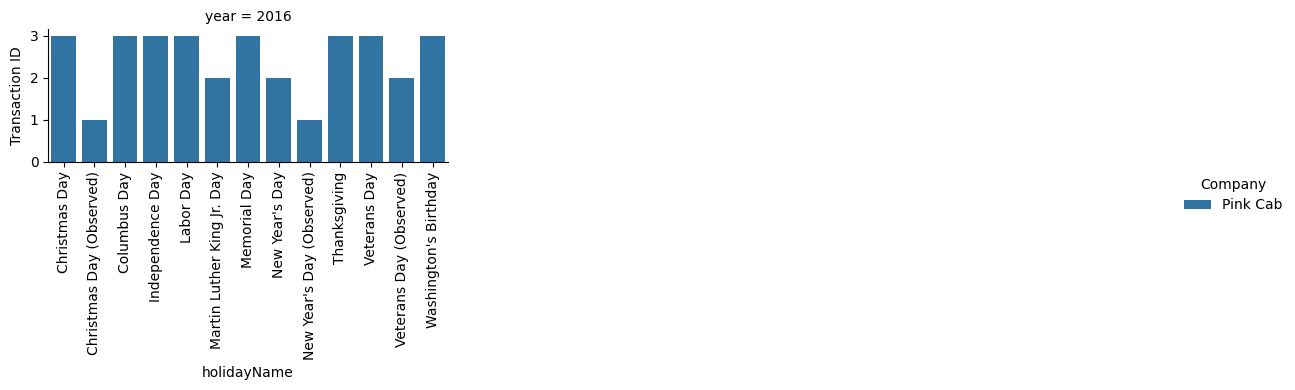

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter data for the years 2016, 2017, and 2018
filtered_data = master2_df[master2_df['year'].isin([2016, 2017, 2018])]

# Group data and count rides by holiday and company for each year
rides_by_holiday_year = filtered_data.groupby(['holidayName', 'Company', 'year'])['Transaction ID'].count().reset_index()

g = sns.catplot(
    x='holidayName',
    y='Transaction ID',
    hue='Company',
    data=rides_by_holiday_year,
    kind='bar',
    col='year',  # Separate charts for each year
    col_wrap=3,   # Wrap columns into 3 mini charts
    height=4,      # Set height of each mini chart
    aspect=1       # Set aspect ratio of each mini chart
)

g.set_xticklabels(rotation=90)  # Rotate x-axis labels for better readability
plt.tight_layout()             # Adjust layout for better spacing
plt.show()

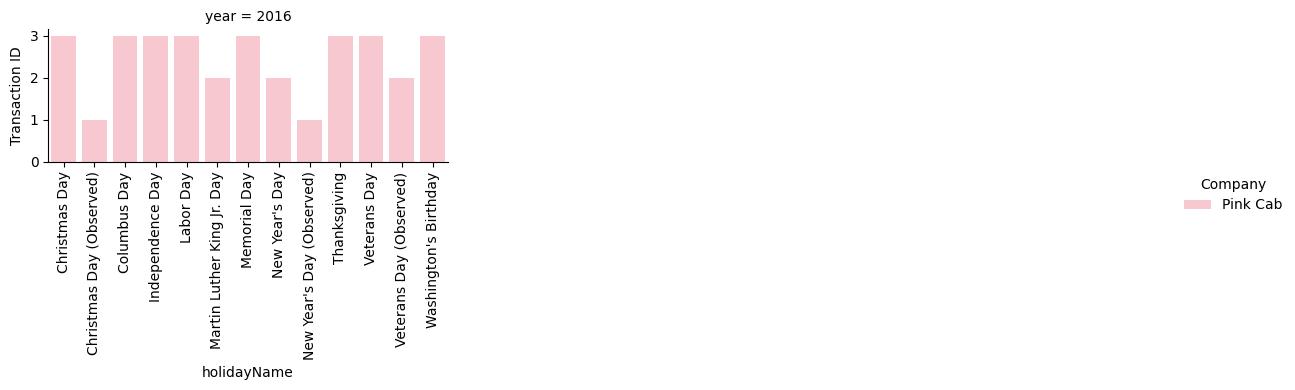

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter data for the years 2016, 2017, and 2018
filtered_data = master2_df[master2_df['year'].isin([2016, 2017, 2018])]

# Group data and count rides by holiday and company for each year
rides_by_holiday_year = filtered_data.groupby(['holidayName', 'Company', 'year'])['Transaction ID'].count().reset_index()

# Define custom color palette
custom_palette = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

g = sns.catplot(
    x='holidayName',
    y='Transaction ID',
    hue='Company',
    data=rides_by_holiday_year,
    kind='bar',
    col='year',  # Separate charts for each year
    col_wrap=3,   # Wrap columns into 3 mini charts
    height=4,      # Set height of each mini chart
    aspect=1,      # Set aspect ratio of each mini chart
    palette=custom_palette  # Apply custom color palette
)

g.set_xticklabels(rotation=90)  # Rotate x-axis labels for better readability
plt.tight_layout()             # Adjust layout for better spacing
plt.show()

<ipython-input-83-da86d4f19be1>:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)  # Rotate x-axis labels
<ipython-input-83-da86d4f19be1>:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)  # Rotate x-axis labels
<ipython-input-83-da86d4f19be1>:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)  # Rotate x-axis labels


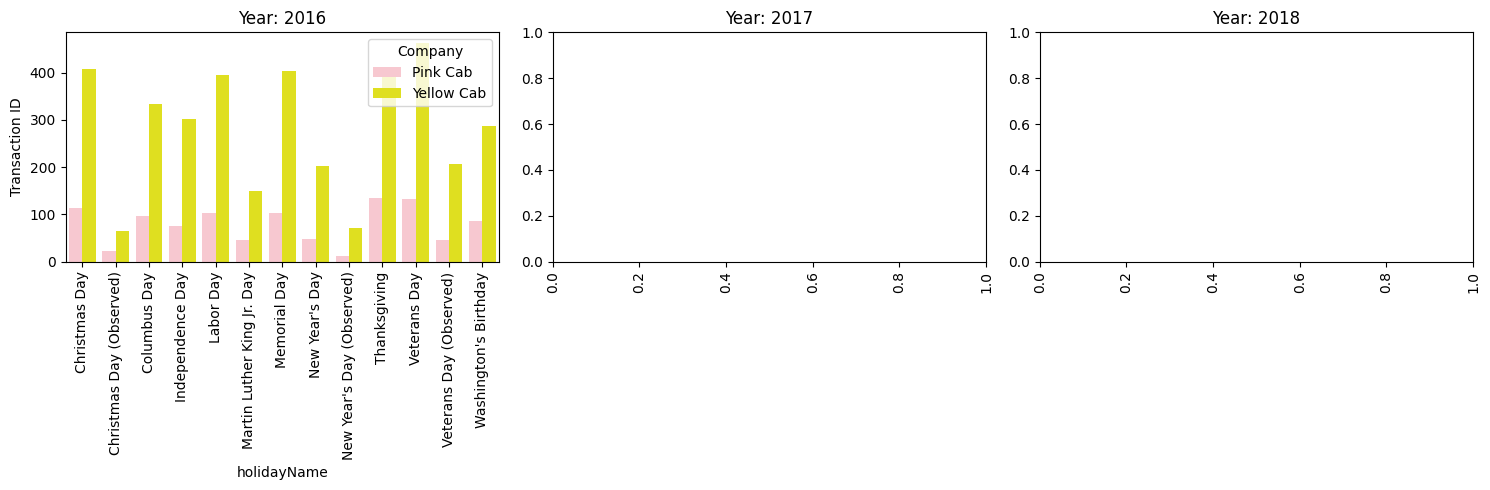

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define custom color palette
custom_palette = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Create a figure with 3 subplots (one for each year)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # Adjust figsize as needed

# Iterate through the desired years
for i, year in enumerate([2016, 2017, 2018]):
    # Filter data for the current year
    filtered_data = master2_df[master2_df['year'] == year]

    # Group data and count rides by holiday and company for the current year
    rides_by_holiday_year = filtered_data.groupby(['holidayName', 'Company'])['Transaction ID'].count().reset_index()

    # Create a miniplot for the current year on the corresponding subplot
    sns.barplot(
        x='holidayName',
        y='Transaction ID',
        hue='Company',
        data=rides_by_holiday_year,
        ax=axes[i],  # Assign the plot to the correct subplot
        palette=custom_palette
    )

    axes[i].set_title(f'Year: {year}')  # Set title for each subplot
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)  # Rotate x-axis labels

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

<ipython-input-84-408e54979950>:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)  # Rotate x-axis labels
<ipython-input-84-408e54979950>:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)  # Rotate x-axis labels
<ipython-input-84-408e54979950>:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)  # Rotate x-axis labels


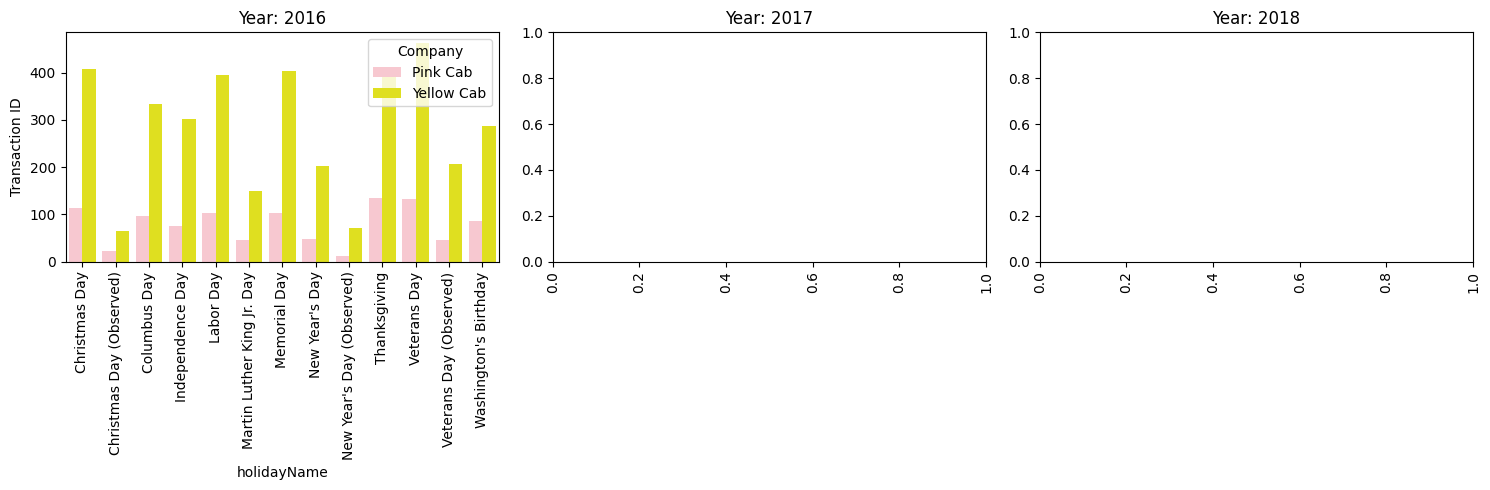

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define custom color palette
custom_palette = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Create a figure with 3 subplots (one for each year)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # Adjust figsize as needed

# Iterate through the desired years
for i, year in enumerate([2016, 2017, 2018]):
    # Filter data for the current year
    filtered_data = master2_df[master2_df['year'] == year]

    # Group data and count rides by holiday and company for the current year
    rides_by_holiday_year = filtered_data.groupby(['holidayName', 'Company'])['Transaction ID'].count().reset_index()

    # Create a miniplot for the current year on the corresponding subplot
    sns.barplot(
        x='holidayName',
        y='Transaction ID',
        hue='Company',
        data=rides_by_holiday_year,
        ax=axes[i],  # Assign the plot to the correct subplot
        palette=custom_palette
    )

    axes[i].set_title(f'Year: {year}')  # Set title for each subplot
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)  # Rotate x-axis labels

plt.tight_layout()  # Adjust layout for better spacing
plt.show()        # Display the figure


/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


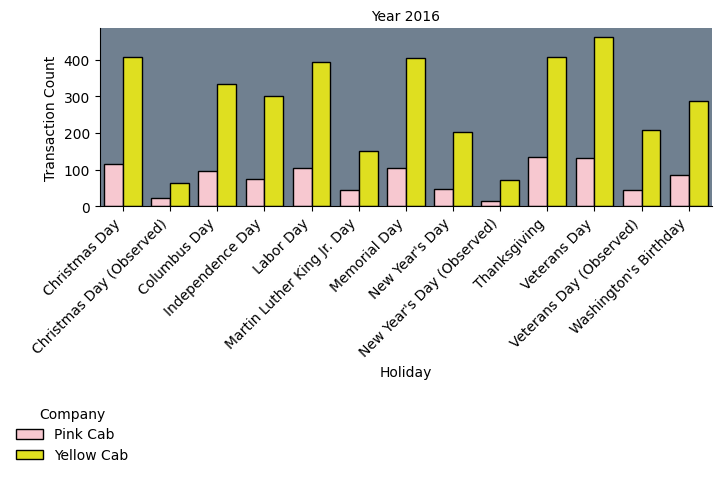

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker

# Filter master2_df to keep only rows with holiday data
holiday_data = master2_df[master2_df['holidayName'].notnull()]

# Assign color for the different companies
company_colors = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Calculate transaction counts for each holiday, year, and company
holiday_counts = holiday_data.groupby(['year', 'holidayName', 'Company'])['Transaction ID'].count().reset_index()

# Create small multiple plots for each year
g = sns.FacetGrid(holiday_counts, col='year', height=4, aspect=1.5)  # Use FacetGrid for small multiples

# Use sns.barplot to plot transaction counts instead of profit
g.map(sns.barplot, 'holidayName', 'Transaction ID', hue='Company', data=holiday_counts,  # Pass data here
      palette=company_colors, edgecolor='black', errorbar=None)

g.set_titles("Year {col_name}")  # Set titles for each subplot
g.set_xticklabels(rotation=45, ha='right')  # Rotate x-axis labels
g.set_axis_labels("Holiday", "Transaction Count")  # Set axis labels

# Add a legend and position it in the top left corner
g.add_legend(title='Company', loc='upper left', bbox_to_anchor=(0, 0))

plt.tight_layout()

# Set background color for each subplot
for ax in g.axes.flat:
    ax.set_facecolor('slategray')
    # Format y-axis (optional, if you want to format it)
    # formatter = ticker.StrMethodFormatter('{x:,.0f}')  # Format with comma separator
    # ax.yaxis.set_major_formatter(formatter)

plt.show()

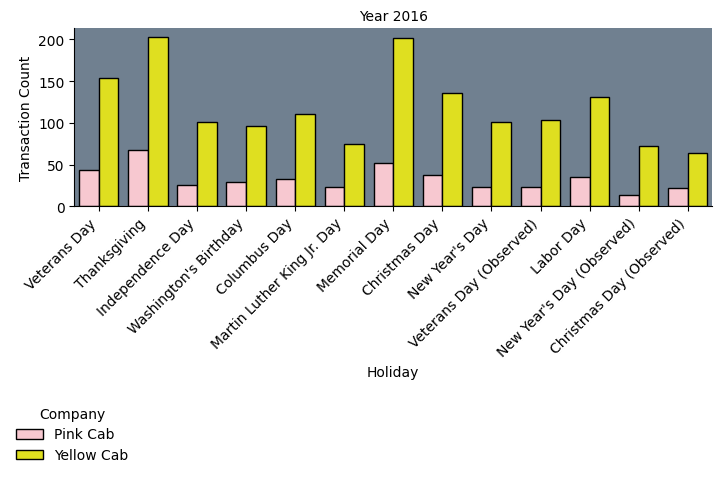

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker

# Filter master2_df to keep only rows with holiday data
holiday_data = master2_df[master2_df['holidayName'].notnull()]

# Assign color for the different companies
company_colors = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Calculate transaction counts for each holiday, year, and company
holiday_counts = holiday_data.groupby(['year', 'holidayName', 'Company', 'date'])['Transaction ID'].count().reset_index() #add date

# Create small multiple plots for each year
g = sns.FacetGrid(holiday_counts, col='year', height=4, aspect=1.5)  # Use FacetGrid for small multiples

# Use sns.barplot to plot transaction counts instead of profit
# Pass the 'data' argument directly to sns.barplot
# Sort by date within each year
def plot_holiday_counts(x, y, hue, data, **kwargs):
    order = data.sort_values(by=['date'])['holidayName'].unique()  # Sort holidayName by date
    sns.barplot(x=x, y=y, hue=hue, data=data, order=order, **kwargs)  # Pass order to barplot

g.map(plot_holiday_counts, 'holidayName', 'Transaction ID', hue='Company', data=holiday_counts,  # Pass data here
      palette=company_colors, edgecolor='black', errorbar=None)

g.set_titles("Year {col_name}")  # Set titles for each subplot
g.set_xticklabels(rotation=45, ha='right')  # Rotate x-axis labels
g.set_axis_labels("Holiday", "Transaction Count")  # Set axis labels

# Add a legend and position it in the top left corner
g.add_legend(title='Company', loc='upper left', bbox_to_anchor=(0, 0))

plt.tight_layout()

# Set background color for each subplot
for ax in g.axes.flat:
    ax.set_facecolor('slategray')
    # Format y-axis (optional, if you want to format it)
    # formatter = ticker.StrMethodFormatter('{x:,.0f}')  # Format with comma separator
    # ax.yaxis.set_major_formatter(formatter)

plt.show()

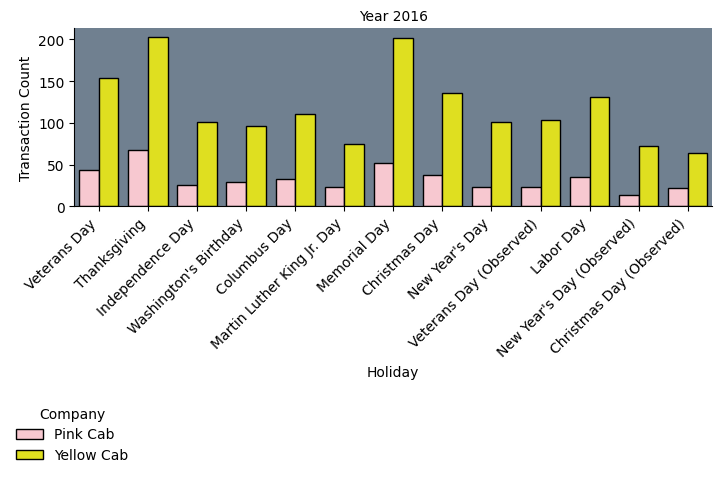

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker

# Filter master2_df to keep only rows with holiday data and within the desired date range
start_date = pd.to_datetime('2016-01-31')
end_date = pd.to_datetime('2018-12-31')
holiday_data = master2_df[(master2_df['holidayName'].notnull()) &
                          (master2_df['date'] >= start_date) &
                          (master2_df['date'] <= end_date)]
# Filter master2_df to keep only rows with holiday data
holiday_data = master2_df[master2_df['holidayName'].notnull()]

# Assign color for the different companies
company_colors = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Calculate transaction counts for each holiday, year, and company
holiday_counts = holiday_data.groupby(['year', 'holidayName', 'Company', 'date'])['Transaction ID'].count().reset_index() #add date

# Create small multiple plots for each year
g = sns.FacetGrid(holiday_counts, col='year', height=4, aspect=1.5)  # Use FacetGrid for small multiples

# Use sns.barplot to plot transaction counts instead of profit
# Pass the 'data' argument directly to sns.barplot
# Sort by date within each year
def plot_holiday_counts(x, y, hue, data, **kwargs):
    order = data.sort_values(by=['date'])['holidayName'].unique()  # Sort holidayName by date
    sns.barplot(x=x, y=y, hue=hue, data=data, order=order, **kwargs)  # Pass order to barplot

g.map(plot_holiday_counts, 'holidayName', 'Transaction ID', hue='Company', data=holiday_counts,  # Pass data here
      palette=company_colors, edgecolor='black', errorbar=None)

g.set_titles("Year {col_name}")  # Set titles for each subplot
g.set_xticklabels(rotation=45, ha='right')  # Rotate x-axis labels
g.set_axis_labels("Holiday", "Transaction Count")  # Set axis labels

# Add a legend and position it in the top left corner
g.add_legend(title='Company', loc='upper left', bbox_to_anchor=(0, 0))

plt.tight_layout()

# Set background color for each subplot
for ax in g.axes.flat:
    ax.set_facecolor('slategray')
    # Format y-axis (optional, if you want to format it)
    # formatter = ticker.StrMethodFormatter('{x:,.0f}')  # Format with comma separator
    # ax.yaxis.set_major_formatter(formatter)

plt.show()


# **Break Out the Company Data**

In [85]:
yellow_cab_df = master1_df[master1_df['Company'] == 'Yellow Cab']
yellow_cab_df.head()

,index,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,...,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled
233,233,10000384,42371,2016-01-02,Yellow Cab,ATLANTA GA,33.93,1341.17,464.1624,2016-01-02,...,27602,Card,Male,23,8542,"814,885","24,701",877.0076,25.847557,21.087632
234,234,10000385,42378,2016-01-09,Yellow Cab,ATLANTA GA,42.18,1412.06,516.2832,2016-01-09,...,27594,Cash,Male,28,3901,"814,885","24,701",895.7768,21.237003,26.215040
235,235,10000386,42372,2016-01-03,Yellow Cab,ATLANTA GA,10.60,364.62,132.2880,2016-01-03,...,27884,Cash,Male,32,13505,"814,885","24,701",232.3320,21.918113,6.587943
236,236,10000387,42375,2016-01-06,Yellow Cab,ATLANTA GA,26.75,838.00,333.8400,2016-01-06,...,28533,Cash,Male,39,28386,"814,885","24,701",504.1600,18.847103,16.625233
237,237,10000388,42376,2016-01-07,Yellow Cab,ATLANTA GA,46.02,1540.61,596.4192,2016-01-07,...,29039,Card,Male,35,17761,"814,885","24,701",944.1908,20.516967,28.601616


In [86]:
yellow_cab_df.tail()

,index,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,...,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled
359387,359387,10440101,43108,2018-01-08,Yellow Cab,WASHINGTON DC,4.80,69.24,63.3600,2018-01-08,...,52392,Cash,Male,24,15651,"418,859","127,001",5.8800,1.225000,2.983219
359388,359388,10440104,43104,2018-01-04,Yellow Cab,WASHINGTON DC,8.40,113.75,106.8480,2018-01-04,...,53286,Cash,Male,32,6528,"418,859","127,001",6.9020,0.821667,5.220634
359389,359389,10440105,43105,2018-01-05,Yellow Cab,WASHINGTON DC,27.75,437.07,349.6500,2018-01-05,...,52265,Cash,Male,56,7966,"418,859","127,001",87.4200,3.150270,17.246737
359390,359390,10440106,43105,2018-01-05,Yellow Cab,WASHINGTON DC,8.80,146.19,114.0480,2018-01-05,...,52175,Card,Male,32,6423,"418,859","127,001",32.1420,3.652500,5.469236
359391,359391,10440107,43102,2018-01-02,Yellow Cab,WASHINGTON DC,12.76,191.58,177.6192,2018-01-02,...,52917,Card,Male,20,11284,"418,859","127,001",13.9608,1.094107,7.930392


In [87]:
print("The number of Transactions for the Yellow Cab:",yellow_cab_df['Transaction ID'].nunique())

The number of Transactions for the Yellow Cab: 274681


In [88]:
pink_cab_df = master1_df[master1_df['Company'] == 'Pink Cab']
pink_cab_df.head()

,index,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,...,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled
0,0,10000011,42377,2016-01-08,Pink Cab,ATLANTA GA,30.45,370.95,313.635,2016-01-08,...,29290,Card,Male,28,10813,"814,885","24,701",57.315,1.882266,18.924798
1,1,10000012,42375,2016-01-06,Pink Cab,ATLANTA GA,28.62,358.52,334.854,2016-01-06,...,27703,Card,Male,27,9237,"814,885","24,701",23.666,0.826904,17.787446
2,2,10000013,42371,2016-01-02,Pink Cab,ATLANTA GA,9.04,125.20,97.632,2016-01-02,...,28712,Cash,Male,53,11242,"814,885","24,701",27.568,3.049558,5.618397
3,3,10000014,42376,2016-01-07,Pink Cab,ATLANTA GA,33.17,377.40,351.602,2016-01-07,...,28020,Cash,Male,23,23327,"814,885","24,701",25.798,0.777751,20.615289
4,4,10000015,42372,2016-01-03,Pink Cab,ATLANTA GA,8.73,114.62,97.776,2016-01-03,...,27182,Card,Male,33,8536,"814,885","24,701",16.844,1.929439,5.425730


In [89]:
pink_cab_df.tail()

,index,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,...,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled
357449,357449,10437610,43106,2018-01-06,Pink Cab,WASHINGTON DC,13.56,184.19,135.600,2018-01-06,...,51142,Card,Female,40,3122,"418,859","127,001",48.590,3.583333,8.427595
357450,357450,10437611,43465,2018-12-31,Pink Cab,WASHINGTON DC,29.68,388.08,302.736,2018-12-31,...,52754,Card,Female,29,19676,"418,859","127,001",85.344,2.875472,18.446240
357451,357451,10437612,43107,2018-01-07,Pink Cab,WASHINGTON DC,28.50,369.04,310.650,2018-01-07,...,53039,Card,Male,37,22765,"418,859","127,001",58.390,2.048772,17.712865
357452,357452,10437614,43102,2018-01-02,Pink Cab,WASHINGTON DC,16.10,194.17,162.610,2018-01-02,...,51766,Cash,Male,18,12364,"418,859","127,001",31.560,1.960248,10.006215
357453,357453,10437615,43105,2018-01-05,Pink Cab,WASHINGTON DC,22.20,287.46,244.200,2018-01-05,...,51996,Cash,Male,36,12905,"418,859","127,001",43.260,1.948649,13.797390


In [90]:
# Print the number of transactions for the pink and yellow cab companies
print("The number of Transactions for the Pink Cab:", pink_cab_df['Transaction ID'].nunique())
print("The number of Transactions for the Yellow Cab:", yellow_cab_df['Transaction ID'].nunique())

The number of Transactions for the Pink Cab: 84711
The number of Transactions for the Yellow Cab: 274681


# **Break out the data into the two cab companies**

In [91]:
# Build yellow_cab_df data frame
yellow_cab_df = master1_df[master1_df['Company'] == 'Yellow Cab']
yellow_cab_df.head()

,index,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,...,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled
233,233,10000384,42371,2016-01-02,Yellow Cab,ATLANTA GA,33.93,1341.17,464.1624,2016-01-02,...,27602,Card,Male,23,8542,"814,885","24,701",877.0076,25.847557,21.087632
234,234,10000385,42378,2016-01-09,Yellow Cab,ATLANTA GA,42.18,1412.06,516.2832,2016-01-09,...,27594,Cash,Male,28,3901,"814,885","24,701",895.7768,21.237003,26.215040
235,235,10000386,42372,2016-01-03,Yellow Cab,ATLANTA GA,10.60,364.62,132.2880,2016-01-03,...,27884,Cash,Male,32,13505,"814,885","24,701",232.3320,21.918113,6.587943
236,236,10000387,42375,2016-01-06,Yellow Cab,ATLANTA GA,26.75,838.00,333.8400,2016-01-06,...,28533,Cash,Male,39,28386,"814,885","24,701",504.1600,18.847103,16.625233
237,237,10000388,42376,2016-01-07,Yellow Cab,ATLANTA GA,46.02,1540.61,596.4192,2016-01-07,...,29039,Card,Male,35,17761,"814,885","24,701",944.1908,20.516967,28.601616


In [92]:
yellow_cab_df.tail()

,index,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,...,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled
359387,359387,10440101,43108,2018-01-08,Yellow Cab,WASHINGTON DC,4.80,69.24,63.3600,2018-01-08,...,52392,Cash,Male,24,15651,"418,859","127,001",5.8800,1.225000,2.983219
359388,359388,10440104,43104,2018-01-04,Yellow Cab,WASHINGTON DC,8.40,113.75,106.8480,2018-01-04,...,53286,Cash,Male,32,6528,"418,859","127,001",6.9020,0.821667,5.220634
359389,359389,10440105,43105,2018-01-05,Yellow Cab,WASHINGTON DC,27.75,437.07,349.6500,2018-01-05,...,52265,Cash,Male,56,7966,"418,859","127,001",87.4200,3.150270,17.246737
359390,359390,10440106,43105,2018-01-05,Yellow Cab,WASHINGTON DC,8.80,146.19,114.0480,2018-01-05,...,52175,Card,Male,32,6423,"418,859","127,001",32.1420,3.652500,5.469236
359391,359391,10440107,43102,2018-01-02,Yellow Cab,WASHINGTON DC,12.76,191.58,177.6192,2018-01-02,...,52917,Card,Male,20,11284,"418,859","127,001",13.9608,1.094107,7.930392


In [93]:
# Calculate daily profit for yellow_cab_df
daily_profit_yellow = yellow_cab_df.groupby('date')['Profit'].sum()
daily_profit_yellow

,Profit
date,
2016-01-02,45295.6412
2016-01-03,38449.5288
2016-01-04,3650.2012
2016-01-05,11338.1156
2016-01-06,18663.4464
...,...
2018-12-27,28057.6524
2018-12-28,100411.4156
2018-12-29,98814.0764


In [94]:
# Calculate monthly profit for yellow_cab_df
monthly_profit_yellow = yellow_cab_df.groupby('month')['Profit'].sum()
monthly_profit_yellow

,Profit
month,
1,3.358436e+06
2,2.975979e+06
3,3.151215e+06
4,3.075543e+06
5,3.983544e+06
6,3.580338e+06
7,2.861562e+06
8,2.856271e+06
9,4.142382e+06


In [95]:
# Calculate daily profit for each city for yellow_cab_df
daily_profit_city_yellow = yellow_cab_df.groupby(['date', 'City'])['Profit'].sum()
daily_profit_city_yellow

date        City          
2016-01-02  ATLANTA GA        2766.5256
            BOSTON MA         1705.3696
            CHICAGO IL        5815.3804
            DALLAS TX         2254.3800
            DENVER CO          447.3224
                                ...    
2018-12-31  SAN DIEGO CA       248.0992
            SEATTLE WA         181.2520
            SILICON VALLEY     614.7944
            TUCSON AZ          178.7020
            WASHINGTON DC      869.7888
Name: Profit, Length: 17239, dtype: float64

In [96]:
# Calculate monthly profit for each city for yellow_cab_df
monthly_profit_city_yellow = yellow_cab_df.groupby(['month', 'City'])['Profit'].sum()
monthly_profit_city_yellow

month  City          
1      ATLANTA GA         73965.7496
       AUSTIN TX          30821.7716
       BOSTON MA         124487.5156
       CHICAGO IL        383122.0924
       DALLAS TX          97203.4480
                            ...     
12     SAN DIEGO CA       71875.9236
       SEATTLE WA         46666.2188
       SILICON VALLEY    124320.3876
       TUCSON AZ           8321.0372
       WASHINGTON DC     260280.8520
Name: Profit, Length: 228, dtype: float64

In [97]:
# Build pink_cab_df data frame
pink_cab_df = master1_df[master1_df['Company'] == 'Pink Cab']
pink_cab_df.head()

,index,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,...,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled
0,0,10000011,42377,2016-01-08,Pink Cab,ATLANTA GA,30.45,370.95,313.635,2016-01-08,...,29290,Card,Male,28,10813,"814,885","24,701",57.315,1.882266,18.924798
1,1,10000012,42375,2016-01-06,Pink Cab,ATLANTA GA,28.62,358.52,334.854,2016-01-06,...,27703,Card,Male,27,9237,"814,885","24,701",23.666,0.826904,17.787446
2,2,10000013,42371,2016-01-02,Pink Cab,ATLANTA GA,9.04,125.20,97.632,2016-01-02,...,28712,Cash,Male,53,11242,"814,885","24,701",27.568,3.049558,5.618397
3,3,10000014,42376,2016-01-07,Pink Cab,ATLANTA GA,33.17,377.40,351.602,2016-01-07,...,28020,Cash,Male,23,23327,"814,885","24,701",25.798,0.777751,20.615289
4,4,10000015,42372,2016-01-03,Pink Cab,ATLANTA GA,8.73,114.62,97.776,2016-01-03,...,27182,Card,Male,33,8536,"814,885","24,701",16.844,1.929439,5.425730


In [98]:
pink_cab_df.tail()

,index,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,...,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled
357449,357449,10437610,43106,2018-01-06,Pink Cab,WASHINGTON DC,13.56,184.19,135.600,2018-01-06,...,51142,Card,Female,40,3122,"418,859","127,001",48.590,3.583333,8.427595
357450,357450,10437611,43465,2018-12-31,Pink Cab,WASHINGTON DC,29.68,388.08,302.736,2018-12-31,...,52754,Card,Female,29,19676,"418,859","127,001",85.344,2.875472,18.446240
357451,357451,10437612,43107,2018-01-07,Pink Cab,WASHINGTON DC,28.50,369.04,310.650,2018-01-07,...,53039,Card,Male,37,22765,"418,859","127,001",58.390,2.048772,17.712865
357452,357452,10437614,43102,2018-01-02,Pink Cab,WASHINGTON DC,16.10,194.17,162.610,2018-01-02,...,51766,Cash,Male,18,12364,"418,859","127,001",31.560,1.960248,10.006215
357453,357453,10437615,43105,2018-01-05,Pink Cab,WASHINGTON DC,22.20,287.46,244.200,2018-01-05,...,51996,Cash,Male,36,12905,"418,859","127,001",43.260,1.948649,13.797390


In [99]:
# Calculate daily profit for pink_cab_df
daily_profit_pink = pink_cab_df.groupby('date')['Profit'].sum()
daily_profit_pink

,Profit
date,
2016-01-02,4809.421
2016-01-03,10620.582
2016-01-04,428.591
2016-01-05,745.359
2016-01-06,2336.981
...,...
2018-12-27,4299.130
2018-12-28,18478.900
2018-12-29,19399.999


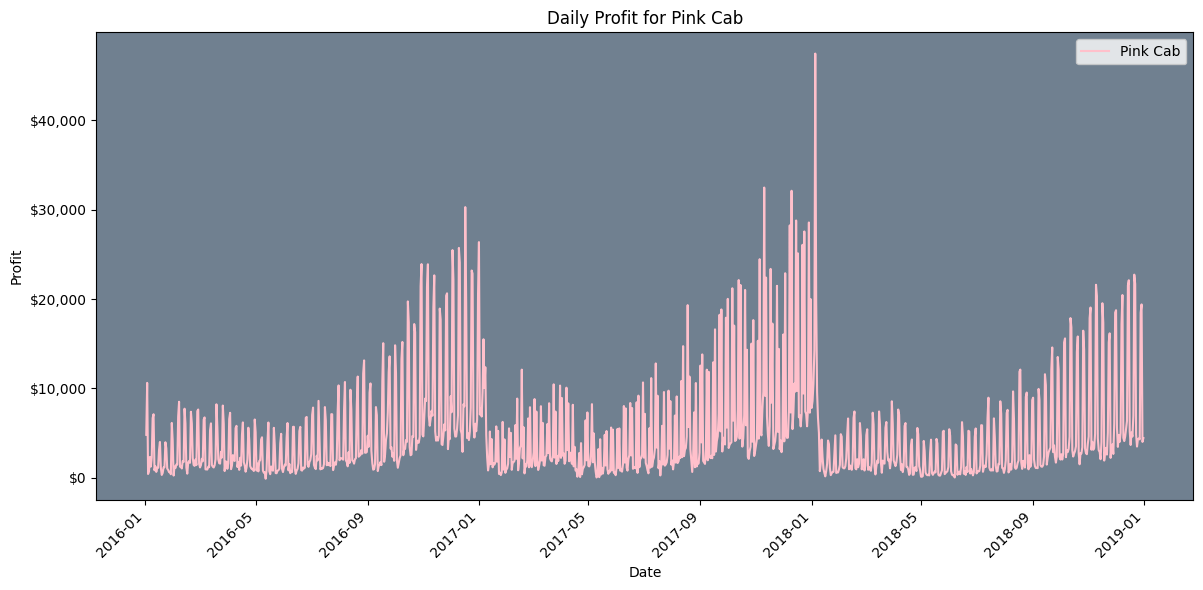

In [100]:
# Chart the Daily profit for Pink Cab - Line Chart
# Filter data for Pink Cab
pink_cab_df = master1_df[master1_df['Company'] == 'Pink Cab']

# Calculate daily profit for yellow_cab_df
daily_profit_pink = pink_cab_df.groupby('date')['Profit'].sum().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker # Import the ticker module


# ... (your existing code to define month_order, company_colors, etc.) ...
# Assign color for the different companies
company_colors = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Create a line plot of daily profit for Yellow Cab
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
sns.lineplot(x='date', y='Profit', data=daily_profit_pink, color='pink', label='Pink Cab')
plt.title('Daily Profit for Pink Cab')
plt.xlabel('Date')
plt.ylabel('Profit')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()

# Set background color
ax = plt.gca()  # Get current axes
ax.set_facecolor('slategray')

# Format y-axis as dollars
formatter = ticker.StrMethodFormatter('${x:,.0f}')  # Format with dollar sign and comma separator
ax.yaxis.set_major_formatter(formatter)

plt.show()

In [101]:
# Calculate monthly profit for pink_cab_df
monthly_profit_pink = pink_cab_df.groupby('month')['Profit'].sum()
monthly_profit_pink

,Profit
month,
1,388054.602
2,252041.309
3,299096.571
4,245818.095
5,168613.914
6,232715.233
7,301885.097
8,388251.300
9,494435.325


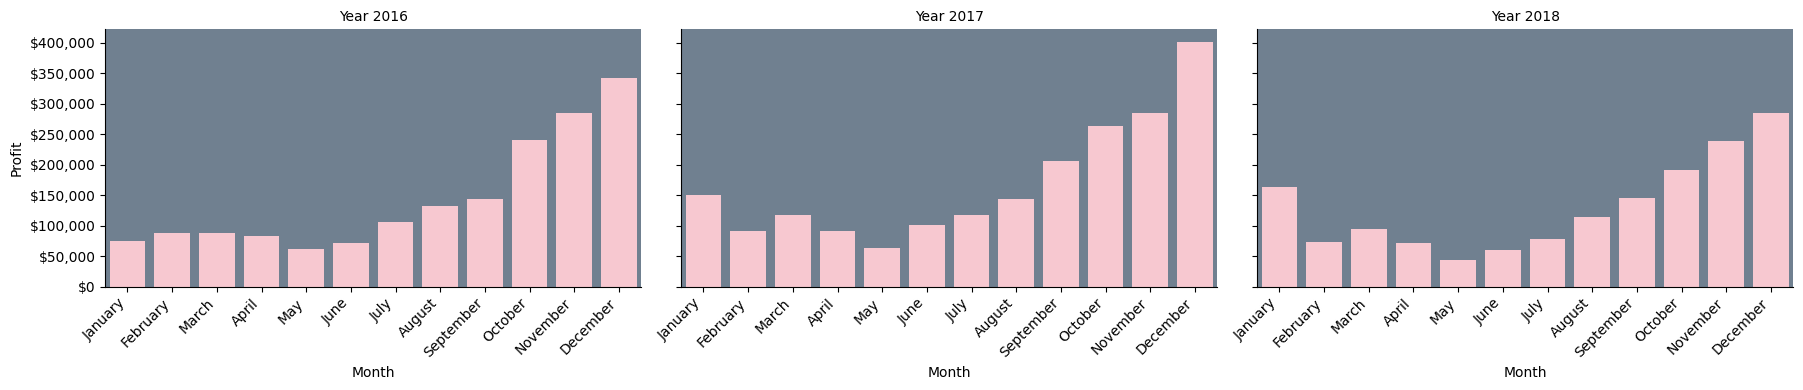

In [102]:
# Bar chart for Monthly Profits in pink cab
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker

# Define the desired order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# ... (your existing code to filter data for Pink Cab) ...

# Calculate monthly profit for pink_cab_df
monthly_profit_pink = pink_cab_df.groupby(['year', 'month'])['Profit'].sum().reset_index()

# Map month numbers to month names
month_mapping = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
    7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
monthly_profit_pink['month_name'] = monthly_profit_pink['month'].map(month_mapping)

# Convert 'month_name' to categorical with ordered months
monthly_profit_pink['month_name'] = pd.Categorical(monthly_profit_pink['month_name'], categories=month_order, ordered=True)

# Create small multiple plots for each year
g = sns.FacetGrid(monthly_profit_pink, col='year', height=4, aspect=1.5)  # Use FacetGrid for small multiples

# Use sns.barplot to display monthly profit
g.map(sns.barplot, 'month_name', 'Profit', order=month_order, color='pink')

g.set_titles("Year {col_name}")  # Set titles for each subplot
g.set_xticklabels(rotation=45, ha='right')  # Rotate x-axis labels
g.set_axis_labels("Month", "Profit")  # Set axis labels
plt.tight_layout()

# Set background color for each subplot and format y-axis
for ax in g.axes.flat:
    ax.set_facecolor('slategray')
    formatter = ticker.StrMethodFormatter('${x:,.0f}')  # Format with dollar sign and comma separator
    ax.yaxis.set_major_formatter(formatter)

plt.show()

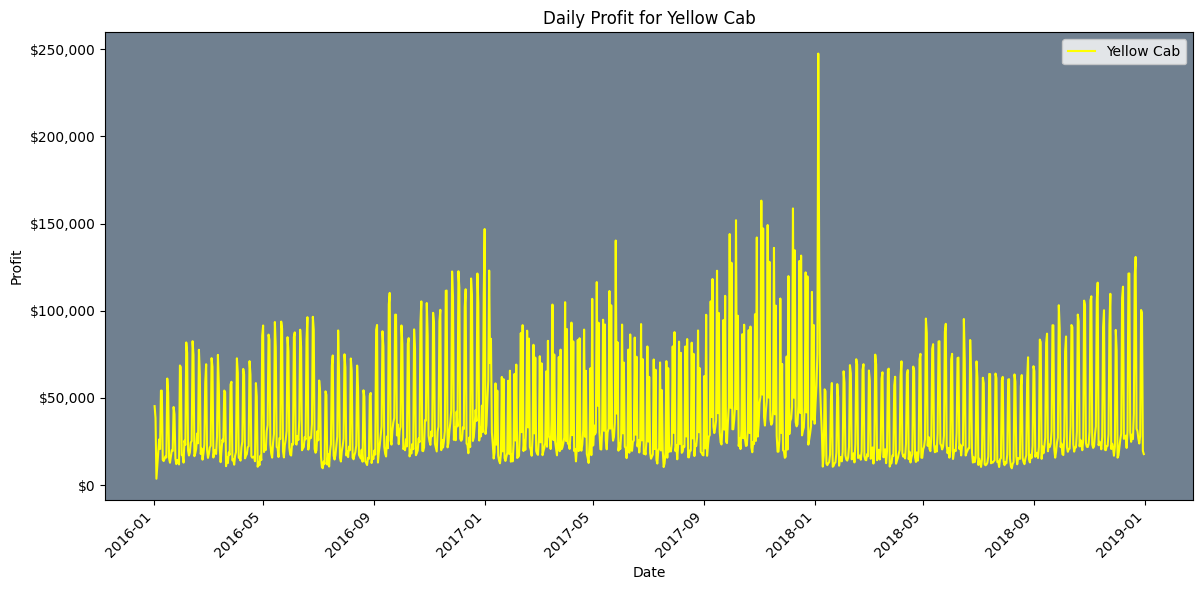

In [103]:
# Chart the Daily profit for Yellow Cab -Line Chart
# Filter data for Yellow Cab
yellow_cab_df = master1_df[master1_df['Company'] == 'Yellow Cab']

# Calculate daily profit for yellow_cab_df
daily_profit_yellow = yellow_cab_df.groupby('date')['Profit'].sum().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ... (your existing code to define month_order, company_colors, etc.) ...
# Assign color for the different companies
company_colors = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Create a line plot of daily profit for Yellow Cab
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
sns.lineplot(x='date', y='Profit', data=daily_profit_yellow, color='yellow', label='Yellow Cab')
plt.title('Daily Profit for Yellow Cab')
plt.xlabel('Date')
plt.ylabel('Profit')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()

# Set background color
ax = plt.gca()  # Get current axes
ax.set_facecolor('slategray')

# Format y-axis as dollars
formatter = ticker.StrMethodFormatter('${x:,.0f}')  # Format with dollar sign and comma separator
ax.yaxis.set_major_formatter(formatter)

plt.show()

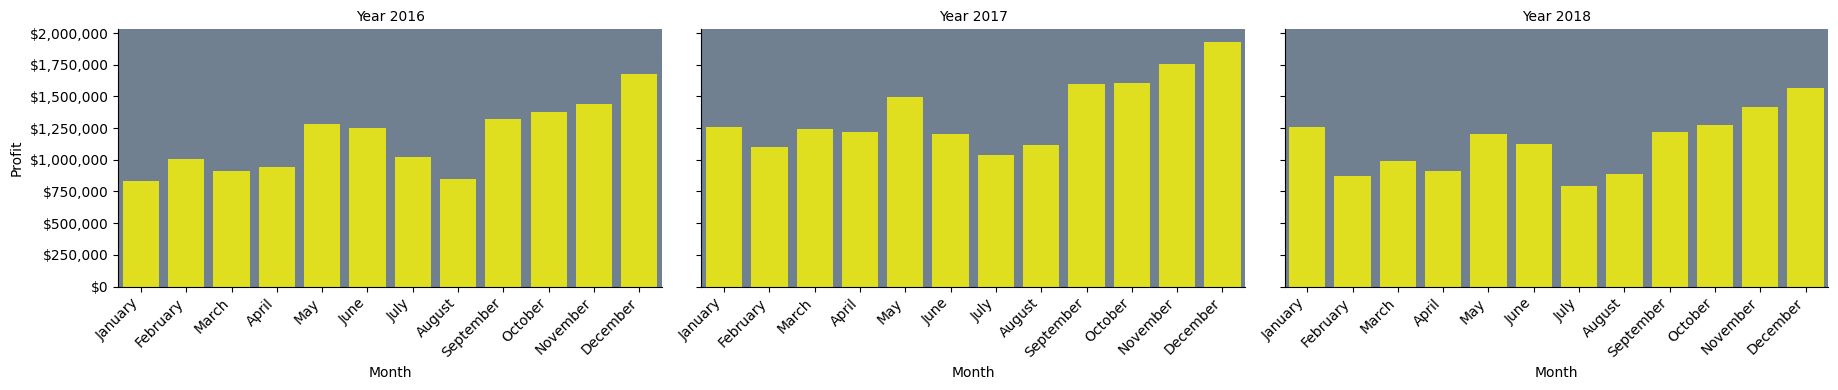

In [104]:
# Bar chart for Monthly Profits in yellow cab
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker

# Define the desired order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# ... (your existing code to filter data for Yellow Cab) ...

# Calculate monthly profit for yellow_cab_df
monthly_profit_yellow = yellow_cab_df.groupby(['year', 'month'])['Profit'].sum().reset_index()

# Map month numbers to month names
month_mapping = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
    7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
monthly_profit_yellow['month_name'] = monthly_profit_yellow['month'].map(month_mapping)

# Convert 'month_name' to categorical with ordered months
monthly_profit_yellow['month_name'] = pd.Categorical(monthly_profit_yellow['month_name'], categories=month_order, ordered=True)

# Create small multiple plots for each year
g = sns.FacetGrid(monthly_profit_yellow, col='year', height=4, aspect=1.5)  # Use FacetGrid for small multiples

# Use sns.barplot to display monthly profit
g.map(sns.barplot, 'month_name', 'Profit', order=month_order, color='yellow')

g.set_titles("Year {col_name}")  # Set titles for each subplot
g.set_xticklabels(rotation=45, ha='right')  # Rotate x-axis labels
g.set_axis_labels("Month", "Profit")  # Set axis labels
plt.tight_layout()

# Set background color for each subplot and format y-axis
for ax in g.axes.flat:
    ax.set_facecolor('slategray')
    formatter = ticker.StrMethodFormatter('${x:,.0f}')  # Format with dollar sign and comma separator
    ax.yaxis.set_major_formatter(formatter)

plt.show()

In [105]:
# Calculate monthly profit for master1_df for yellow cab and pink cab
monthly_profit_master = master1_df.groupby(['year', 'month', 'Company'])['Profit'].sum().reset_index()
monthly_profit_master

,year,month,Company,Profit
0,2016,1,Pink Cab,7.395286e+04
1,2016,1,Yellow Cab,8.363081e+05
2,2016,2,Pink Cab,8.747554e+04
3,2016,2,Yellow Cab,1.009169e+06
4,2016,3,Pink Cab,8.780118e+04
...,...,...,...,...
67,2018,10,Yellow Cab,1.273756e+06
68,2018,11,Pink Cab,2.393377e+05
69,2018,11,Yellow Cab,1.416933e+06
70,2018,12,Pink Cab,2.856059e+05


<ipython-input-106-43871e59fb3b>:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_profit_master = master1_df.groupby(['year', 'month_name', 'Company'])['Profit'].sum().reset_index()


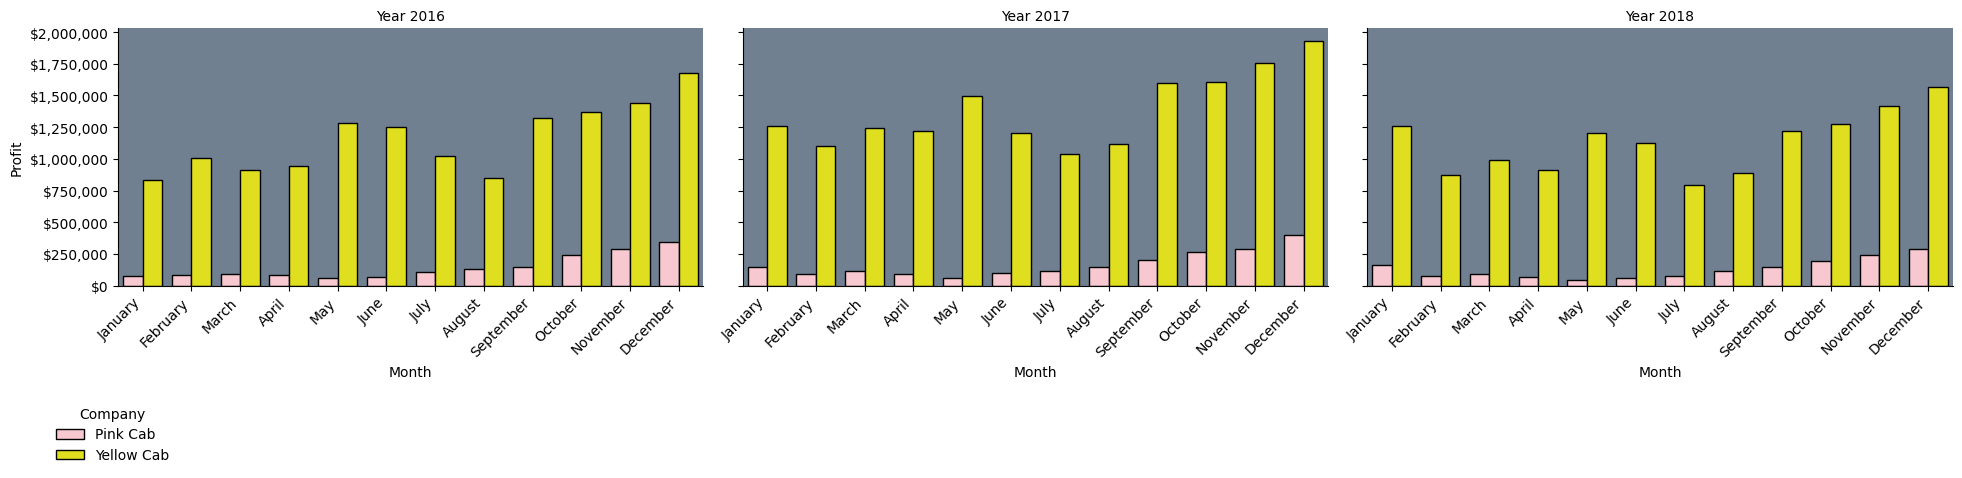

In [106]:
# Monthly Profit For both Yellow and Pink Cab 3 mini-Chart
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
import calendar  # Import calendar for month names

# Assuming 'master1_df' contains your data with 'month', 'year', 'Company', and 'Profit' columns

# Map month numbers to month names for the entire DataFrame
master1_df['month_name'] = master1_df['month'].apply(lambda x: calendar.month_name[x])

# Define the desired order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Convert 'month_name' to categorical with ordered months
master1_df['month_name'] = pd.Categorical(master1_df['month_name'], categories=month_order, ordered=True)

# Assign color for the different companies
company_colors = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Calculate monthly profit for master1_df for yellow cab and pink cab
monthly_profit_master = master1_df.groupby(['year', 'month_name', 'Company'])['Profit'].sum().reset_index()

# Create small multiple plots for each year
g = sns.FacetGrid(monthly_profit_master, col='year', height=4, aspect=1.5)  # Use FacetGrid for small multiples

# Use sns.barplot to plot profits instead of countplot
# Pass the 'data' argument directly to sns.barplot
g.map(sns.barplot, 'month_name', 'Profit', hue='Company', data=monthly_profit_master,  # Pass data here
      palette=company_colors, edgecolor='black', order=month_order, errorbar=None)

g.set_titles("Year {col_name}")  # Set titles for each subplot
g.set_xticklabels(rotation=45, ha='right')  # Rotate x-axis labels
g.set_axis_labels("Month", "Profit")  # Set axis labels

# Add a legend and position it in the top left corner
g.add_legend(title='Company', loc='upper left', bbox_to_anchor=(0, 0))

plt.tight_layout()

# Set background color for each subplot and format y-axis
for ax in g.axes.flat:
    ax.set_facecolor('slategray')
    formatter = ticker.StrMethodFormatter('${x:,.0f}')  # Format with dollar sign and comma separator
    ax.yaxis.set_major_formatter(formatter)

plt.show()

<Figure size 1200x600 with 0 Axes>

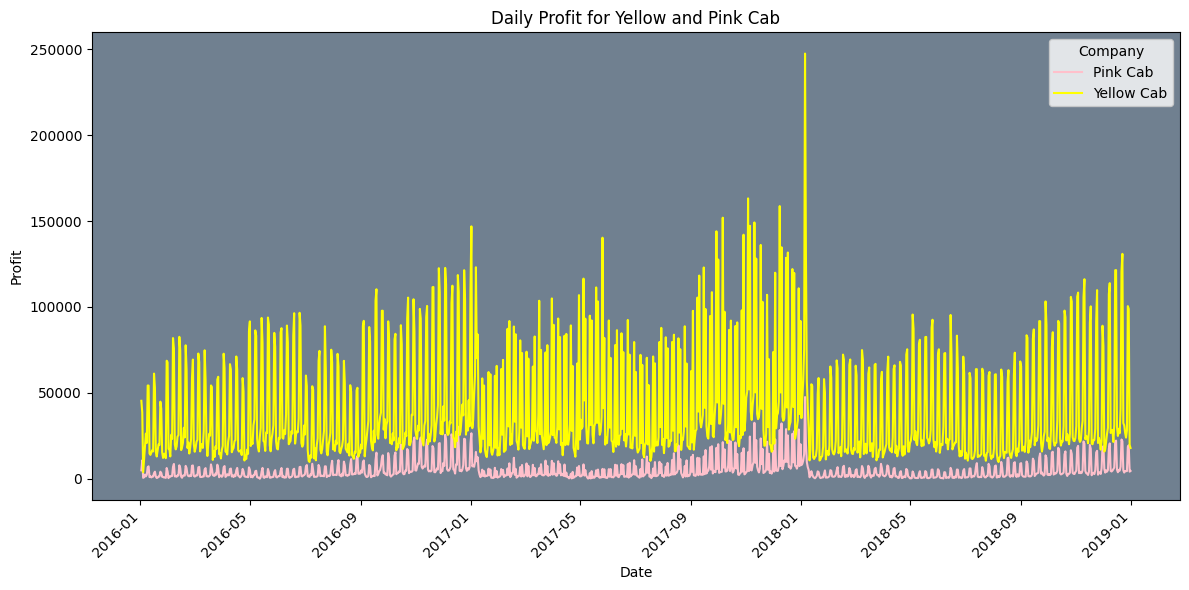

<ipython-input-107-6ead49a284d0>:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_profit_master = master1_df.groupby(['year', 'month_name', 'Company'])['Profit'].sum().reset_index()


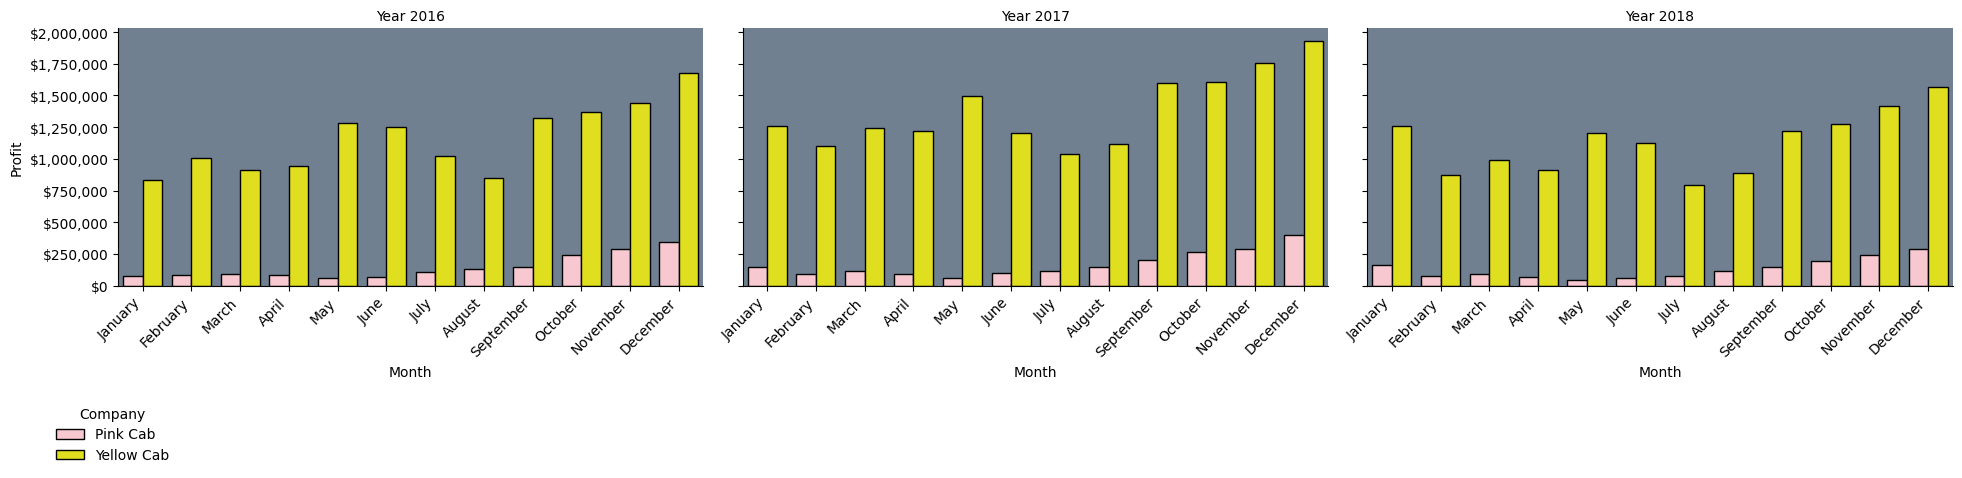

In [107]:
# Daily Profit Chart
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
import calendar  # Import calendar for month names

# Assuming 'master1_df' contains your data with 'month', 'year', 'Company', and 'Profit' columns

# 1. Calculate and Plot Daily Profits:
daily_profit = master1_df.groupby(['date', 'Company'])['Profit'].sum().reset_index()

# Convert 'date' column to datetime objects
daily_profit['date'] = pd.to_datetime(daily_profit['date'])


plt.figure(figsize=(12, 6))
# Create the ax object here
fig, ax = plt.subplots(figsize=(12, 6))

# Set the background color of the plot to slategray
ax.set_facecolor('slategray')

sns.lineplot(x='date', y='Profit', hue='Company', data=daily_profit,
             palette=company_colors, ax=ax)  # Pass ax to sns.lineplot

plt.title('Daily Profit for Yellow and Pink Cab')
plt.xlabel('Date')
plt.ylabel('Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Set background color for each subplot and format y-axis
for ax in g.axes.flat:
    #ax.set_facecolor('slategray')
    formatter = ticker.StrMethodFormatter('${x:,.0f}')  # Format with dollar sign and comma separator
    ax.yaxis.set_major_formatter(formatter)

plt.show()

# 2. Monthly Profit Charts:

# Map month numbers to month names for the entire DataFrame
master1_df['month_name'] = master1_df['month'].apply(lambda x: calendar.month_name[x])

# Define the desired order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Convert 'month_name' to categorical with ordered months
master1_df['month_name'] = pd.Categorical(master1_df['month_name'], categories=month_order, ordered=True)

# Assign color for the different companies
company_colors = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Calculate monthly profit for master1_df for yellow cab and pink cab
monthly_profit_master = master1_df.groupby(['year', 'month_name', 'Company'])['Profit'].sum().reset_index()

# Create small multiple plots for each year
g = sns.FacetGrid(monthly_profit_master, col='year', height=4, aspect=1.5)  # Use FacetGrid for small multiples

# Use sns.barplot to plot profits instead of countplot
# Pass the 'data' argument directly to sns.barplot
g.map(sns.barplot, 'month_name', 'Profit', hue='Company', data=monthly_profit_master,  # Pass data here
      palette=company_colors, edgecolor='black', order=month_order, errorbar=None)

g.set_titles("Year {col_name}")  # Set titles for each subplot
g.set_xticklabels(rotation=45, ha='right')  # Rotate x-axis labels
g.set_axis_labels("Month", "Profit")  # Set axis labels

# Add a legend and position it in the top left corner
g.add_legend(title='Company', loc='upper left', bbox_to_anchor=(0, 0))

plt.tight_layout()

# Set background color for each subplot and format y-axis
for ax in g.axes.flat:
    ax.set_facecolor('slategray')
    formatter = ticker.StrMethodFormatter('${x:,.0f}')  # Format with dollar sign and comma separator
    ax.yaxis.set_major_formatter(formatter)

plt.show()

In [111]:
# Calculate daily profit for each city for pink_cab_df
daily_profit_city_pink = pink_cab_df.groupby(['date', 'City'])['Profit'].sum()
daily_profit_city_pink

date        City          
2016-01-02  ATLANTA GA         27.568
            BOSTON MA         289.766
            CHICAGO IL        641.036
            DALLAS TX        -105.194
            DENVER CO         -21.536
                               ...   
2018-12-31  SAN DIEGO CA      400.388
            SEATTLE WA        331.992
            SILICON VALLEY    532.035
            TUCSON AZ         130.762
            WASHINGTON DC      85.344
Name: Profit, Length: 15606, dtype: float64

In [112]:
# Calculate daily profit for each city for pink_cab_df
monthly_profit_city_pink = pink_cab_df.groupby(['month', 'City'])['Profit'].sum()
monthly_profit_city_pink

month  City          
1      ATLANTA GA         4239.851
       AUSTIN TX          8573.211
       BOSTON MA         14541.673
       CHICAGO IL        32313.500
       DALLAS TX          2219.439
                           ...    
12     SAN DIEGO CA      92699.464
       SEATTLE WA        19597.361
       SILICON VALLEY    54263.391
       TUCSON AZ         11741.721
       WASHINGTON DC     38505.406
Name: Profit, Length: 228, dtype: float64

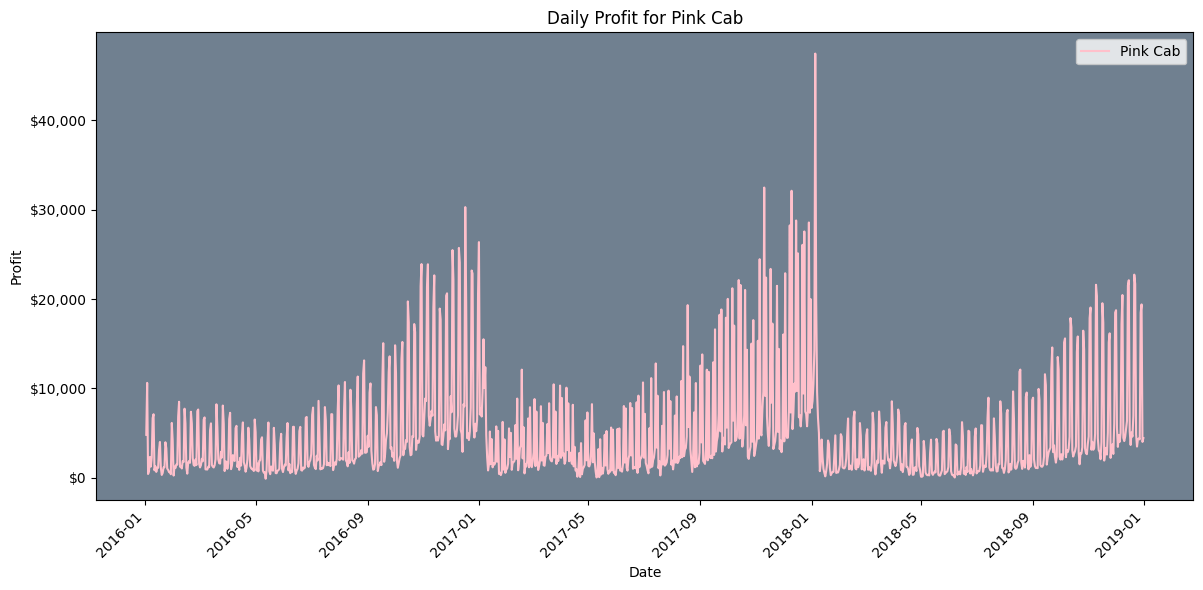

In [113]:
# Chart the Daily profit for Pink Cab
# Filter data for Pink Cab
pink_cab_df = master1_df[master1_df['Company'] == 'Pink Cab']

# Calculate daily profit for yellow_cab_df
daily_profit_pink = pink_cab_df.groupby('date')['Profit'].sum().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ... (your existing code to define month_order, company_colors, etc.) ...
# Assign color for the different companies
company_colors = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Create a line plot of daily profit for Yellow Cab
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
sns.lineplot(x='date', y='Profit', data=daily_profit_pink, color='pink', label='Pink Cab')
plt.title('Daily Profit for Pink Cab')
plt.xlabel('Date')
plt.ylabel('Profit')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()

# Set background color
ax = plt.gca()  # Get current axes
ax.set_facecolor('slategray')

# Format y-axis as dollars
formatter = ticker.StrMethodFormatter('${x:,.0f}')  # Format with dollar sign and comma separator
ax.yaxis.set_major_formatter(formatter)

plt.show()

In [114]:
master1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359392 entries, 0 to 359391
Data columns (total 27 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               359392 non-null  int64         
 1   Transaction ID      359392 non-null  int64         
 2   Date of Travel      359392 non-null  int64         
 3   Date Time Stamp     359392 non-null  datetime64[ns]
 4   Company             359392 non-null  object        
 5   City                359392 non-null  object        
 6   KM Travelled        359392 non-null  float64       
 7   Price Charged       359392 non-null  float64       
 8   Cost of Trip        359392 non-null  float64       
 9   date                359392 non-null  datetime64[ns]
 10  time                359392 non-null  object        
 11  month               359392 non-null  int32         
 12  year                359392 non-null  int32         
 13  day                 359392 no

In [115]:
master1_df.nunique()

,0
index,359392
Transaction ID,359392
Date of Travel,1095
Date Time Stamp,1095
Company,2
City,19
KM Travelled,874
Price Charged,99176
Cost of Trip,16291
date,1095


In [126]:
master1_df['year'].unique()

array([2016, 2017, 2018], dtype=int32)

In [127]:
# Build year2016_df data frame
year2016_df = master1_df[master1_df['year'] == 2016]
year2016_df.head()

,index,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,...,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled
0,0,10000011,42377,2016-01-08,Pink Cab,ATLANTA GA,30.45,370.95,313.635,2016-01-08,...,29290,Card,Male,28,10813,"814,885","24,701",57.315,1.882266,18.924798
1,1,10000012,42375,2016-01-06,Pink Cab,ATLANTA GA,28.62,358.52,334.854,2016-01-06,...,27703,Card,Male,27,9237,"814,885","24,701",23.666,0.826904,17.787446
2,2,10000013,42371,2016-01-02,Pink Cab,ATLANTA GA,9.04,125.20,97.632,2016-01-02,...,28712,Cash,Male,53,11242,"814,885","24,701",27.568,3.049558,5.618397
3,3,10000014,42376,2016-01-07,Pink Cab,ATLANTA GA,33.17,377.40,351.602,2016-01-07,...,28020,Cash,Male,23,23327,"814,885","24,701",25.798,0.777751,20.615289
4,4,10000015,42372,2016-01-03,Pink Cab,ATLANTA GA,8.73,114.62,97.776,2016-01-03,...,27182,Card,Male,33,8536,"814,885","24,701",16.844,1.929439,5.425730


In [128]:
# Build year2017_df data frame
year2017_df = master1_df[master1_df['year'] == 2017]
year2017_df.head()

,index,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,...,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled
104523,104523,10128150,42736,2017-01-01,Pink Cab,ATLANTA GA,24.00,379.79,280.800,2017-01-01,...,28154,Card,Male,49,22791,"814,885","24,701",98.990,4.124583,14.916097
104526,104526,10128153,42736,2017-01-01,Pink Cab,ATLANTA GA,38.88,609.62,443.232,2017-01-01,...,29383,Card,Female,57,3602,"814,885","24,701",166.388,4.279527,24.164077
104540,104540,10128167,42737,2017-01-02,Pink Cab,AUSTIN TX,29.00,451.15,313.200,2017-01-02,...,35840,Card,Female,57,3739,"698,371","14,978",137.950,4.756897,18.023617
104542,104542,10128169,42737,2017-01-02,Pink Cab,AUSTIN TX,3.36,60.79,34.944,2017-01-02,...,33128,Cash,Female,21,29258,"698,371","14,978",25.846,7.692262,2.088254
104561,104561,10128188,42736,2017-01-01,Pink Cab,BOSTON MA,41.44,630.76,464.128,2017-01-01,...,59347,Card,Male,26,9408,"248,968","80,021",166.632,4.021042,25.755127


In [129]:
# Build year2018_df data frame
year2018_df = master1_df[master1_df['year'] == 2018]
year2018_df.head()

,index,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,...,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled
232540,232540,10284384,43101,2018-01-01,Pink Cab,AUSTIN TX,28.71,375.20,287.100,2018-01-01,...,35376,Cash,Male,48,8526,"698,371","14,978",88.100,3.068617,17.843381
232558,232558,10284402,43102,2018-01-02,Pink Cab,BOSTON MA,20.20,286.41,238.360,2018-01-02,...,57151,Card,Female,22,23049,"248,968","80,021",48.050,2.378713,12.554382
232566,232566,10284410,43101,2018-01-01,Pink Cab,BOSTON MA,34.50,494.37,355.350,2018-01-01,...,58558,Cash,Female,36,8005,"248,968","80,021",139.020,4.029565,21.441889
232587,232587,10284431,43101,2018-01-01,Pink Cab,BOSTON MA,16.96,266.05,174.688,2018-01-01,...,59192,Card,Male,28,3721,"248,968","80,021",91.362,5.386910,10.540709
232611,232611,10284455,43101,2018-01-01,Pink Cab,CHICAGO IL,6.78,78.35,70.512,2018-01-01,...,5716,Card,Female,36,22189,"1,955,130","164,468",7.838,1.156047,4.213797


In [130]:
# Calculate profit per month total
monthly_profit = master1_df.groupby('month')['Profit'].sum()
monthly_profit

,Profit
month,
1,3.746490e+06
2,3.228020e+06
3,3.450311e+06
4,3.321361e+06
5,4.152157e+06
6,3.813054e+06
7,3.163447e+06
8,3.244522e+06
9,4.636818e+06


# **KM Travelled**

In [241]:
# Filter data for the year 2016
year2016_df = master1_df[master1_df['year'] == 2016]

# Calculate the total KM Travelled for 2016
total_km_travelled_2016 = year2016_df['KM Travelled'].sum()

# Print the result
print(f"Total KM Travelled in 2016: {total_km_travelled_2016}")

Total KM Travelled in 2016: 2423487.8800000004


In [242]:
# Filter data for the year 2017
year2017_df = master1_df[master1_df['year'] == 2017]

# Calculate the total KM Travelled for 2017
total_km_travelled_2017 = year2017_df['KM Travelled'].sum()

# Print the result
print(f"Total KM Travelled in 2017: {total_km_travelled_2017}")

Total KM Travelled in 2017: 2900702.5399999996


In [243]:
# Filter data for the year 2018
year2018_df = master1_df[master1_df['year'] == 2018]

# Calculate the total KM Travelled for 2018
total_km_travelled_2018 = year2018_df['KM Travelled'].sum()

# Print the result
print(f"Total KM Travelled in 2018: {total_km_travelled_2018}")

Total KM Travelled in 2018: 2786300.16


/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


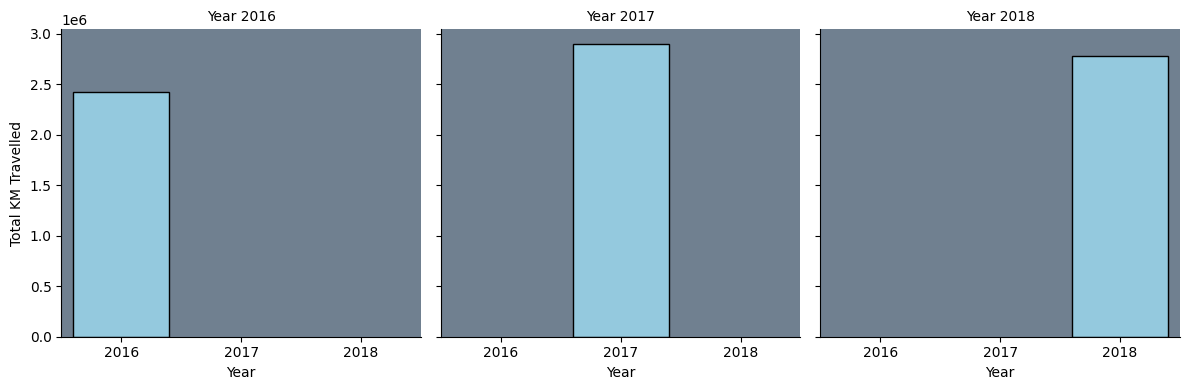

In [244]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total KM Travelled for each year
years = [2016, 2017, 2018]
km_travelled_per_year = []

for year in years:
    year_df = master1_df[master1_df['year'] == year]
    total_km_travelled = year_df['KM Travelled'].sum()
    km_travelled_per_year.append(total_km_travelled)

# Create a DataFrame for plotting
km_travelled_df = pd.DataFrame({'Year': years, 'Total KM Travelled': km_travelled_per_year})

# Create the mini-plot bar charts using seaborn
g = sns.FacetGrid(km_travelled_df, col='Year', height=4, aspect=1)  # Use FacetGrid for mini-plots
g.map(sns.barplot, 'Year', 'Total KM Travelled', color='skyblue', edgecolor='black')  # Use barplot for bars

g.set_titles("Year {col_name}")  # Set titles for each subplot
g.set_axis_labels("Year", "Total KM Travelled")  # Set axis labels

# Set background color for each subplot
for ax in g.axes.flat:
    ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

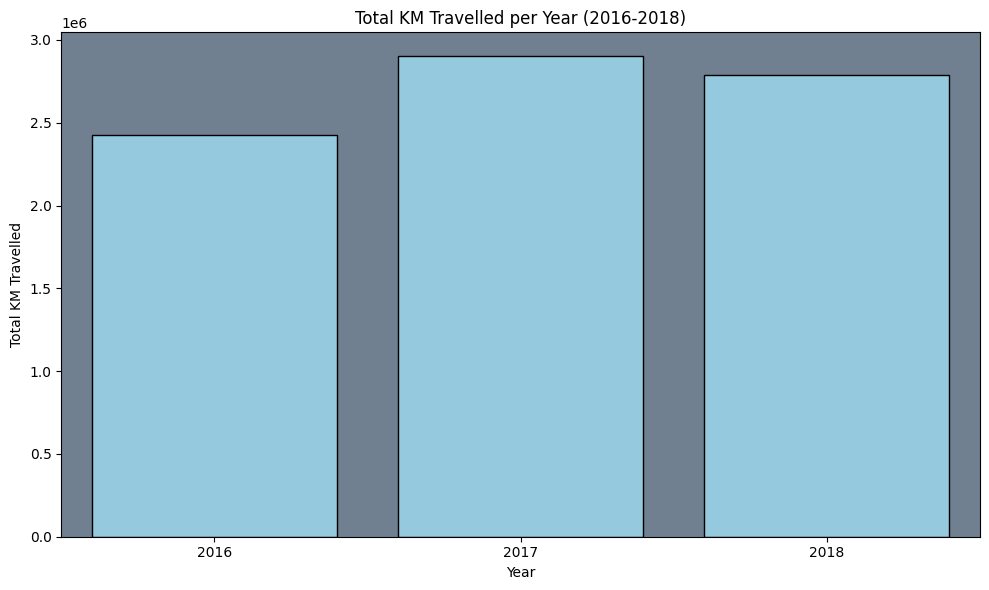

In [245]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total KM Travelled for each year
years = [2016, 2017, 2018]
km_travelled_per_year = []

for year in years:
    year_df = master1_df[master1_df['year'] == year]
    total_km_travelled = year_df['KM Travelled'].sum()
    km_travelled_per_year.append(total_km_travelled)

# Create a DataFrame for plotting
km_travelled_df = pd.DataFrame({'Year': years, 'Total KM Travelled': km_travelled_per_year})

# Create the bar chart using seaborn
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.barplot(x='Year', y='Total KM Travelled', data=km_travelled_df, color='skyblue', edgecolor='black')

plt.title('Total KM Travelled per Year (2016-2018)')  # Set title
plt.xlabel('Year')  # Set x-axis label
plt.ylabel('Total KM Travelled')  # Set y-axis label

# Set background color
ax = plt.gca()  # Get current axes
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

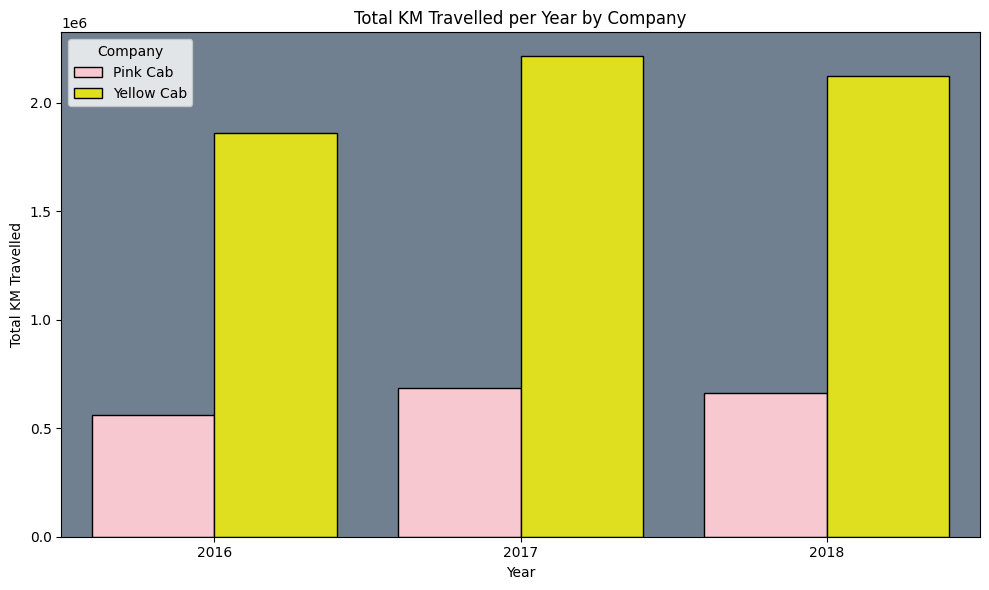

In [246]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total KM Travelled for each company per year
km_travelled_per_year_company = master1_df.groupby(['year', 'Company'])['KM Travelled'].sum().reset_index()

# Create the bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='year', y='KM Travelled', hue='Company', data=km_travelled_per_year_company,
            palette={'Yellow Cab': 'yellow', 'Pink Cab': 'pink'}, edgecolor='black')

plt.title('Total KM Travelled per Year by Company')
plt.xlabel('Year')
plt.ylabel('Total KM Travelled')

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

In [265]:
# calculate the 'KM Travelled' by yellow cab
yellow_cab_df = master1_df[master1_df['Company'] == 'Yellow Cab']
yellow_cab_df['KM Travelled'].sum()

6199417.469999999

In [266]:
# calculate the 'KM Travelled' by pink cab
pink_cab_df = master1_df[master1_df['Company'] == 'Pink Cab']
pink_cab_df['KM Travelled'].sum()

1911073.1100000003

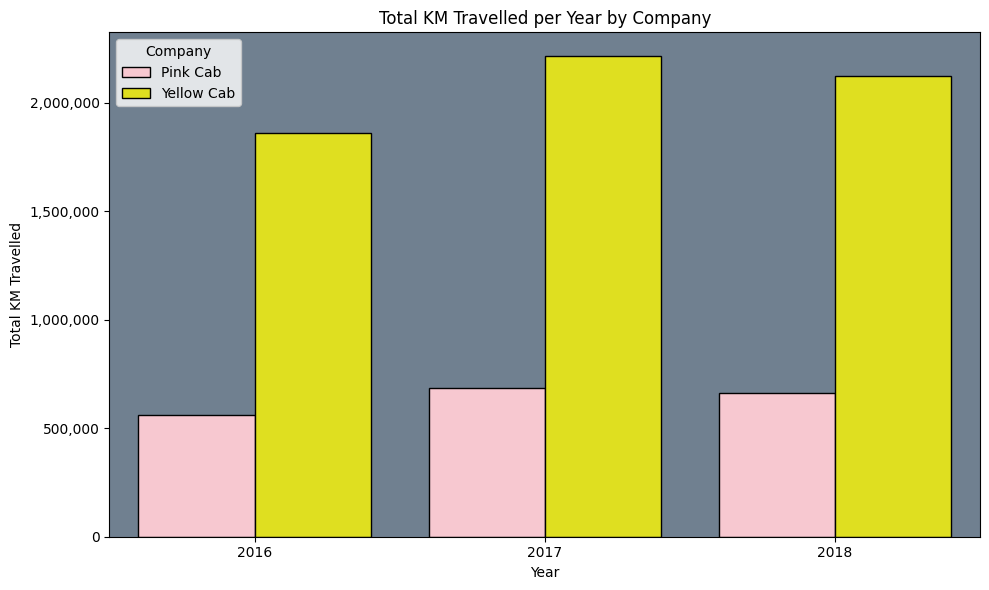

In [247]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker  # Import the ticker module

# Calculate total KM Travelled for each company per year
km_travelled_per_year_company = master1_df.groupby(['year', 'Company'])['KM Travelled'].sum().reset_index()

# Create the bar chart using seaborn
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='year', y='KM Travelled', hue='Company', data=km_travelled_per_year_company,
                 palette={'Yellow Cab': 'yellow', 'Pink Cab': 'pink'}, edgecolor='black')

plt.title('Total KM Travelled per Year by Company')
plt.xlabel('Year')
plt.ylabel('Total KM Travelled')

# Set background color
ax.set_facecolor('slategray')

# Use ScalarFormatter to display full numbers on y-axis
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

# Optional: Add commas for better readability
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

# **Price Charged Per Ride**

In [237]:
# Filter data for the year 2016
year2016_df = master1_df[master1_df['year'] == 2016]

# Calculate the total Price Charged for 2016
price_charged_2016 = year2016_df['Price Charged'].sum()

# Print the result
print(f"Total Price Charged in 2016: {price_charged_2016}")

Total Price Charged in 2016: 46389612.41


In [238]:
# Filter data for the year 2017
year2017_df = master1_df[master1_df['year'] == 2017]

# Calculate the total Price Charged for 2017
price_charged_2017 = year2017_df['Price Charged'].sum()

# Print the result
print(f"Total Price Charged in 2017: {price_charged_2017}")

Total Price Charged in 2017: 55397539.58000001


In [239]:
# Filter data for the year 2018
year2018_df = master1_df[master1_df['year'] == 2018]

# Calculate the total Price Charged for 2018
price_charged_2018 = year2018_df['Price Charged'].sum()

# Print the result
print(f"Total KM Travelled in 2018: {price_charged_2018}")

Total KM Travelled in 2018: 50394986.529999994


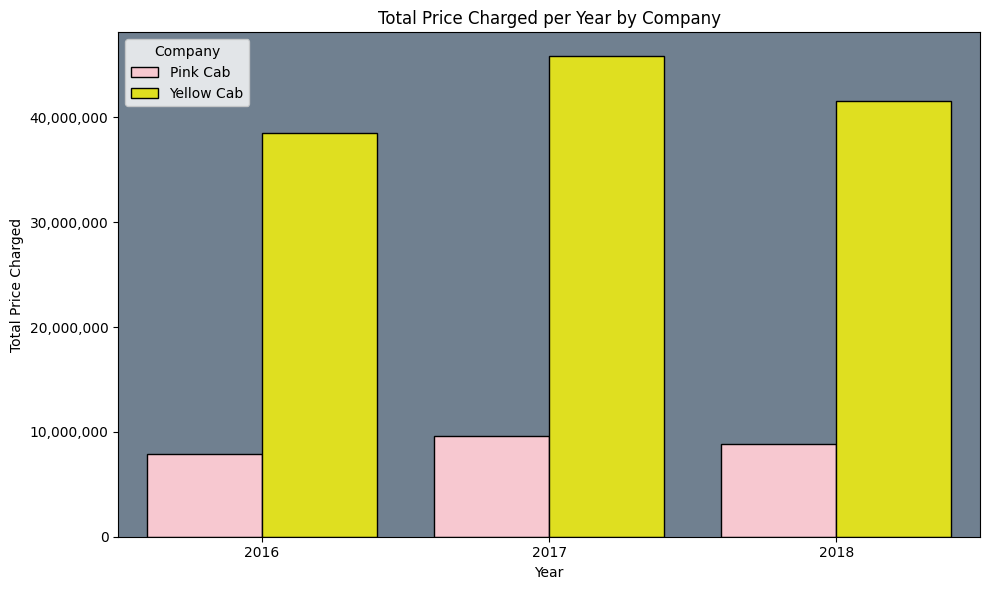

In [240]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker  # Import the ticker module

# Calculate total Price Charged for each company per year
price_charged_per_year_company = master1_df.groupby(['year', 'Company'])['Price Charged'].sum().reset_index()

# Create the bar chart using seaborn
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='year', y='Price Charged', hue='Company', data=price_charged_per_year_company,
                 palette={'Yellow Cab': 'yellow', 'Pink Cab': 'pink'}, edgecolor='black')

plt.title('Total Price Charged per Year by Company')
plt.xlabel('Year')
plt.ylabel('Total Price Charged')

# Set background color
ax.set_facecolor('slategray')

# Use ScalarFormatter to display full numbers on y-axis
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

# Optional: Add commas for better readability
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

# **Hypotheses**

1. Yellow Cab is more common than Pink Cab. So Yellow Cab is in more cities than Pink Cab.
2. Yellow Cab is more Popular than Pink Cab overall.
3. The profits of cab rides mirror the number of rides
4. There is seasonality throughout the year for cab rides.
5. There is seasonality throughout the month for cab rides
6. There is seasonality throughout the week for cab rides
7. There is seasonality throughout the day for cab rides
8. There is seasonlity in US holidays for cab rides
9. Cab rides cost more in higher populated cities than lower populated cities
10. The majority of cab riders are in higher income brackets in higher populated cities.
11. The majority of cab riders in medium populated cities are in the middle class income bracket.
12. Percentwise, more women take Pink Cab than Yellow Cab as return riders
13. The majority of cab riders are men
14. The majority of cab riders are the ages between 20 and 30.








# **Hypothesis 1: Yellow Cab is More Common Than Pink Cab So Yellow Cab is in more Cities than Pink Cab**

In [131]:
# Calculate total rides grouped by city and company
rides_per_city_company = master1_df.groupby(['City', 'Company'])['Transaction ID'].count().reset_index()
print(rides_per_city_company)

              City     Company  Transaction ID
0       ATLANTA GA    Pink Cab            1762
1       ATLANTA GA  Yellow Cab            5795
2        AUSTIN TX    Pink Cab            1868
3        AUSTIN TX  Yellow Cab            3028
4        BOSTON MA    Pink Cab            5186
5        BOSTON MA  Yellow Cab           24506
6       CHICAGO IL    Pink Cab            9361
7       CHICAGO IL  Yellow Cab           47264
8        DALLAS TX    Pink Cab            1380
9        DALLAS TX  Yellow Cab            5637
10       DENVER CO    Pink Cab            1394
11       DENVER CO  Yellow Cab            2431
12  LOS ANGELES CA    Pink Cab           19865
13  LOS ANGELES CA  Yellow Cab           28168
14        MIAMI FL    Pink Cab            2002
15        MIAMI FL  Yellow Cab            4452
16    NASHVILLE TN    Pink Cab            1841
17    NASHVILLE TN  Yellow Cab            1169
18     NEW YORK NY    Pink Cab           13967
19     NEW YORK NY  Yellow Cab           85918
20   ORANGE C

In [132]:
rides_per_city_company = master1_df.groupby(['City', 'Company'])['Transaction ID'].count().reset_index()

# Sort by 'Transaction ID' in descending order (largest to smallest)
rides_per_city_company = rides_per_city_company.sort_values(by=['Transaction ID'], ascending=False)

print(rides_per_city_company)

              City     Company  Transaction ID
19     NEW YORK NY  Yellow Cab           85918
7       CHICAGO IL  Yellow Cab           47264
37   WASHINGTON DC  Yellow Cab           40045
13  LOS ANGELES CA  Yellow Cab           28168
5        BOSTON MA  Yellow Cab           24506
12  LOS ANGELES CA    Pink Cab           19865
18     NEW YORK NY    Pink Cab           13967
28    SAN DIEGO CA    Pink Cab           10672
29    SAN DIEGO CA  Yellow Cab            9816
6       CHICAGO IL    Pink Cab            9361
1       ATLANTA GA  Yellow Cab            5795
9        DALLAS TX  Yellow Cab            5637
31      SEATTLE WA  Yellow Cab            5265
4        BOSTON MA    Pink Cab            5186
33  SILICON VALLEY  Yellow Cab            4722
15        MIAMI FL  Yellow Cab            4452
32  SILICON VALLEY    Pink Cab            3797
36   WASHINGTON DC    Pink Cab            3692
3        AUSTIN TX  Yellow Cab            3028
30      SEATTLE WA    Pink Cab            2732
21   ORANGE C

In [ ]:
# Get the total number of cities that Yellow Cab services
yellow_cab_df = master1_df[master1_df['Company'] == 'Yellow Cab']
yellow_cab_df['City'].nunique()


19

In [ ]:
# Get the total number of cities that Pink Cab services
pink_cab_df = master1_df[master1_df['Company'] == 'Pink Cab']
pink_cab_df['City'].nunique()

19

##**Hypothesis 1 Results**

There are 19 cities. Yellow Cab is in 19 cities. Pink Cab is in 19 cities.

Both Yellow Cab and Pink Cab have a presence in 19 cities.

Reject Hypothesis 1: Yellow Cab is more common than Pink Cab so Yellow Cab is in more cities than Pink Cab


# **Hypothesis 2: Yellow Cab is more Popular than Pink Cab overall.**

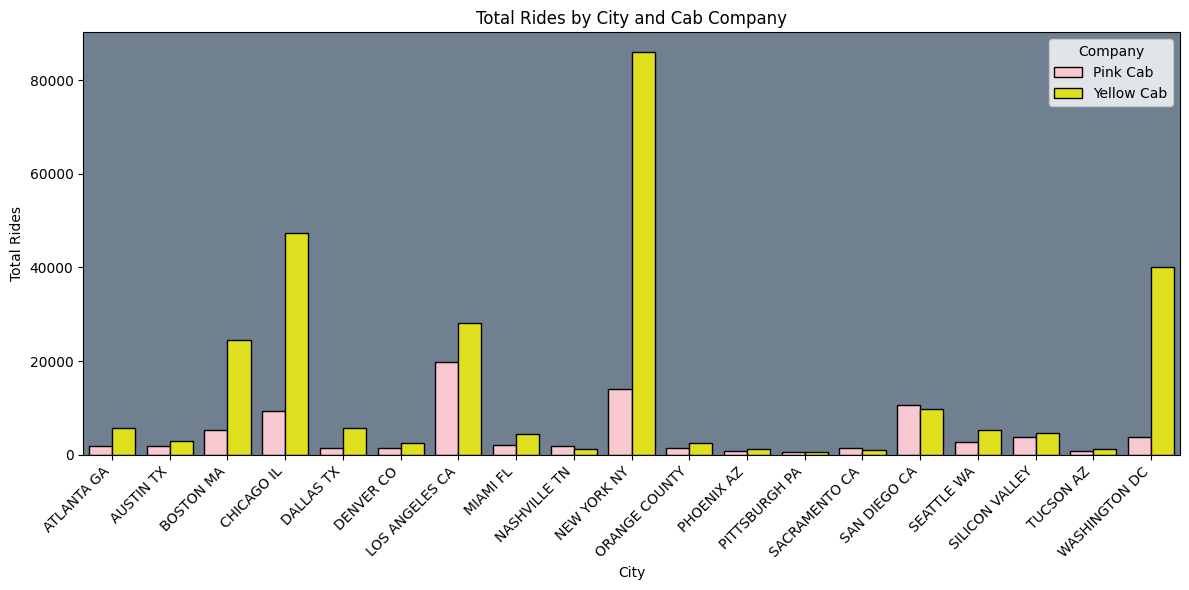

In [133]:
# Use Bar chart to chart total rides grouped by city and company
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Group data by City and Company, then count total rides
rides_by_city_company = master1_df.groupby(['City', 'Company'])['Transaction ID'].count().reset_index()

# Create the bar plot using seaborn
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
sns.barplot(x='City', y='Transaction ID', hue='Company', data=rides_by_city_company,
            palette={'Yellow Cab': 'yellow', 'Pink Cab': 'pink'}, edgecolor='black')

plt.title('Total Rides by City and Cab Company')
plt.xlabel('City')
plt.ylabel('Total Rides')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

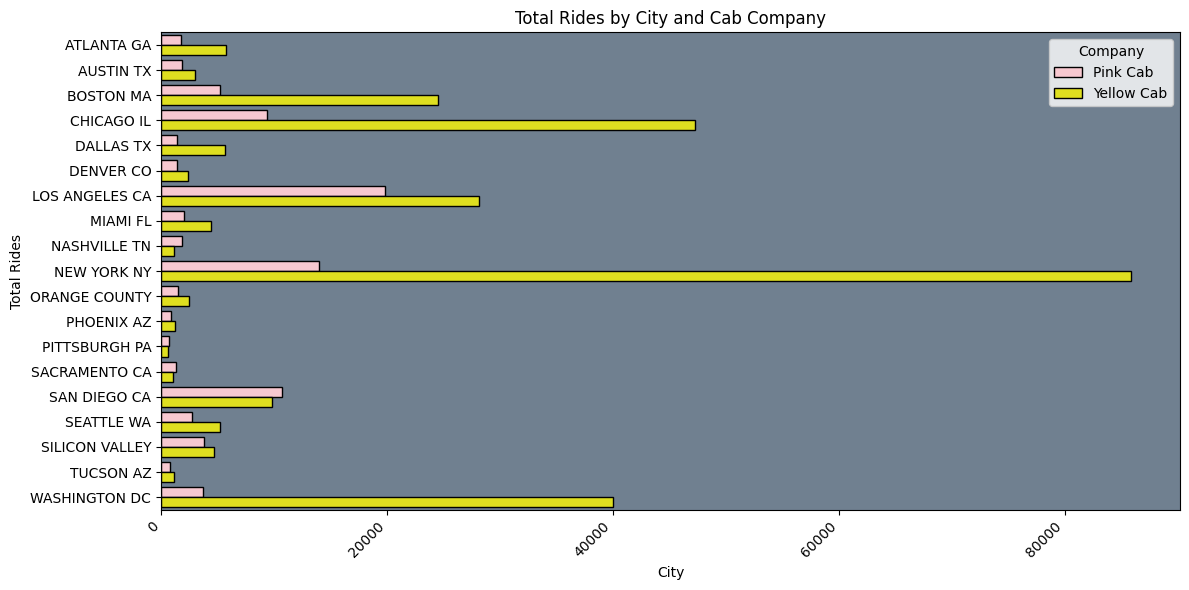

In [134]:
# Use Bar chart to chart total rides grouped by city and company
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Group data by City and Company, then count total rides
rides_by_city_company = master1_df.groupby(['City', 'Company'])['Transaction ID'].count().reset_index()

# Create the bar plot using seaborn
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
sns.barplot(y='City', x='Transaction ID', hue='Company', data=rides_by_city_company,
            palette={'Yellow Cab': 'yellow', 'Pink Cab': 'pink'}, edgecolor='black')

plt.title('Total Rides by City and Cab Company')
plt.xlabel('City')
plt.ylabel('Total Rides')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

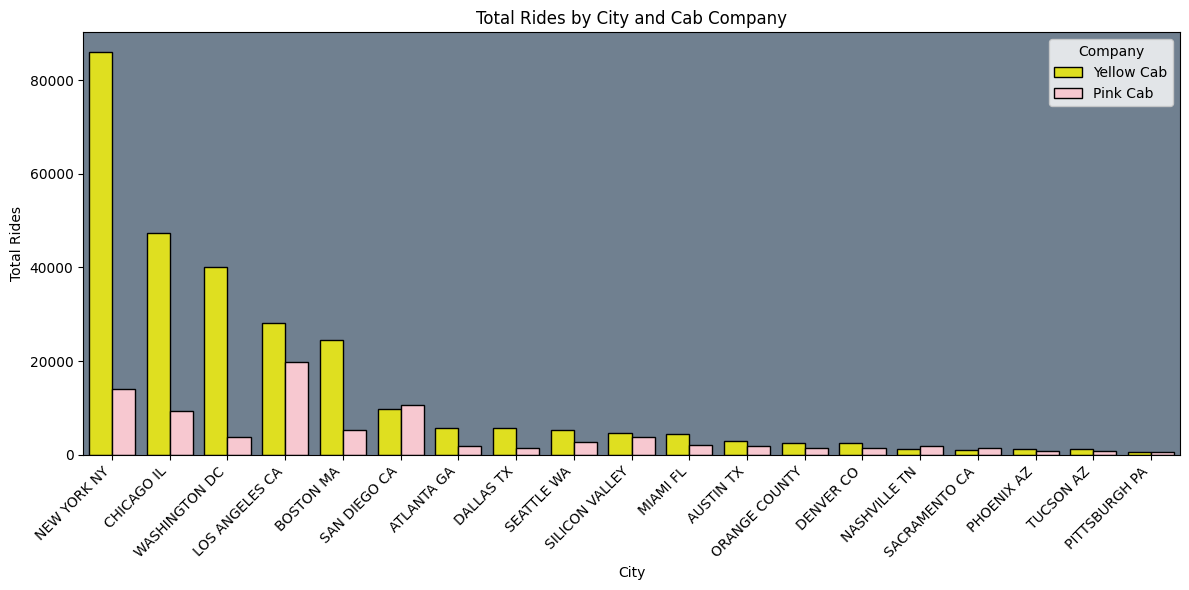

In [135]:
# Use Bar chart to chart total rides grouped by city and company
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Group data by City and Company, then count total rides
rides_by_city_company = master1_df.groupby(['City', 'Company'])['Transaction ID'].count().reset_index()

# Sort the data in descending order based on 'Transaction ID'
rides_by_city_company = rides_by_city_company.sort_values(by=['Transaction ID'], ascending=False)


# Create the bar plot using seaborn
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
sns.barplot(x='City', y='Transaction ID', hue='Company', data=rides_by_city_company,
            palette={'Yellow Cab': 'yellow', 'Pink Cab': 'pink'}, edgecolor='black')

plt.title('Total Rides by City and Cab Company')
plt.xlabel('City')
plt.ylabel('Total Rides')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

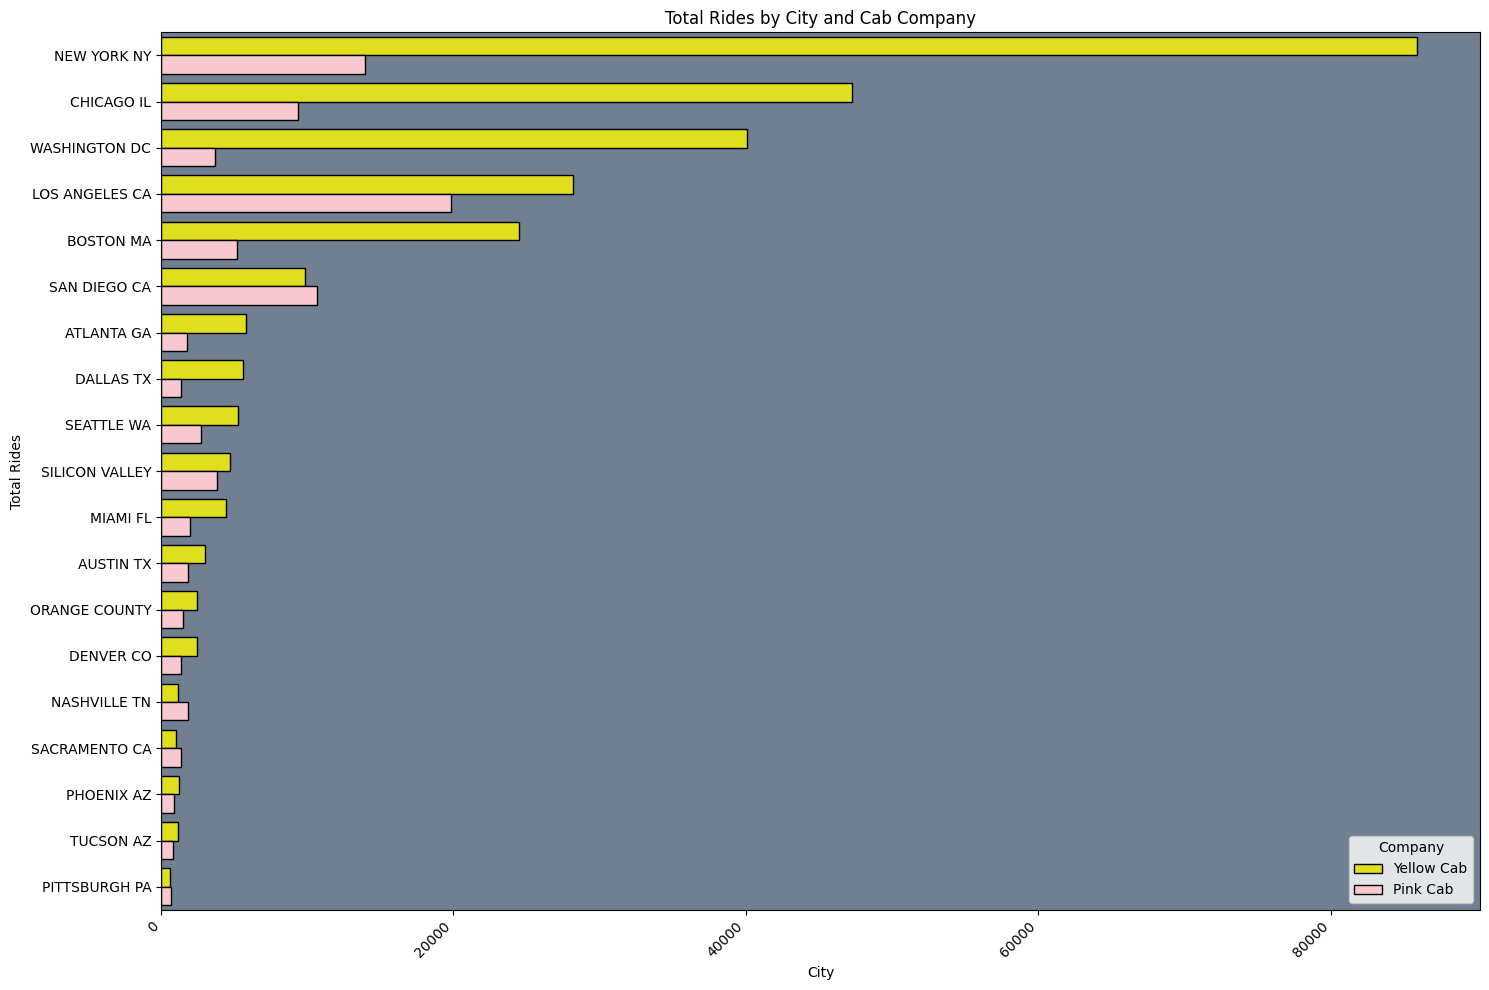

In [136]:
# Use Bar chart to chart total rides grouped by city and company
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Group data by City and Company, then count total rides
rides_by_city_company = master1_df.groupby(['City', 'Company'])['Transaction ID'].count().reset_index()

# Sort the data in descending order based on 'Transaction ID'
rides_by_city_company = rides_by_city_company.sort_values(by=['Transaction ID'], ascending=False)


# Create the bar plot using seaborn
plt.figure(figsize=(15, 10))  # Adjust figure size as needed
sns.barplot(y='City', x='Transaction ID', hue='Company', data=rides_by_city_company,
            palette={'Yellow Cab': 'yellow', 'Pink Cab': 'pink'}, edgecolor='black')

plt.title('Total Rides by City and Cab Company')
plt.xlabel('City')
plt.ylabel('Total Rides')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

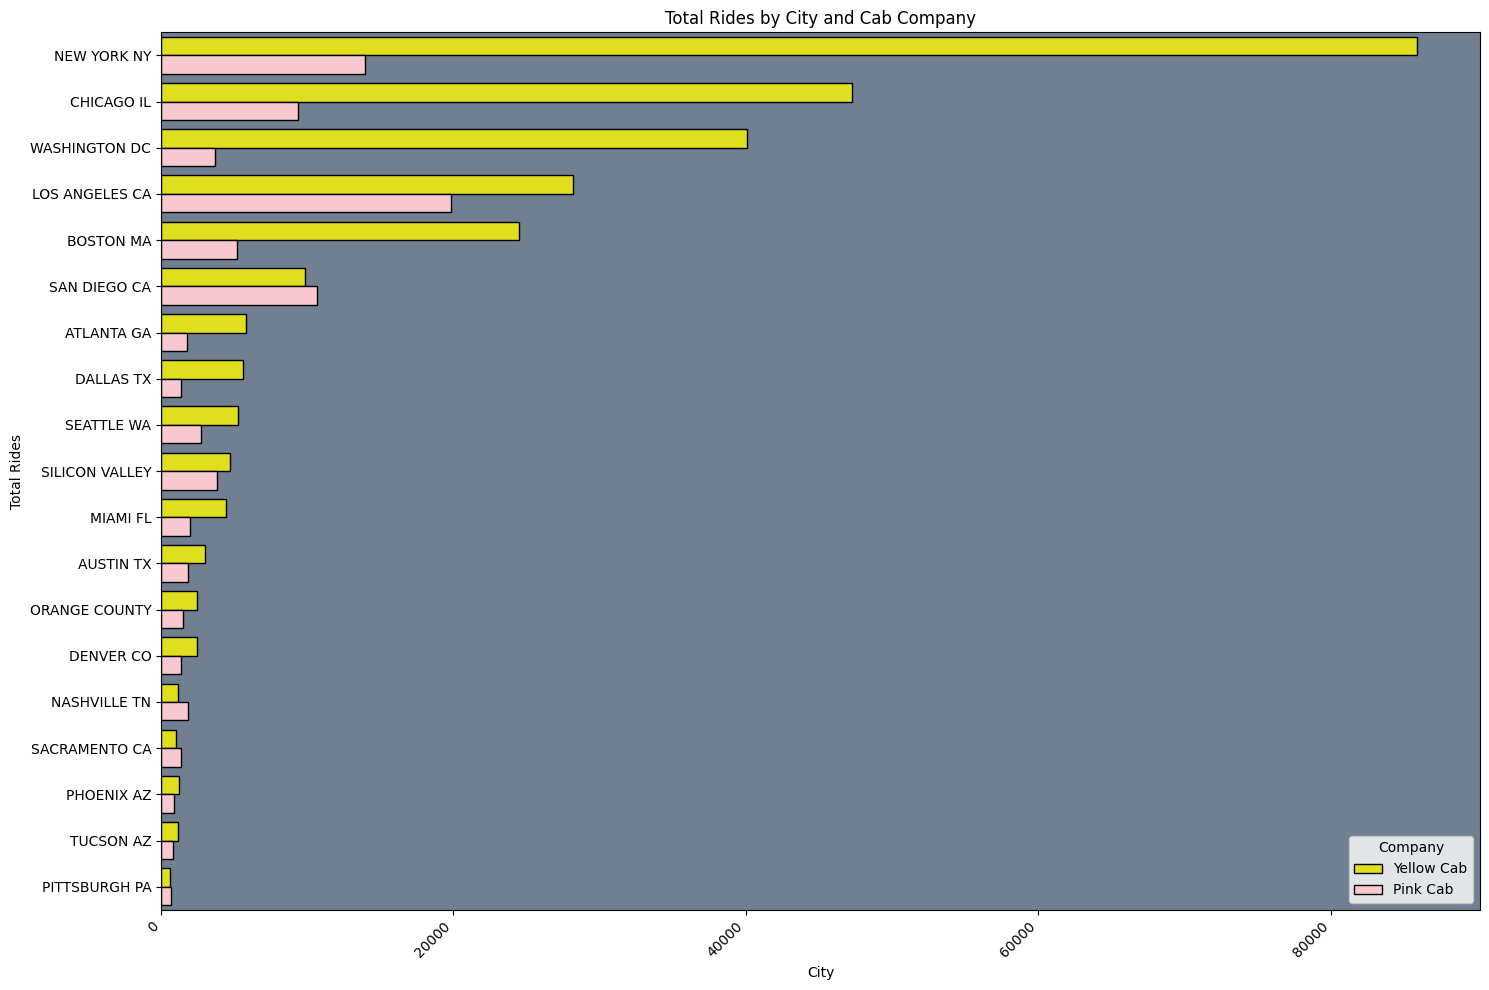

In [137]:
# Use Bar chart to chart total rides grouped by city and company
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Group data by City and Company, then count total rides
rides_by_city_company = master1_df.groupby(['City', 'Company'])['Transaction ID'].count().reset_index()

# Sort the data in descending order based on 'Transaction ID'
rides_by_city_company = rides_by_city_company.sort_values(by=['Transaction ID'], ascending=False)


# Create the bar plot using seaborn
plt.figure(figsize=(15, 10))  # Adjust figure size as needed
sns.barplot(y='City', x='Transaction ID', hue='Company', data=rides_by_city_company,
            palette={'Yellow Cab': 'yellow', 'Pink Cab': 'pink'}, edgecolor='black')

plt.title('Total Rides by City and Cab Company')
plt.xlabel('City')
plt.ylabel('Total Rides')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

In [138]:
# Get the total number of cab rides per company
master1_df['Company'].value_counts()

,count
Company,
Yellow Cab,274681
Pink Cab,84711


In [139]:
# Get the number of rows for total number of cab rides
master1_df.shape

(359392, 27)

## **Hypothesis 2 Result:**

The 5 cities with the highest number of transactions are in the following order: New York, Chicago, Washington DC, Los Angeles, and Boston. In all 5 cities, Yellow Cab gave more rides than Pink Cab.

Pink Cab gave more rides than Yellow cab in only three cities in the following order: San Diego, Nashville, and Sacramento. Yellow CAb gave more rides than Pink Cab in 16 out of the 19 cities.

The total number of rides given during the time period from 1-31-2016 to 12-31-2018, was 359392. Of that total, Yellow Cab gave 274,681 rides and Pink Cab gave 84,711 rides.

Accept Hypotheseis 2: Yellow Cab is more popular than Pink Cab Overall.


# **Hypothesis 3: The profits of cab rides mirrors the number of rides**

In [248]:
# Calculate the average profit per km for yellow cab
yellow_cab_avg_profit_per_km = yellow_cab_df['Profit Per KM'].mean()
yellow_cab_avg_profit_per_km

7.105507808353117

In [249]:
# Calculate the average profit per km for pink cab
pink_cab_avg_profit_per_km = pink_cab_df['Profit Per KM'].mean()
pink_cab_avg_profit_per_km

2.769907700396534

In [250]:
# Calculate average profit per KM for each company per year
yellow_cab_avg_profit_per_km_year = yellow_cab_df.groupby('year')['Profit Per KM'].mean()
yellow_cab_avg_profit_per_km_year

,Profit Per KM
year,
2016,7.489847
2017,7.494612
2018,6.364805


In [251]:
# Calculate average profit per KM for each company per year
pink_cab_avg_profit_per_km_year = pink_cab_df.groupby('year')['Profit Per KM'].mean()
pink_cab_avg_profit_per_km_year

,Profit Per KM
year,
2016,3.026813
2017,2.962883
2018,2.350447


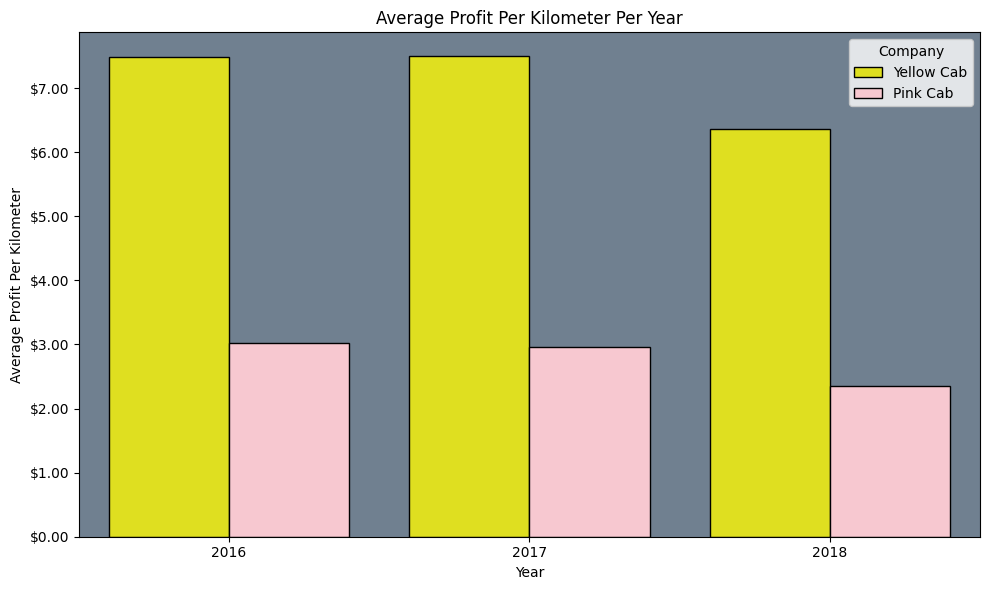

In [252]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Import seaborn for styling
import matplotlib.ticker as ticker # Import the ticker module

# Calculate average profit per kilometer per year for Yellow Cab
yellow_cab_avg_profit_per_km_year = yellow_cab_df.groupby('year')['Profit Per KM'].mean()

# Calculate average profit per kilometer per year for Pink Cab
pink_cab_avg_profit_per_km_year = pink_cab_df.groupby('year')['Profit Per KM'].mean()

# Create a DataFrame for plotting
profit_per_km_df = pd.DataFrame({
    'Year': yellow_cab_avg_profit_per_km_year.index,
    'Yellow Cab': yellow_cab_avg_profit_per_km_year.values,
    'Pink Cab': pink_cab_avg_profit_per_km_year.values
})

# Melt the DataFrame to create a long-form dataset for seaborn
profit_per_km_melted = pd.melt(profit_per_km_df, id_vars=['Year'],
                                 value_vars=['Yellow Cab', 'Pink Cab'],
                                 var_name='Company', value_name='Avg Profit Per KM')

# Create the bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Avg Profit Per KM', hue='Company', data=profit_per_km_melted,
            palette={'Yellow Cab': 'yellow', 'Pink Cab': 'pink'}, edgecolor='black')

plt.title('Average Profit Per Kilometer Per Year')
plt.xlabel('Year')
plt.ylabel('Average Profit Per Kilometer')

# Set background color
ax = plt.gca()  # Get current axes
ax.set_facecolor('slategray')

# Format y-axis as dollars
formatter = ticker.StrMethodFormatter('${x:,.2f}')  # Format with dollar sign and 2 decimal places
ax.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

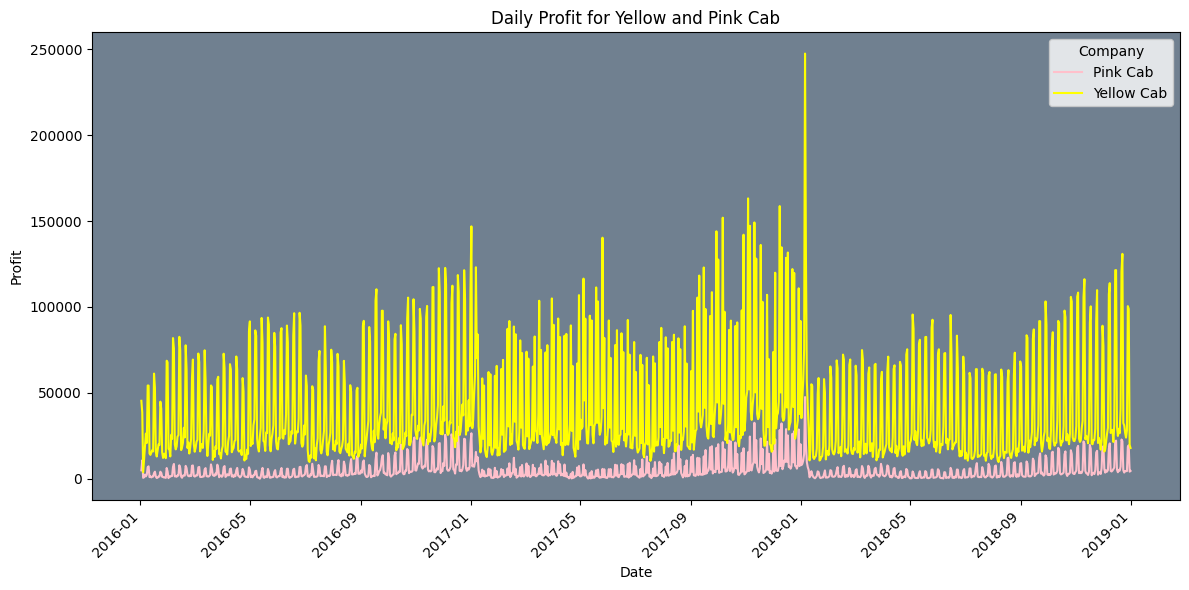

<ipython-input-261-6ead49a284d0>:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_profit_master = master1_df.groupby(['year', 'month_name', 'Company'])['Profit'].sum().reset_index()


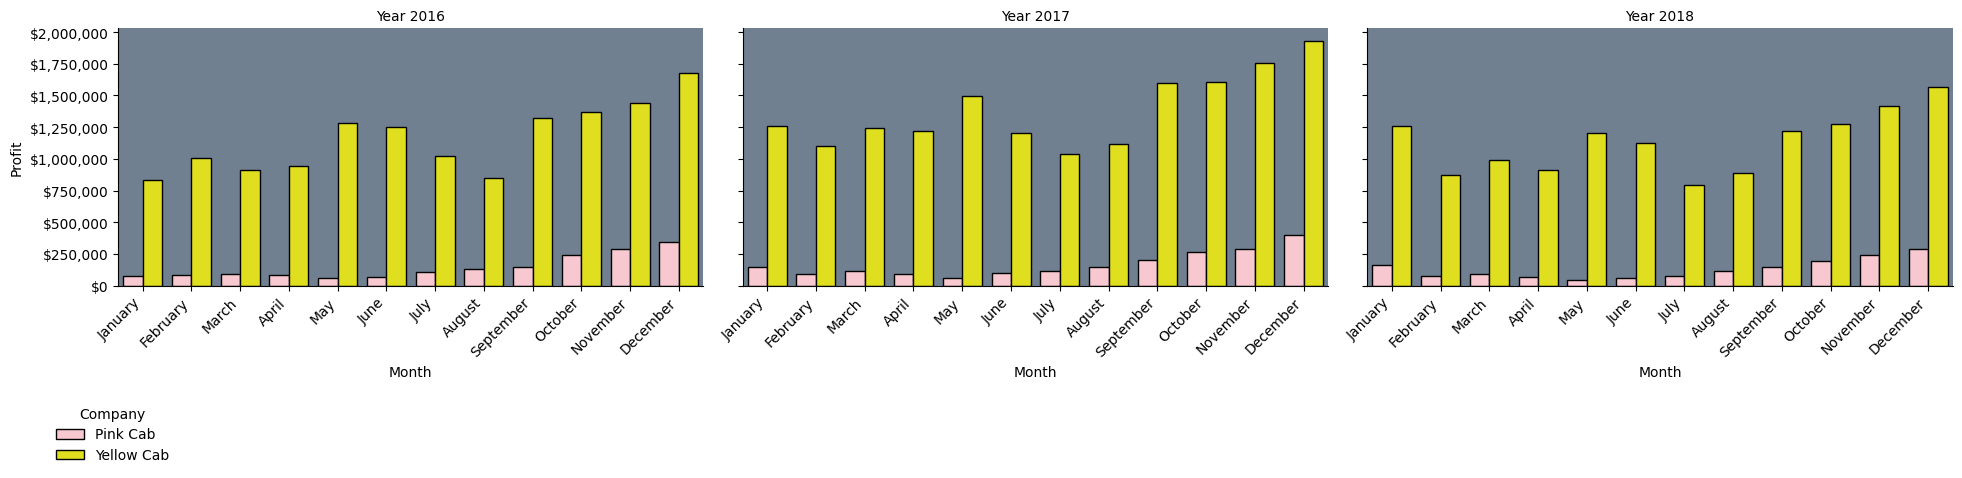

In [261]:
# Daily Profit Chart
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
import calendar  # Import calendar for month names

# Assuming 'master1_df' contains your data with 'month', 'year', 'Company', and 'Profit' columns

# 1. Calculate and Plot Daily Profits:
daily_profit = master1_df.groupby(['date', 'Company'])['Profit'].sum().reset_index()

# Convert 'date' column to datetime objects
daily_profit['date'] = pd.to_datetime(daily_profit['date'])


plt.figure(figsize=(12, 6))
# Create the ax object here
fig, ax = plt.subplots(figsize=(12, 6))

# Set the background color of the plot to slategray
ax.set_facecolor('slategray')

sns.lineplot(x='date', y='Profit', hue='Company', data=daily_profit,
             palette=company_colors, ax=ax)  # Pass ax to sns.lineplot

plt.title('Daily Profit for Yellow and Pink Cab')
plt.xlabel('Date')
plt.ylabel('Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Set background color for each subplot and format y-axis
for ax in g.axes.flat:
    #ax.set_facecolor('slategray')
    formatter = ticker.StrMethodFormatter('${x:,.0f}')  # Format with dollar sign and comma separator
    ax.yaxis.set_major_formatter(formatter)

plt.show()

# 2. Monthly Profit Charts:

# Map month numbers to month names for the entire DataFrame
master1_df['month_name'] = master1_df['month'].apply(lambda x: calendar.month_name[x])

# Define the desired order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Convert 'month_name' to categorical with ordered months
master1_df['month_name'] = pd.Categorical(master1_df['month_name'], categories=month_order, ordered=True)

# Assign color for the different companies
company_colors = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Calculate monthly profit for master1_df for yellow cab and pink cab
monthly_profit_master = master1_df.groupby(['year', 'month_name', 'Company'])['Profit'].sum().reset_index()

# Create small multiple plots for each year
g = sns.FacetGrid(monthly_profit_master, col='year', height=4, aspect=1.5)  # Use FacetGrid for small multiples

# Use sns.barplot to plot profits instead of countplot
# Pass the 'data' argument directly to sns.barplot
g.map(sns.barplot, 'month_name', 'Profit', hue='Company', data=monthly_profit_master,  # Pass data here
      palette=company_colors, edgecolor='black', order=month_order, errorbar=None)

g.set_titles("Year {col_name}")  # Set titles for each subplot
g.set_xticklabels(rotation=45, ha='right')  # Rotate x-axis labels
g.set_axis_labels("Month", "Profit")  # Set axis labels

# Add a legend and position it in the top left corner
g.add_legend(title='Company', loc='upper left', bbox_to_anchor=(0, 0))

plt.tight_layout()

# Set background color for each subplot and format y-axis
for ax in g.axes.flat:
    ax.set_facecolor('slategray')
    formatter = ticker.StrMethodFormatter('${x:,.0f}')  # Format with dollar sign and comma separator
    ax.yaxis.set_major_formatter(formatter)

plt.show()

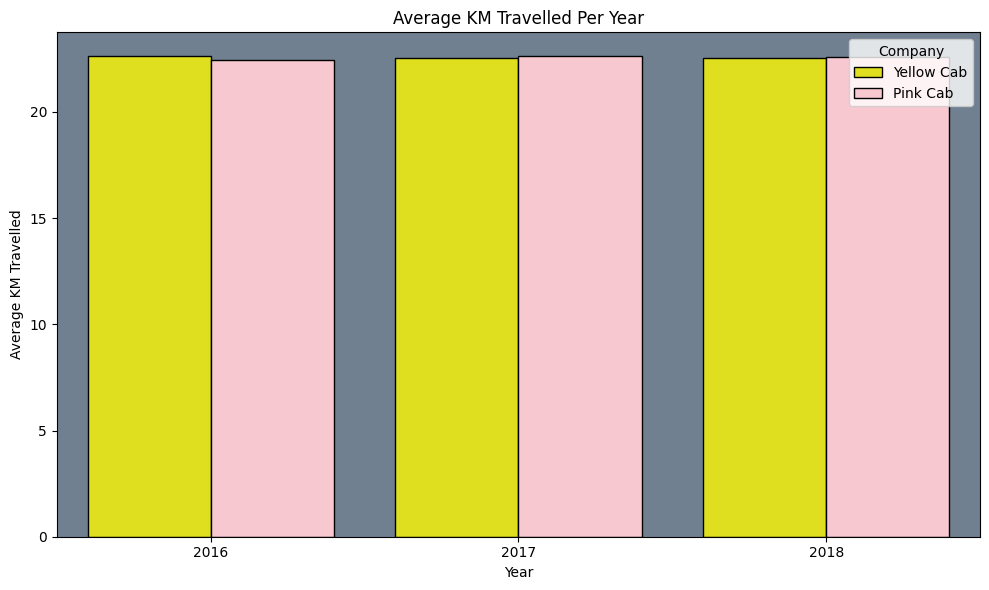

In [253]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Import seaborn for styling
import matplotlib.ticker as ticker # Import the ticker module

# Calculate average KM Travelled per year for Yellow Cab
yellow_cab_avg_km_year = yellow_cab_df.groupby('year')['KM Travelled'].mean()

# Calculate average KM Travelled per year for Pink Cab
pink_cab_avg_km_year = pink_cab_df.groupby('year')['KM Travelled'].mean()

# Create a DataFrame for plotting
km_travelled_per_year_df = pd.DataFrame({
    'Year': yellow_cab_avg_km_year.index,
    'Yellow Cab': yellow_cab_avg_km_year.values,
    'Pink Cab': pink_cab_avg_km_year.values
})

# Melt the DataFrame to create a long-form dataset for seaborn
km_travelled_per_year_melted = pd.melt(km_travelled_per_year_df, id_vars=['Year'],
                                 value_vars=['Yellow Cab', 'Pink Cab'],
                                 var_name='Company', value_name='Avg KM Travelled')

# Create the bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Avg KM Travelled', hue='Company', data=km_travelled_per_year_melted,
            palette={'Yellow Cab': 'yellow', 'Pink Cab': 'pink'}, edgecolor='black')

plt.title('Average KM Travelled Per Year')  # Updated title
plt.xlabel('Year')
plt.ylabel('Average KM Travelled')  # Updated y-axis label

# Set background color
ax = plt.gca()  # Get current axes
ax.set_facecolor('slategray')

# Format y-axis (no need for dollar formatting since it is KM)
#formatter = ticker.StrMethodFormatter('${x:,.2f}')  # Format with dollar sign and 2 decimal places
#ax.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

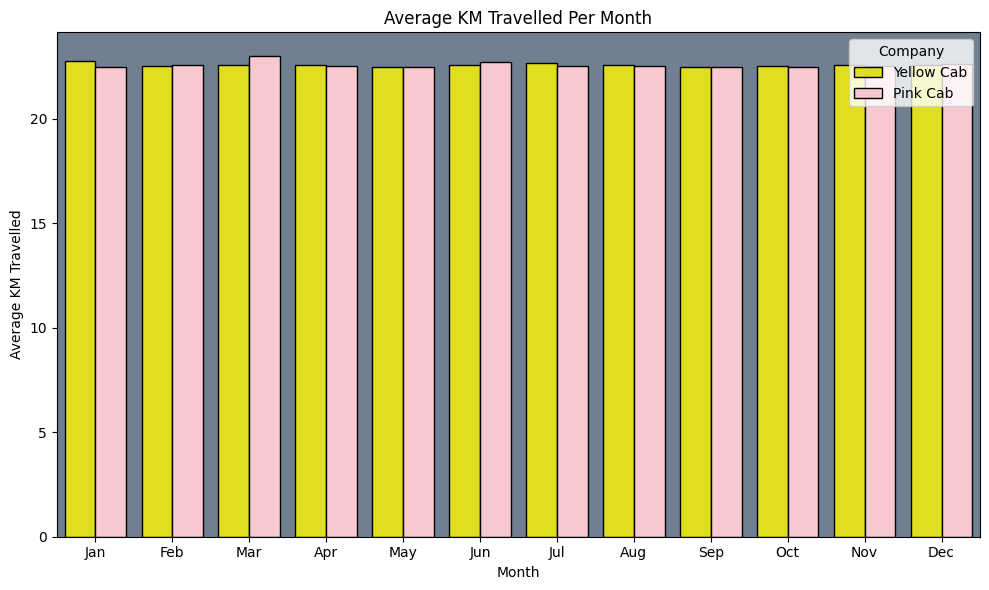

In [254]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Import seaborn for styling
import matplotlib.ticker as ticker # Import the ticker module
import calendar #to map month numbers to month names

# Calculate average KM Travelled per month for Yellow Cab
yellow_cab_avg_km_month = yellow_cab_df.groupby('month')['KM Travelled'].mean()

# Calculate average KM Travelled per month for Pink Cab
pink_cab_avg_km_month = pink_cab_df.groupby('month')['KM Travelled'].mean()

# Create a DataFrame for plotting
km_travelled_per_month_df = pd.DataFrame({
    'Month': yellow_cab_avg_km_month.index,
    'Yellow Cab': yellow_cab_avg_km_month.values,
    'Pink Cab': pink_cab_avg_km_month.values
})

# Map month numbers to month names
km_travelled_per_month_df['Month'] = km_travelled_per_month_df['Month'].apply(lambda x: calendar.month_abbr[x])


# Melt the DataFrame to create a long-form dataset for seaborn
km_travelled_per_month_melted = pd.melt(km_travelled_per_month_df, id_vars=['Month'],
                                 value_vars=['Yellow Cab', 'Pink Cab'],
                                 var_name='Company', value_name='Avg KM Travelled')

# Create the bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Avg KM Travelled', hue='Company', data=km_travelled_per_month_melted,
            palette={'Yellow Cab': 'yellow', 'Pink Cab': 'pink'}, edgecolor='black')

plt.title('Average KM Travelled Per Month')  # Updated title
plt.xlabel('Month')  # Updated x-axis label
plt.ylabel('Average KM Travelled')  # Updated y-axis label

# Set background color
ax = plt.gca()  # Get current axes
ax.set_facecolor('slategray')

# Format y-axis (no need for dollar formatting since it is KM)
#formatter = ticker.StrMethodFormatter('${x:,.2f}')  # Format with dollar sign and 2 decimal places
#ax.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

In [255]:
master1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359392 entries, 0 to 359391
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               359392 non-null  int64         
 1   Transaction ID      359392 non-null  int64         
 2   Date of Travel      359392 non-null  int64         
 3   Date Time Stamp     359392 non-null  datetime64[ns]
 4   Company             359392 non-null  object        
 5   City                359392 non-null  object        
 6   KM Travelled        359392 non-null  float64       
 7   Price Charged       359392 non-null  float64       
 8   Cost of Trip        359392 non-null  float64       
 9   date                359392 non-null  datetime64[ns]
 10  time                359392 non-null  object        
 11  month               359392 non-null  int32         
 12  year                359392 non-null  int32         
 13  day                 359392 no

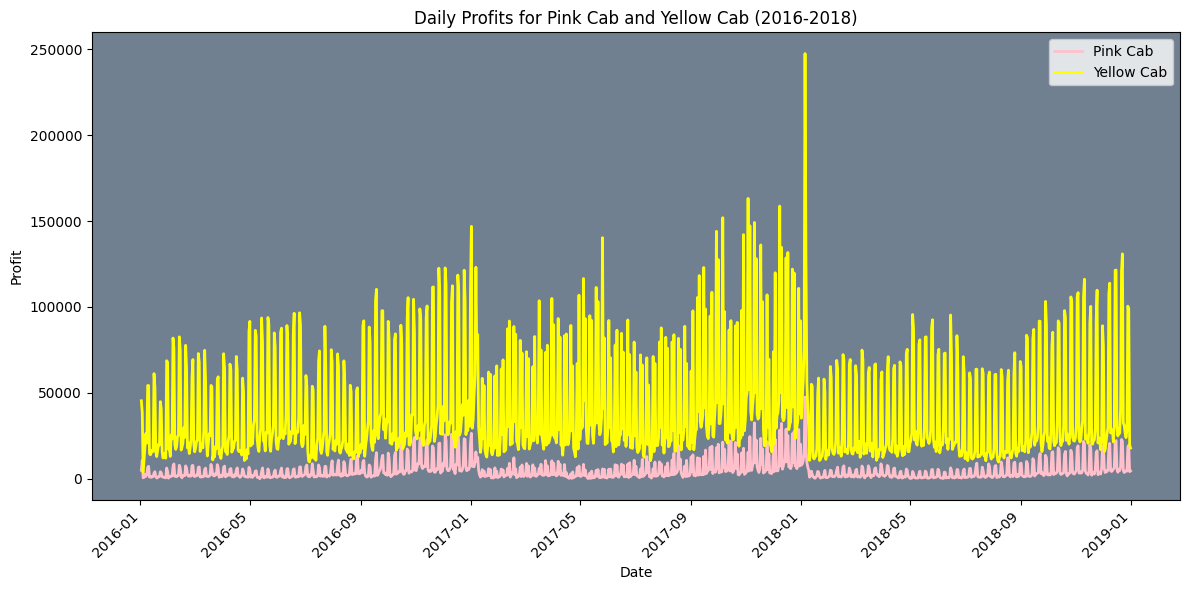

In [256]:
# Daily Profits Line plot
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'master1_df' contains your data with 'date', 'Company', and 'Profit' columns

# Group data by date and company, then sum profits
profits_by_date_company = master1_df.groupby(['date', 'Company'])['Profit'].sum().reset_index()

# Filter data for Pink Cab and Yellow Cab
pink_cab_data = profits_by_date_company[profits_by_date_company['Company'] == 'Pink Cab']
yellow_cab_data = profits_by_date_company[profits_by_date_company['Company'] == 'Yellow Cab']

# Create the line plot with increased line weight
plt.figure(figsize=(12, 6))  # Adjust figure size for better visualization
plt.plot(pink_cab_data['date'], pink_cab_data['Profit'], color='pink', label='Pink Cab', linewidth=2)
plt.plot(yellow_cab_data['date'], yellow_cab_data['Profit'], color='yellow', label='Yellow Cab', linewidth=2)

plt.title('Daily Profits for Pink Cab and Yellow Cab (2016-2018)')
plt.xlabel('Date')
plt.ylabel('Profit')
plt.xticks(rotation=45, ha='right')
plt.legend()  # Add a legend to distinguish the lines
plt.tight_layout()

# Set background color
ax = plt.gca()  # Get current axes
ax.set_facecolor('slategray')

plt.show()

In [257]:
profits_by_month_company = master1_df.groupby(['month_name', 'Company'])['Profit'].sum().reset_index()
print(profits_by_month_company)

   month_name     Company        Profit
0     January    Pink Cab  3.880546e+05
1     January  Yellow Cab  3.358436e+06
2    February    Pink Cab  2.520413e+05
3    February  Yellow Cab  2.975979e+06
4       March    Pink Cab  2.990966e+05
5       March  Yellow Cab  3.151215e+06
6       April    Pink Cab  2.458181e+05
7       April  Yellow Cab  3.075543e+06
8         May    Pink Cab  1.686139e+05
9         May  Yellow Cab  3.983544e+06
10       June    Pink Cab  2.327152e+05
11       June  Yellow Cab  3.580338e+06
12       July    Pink Cab  3.018851e+05
13       July  Yellow Cab  2.861562e+06
14     August    Pink Cab  3.882513e+05
15     August  Yellow Cab  2.856271e+06
16  September    Pink Cab  4.944353e+05
17  September  Yellow Cab  4.142382e+06
18    October    Pink Cab  6.964371e+05
19    October  Yellow Cab  4.250512e+06
20   November    Pink Cab  8.103262e+05
21   November  Yellow Cab  4.609321e+06
22   December    Pink Cab  1.029654e+06
23   December  Yellow Cab  5.175271e+06


<ipython-input-257-29cf952da1df>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profits_by_month_company = master1_df.groupby(['month_name', 'Company'])['Profit'].sum().reset_index()


<ipython-input-258-5215d0cb33c1>:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profits_by_month_company = master1_df.groupby(['month_name', 'Company'])['Profit'].sum().reset_index()


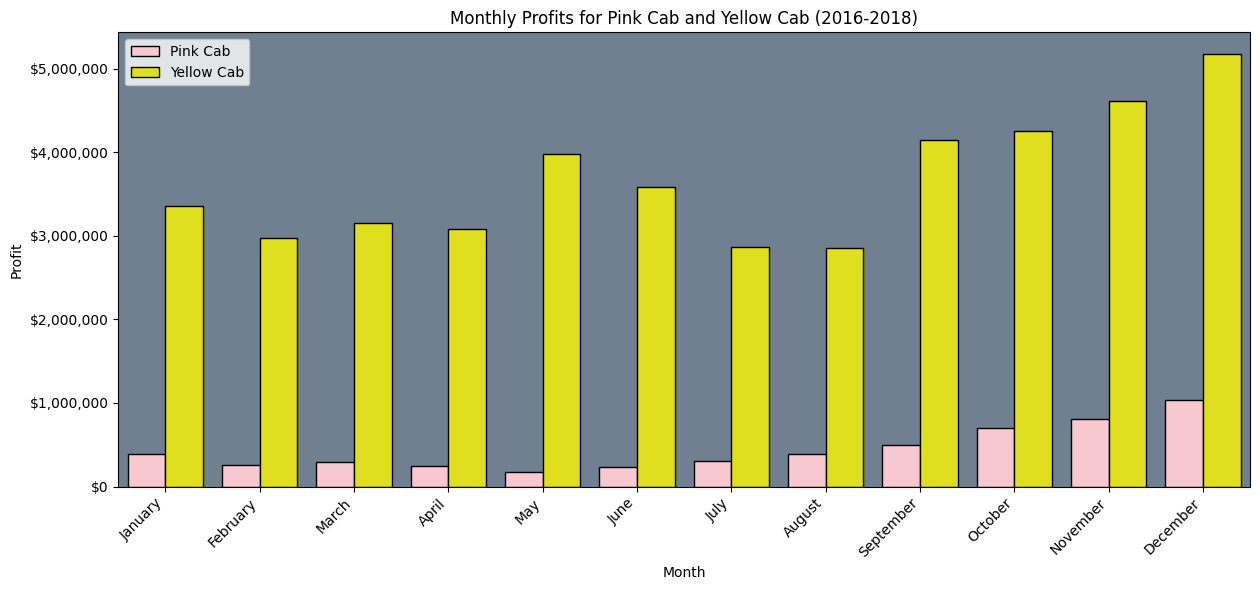

In [258]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker  # Import ticker for formatting

# Assuming 'master1_df' contains your data with 'month_name', 'Company', and 'Profit' columns

# Define the desired order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Convert 'month_name' to categorical with ordered months
master1_df['month_name'] = pd.Categorical(master1_df['month_name'], categories=month_order, ordered=True)


# Group data by month and company, then sum profits
profits_by_month_company = master1_df.groupby(['month_name', 'Company'])['Profit'].sum().reset_index()

# Filter data for Pink Cab and Yellow Cab
pink_cab_data = profits_by_month_company[profits_by_month_company['Company'] == 'Pink Cab']
yellow_cab_data = profits_by_month_company[profits_by_month_company['Company'] == 'Yellow Cab']

# Create the bar plot
plt.figure(figsize=(12, 6))  # Adjust figure size for better visualization
sns.barplot(x='month_name', y='Profit', hue='Company', data=profits_by_month_company,
            palette={'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}, edgecolor='black', order=month_order)

plt.title('Monthly Profits for Pink Cab and Yellow Cab (2016-2018)')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=45, ha='right')
plt.legend()  # Add a legend to distinguish the lines
plt.tight_layout()

# Set background color
ax = plt.gca()  # Get current axes
ax.set_facecolor('slategray')

# Format y-axis as dollars
formatter = ticker.StrMethodFormatter('${x:,.0f}')  # Format with dollar sign and comma separator
ax.yaxis.set_major_formatter(formatter)

plt.show()

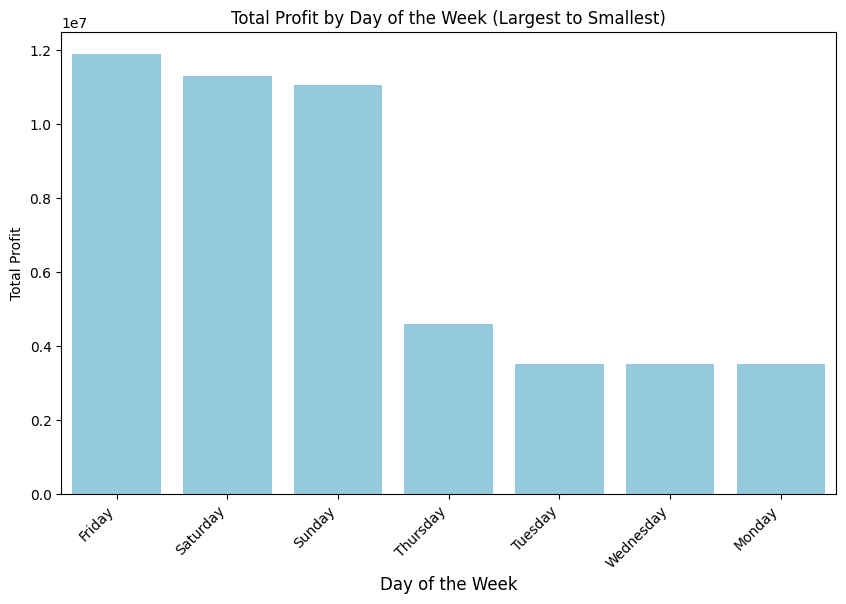

Hypothesis 2: Are the profits for cab rides higher during the week than the weekend?


In [259]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Group profits by day of the week and calculate the total profit for each day
profit_by_day = master1_df.groupby('day_name')['Profit'].sum().reset_index()

# Sort days by total profit (descending)
day_order = profit_by_day.sort_values(by='Profit', ascending=False)['day_name']

# Create the bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='day_name', y='Profit', data=profit_by_day, order=day_order, color='skyblue')

plt.title('Total Profit by Day of the Week (Largest to Smallest)')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()
print("Hypothesis 2: Are the profits for cab rides higher during the week than the weekend?")

In [260]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calculate total profit per day for each company
profit_by_day = master1_df.groupby(['day_name', 'Company'])['Profit'].sum().reset_index()

# Sort days by total profit (descending), considering both companies
day_order = profit_by_day.groupby('day_name')['Profit'].sum().sort_values(ascending=False).index

# Assign colors for the companies
company_colors = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Create the bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(y='day_name', x='Profit', hue='Company', data=profit_by_day, order=day_order, palette=company_colors, edgecolor='black',)

plt.title('Total Profit by Day of the Week (Largest to Smallest)')
plt.xlabel('Total Profit', fontsize=12)
plt.ylabel('Day of the Week')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.legend(title='Company')  # Add a legend for company colors

# Set background color to slateblue
ax = plt.gca()  # Get current axes
ax.set_facecolor('slategray')

plt.show()
print("Hypothesis 2: Are the profits for cab rides higher during the week than the weekend?")

KeyboardInterrupt: 

# **Hypothesis 4: There is seasonality throughout the year for cab rides.**

In [235]:
# Define the desired order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Convert the 'month_name' column to a categorical data type with the specified order
master1_df['month_name'] = pd.Categorical(master1_df['month_name'], categories=month_order, ordered=True)

# Sort the DataFrame based on the 'month_name' column
master1_df_sorted = master1_df.sort_values(by='month_name')

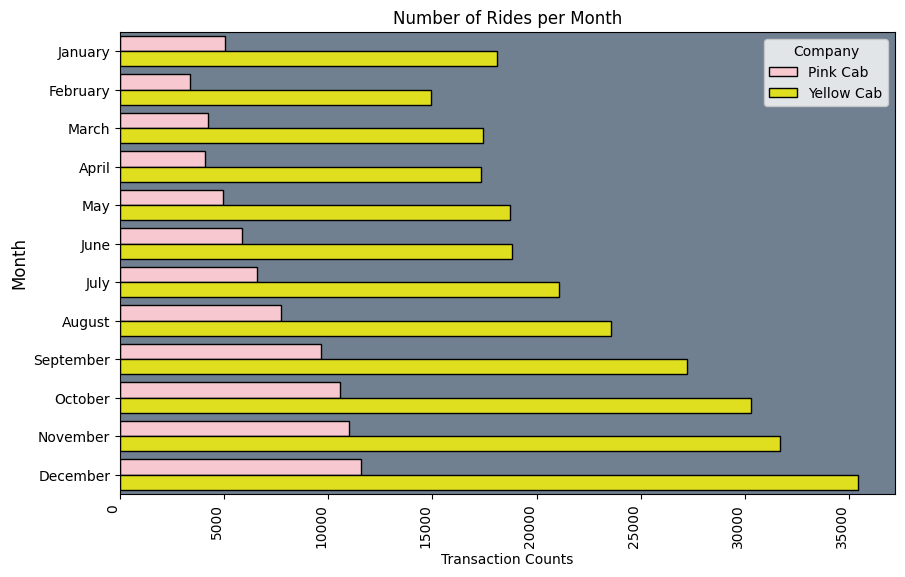

Hypothesis 4: Is there seasonality in demand?


In [160]:
# Hypothesis 4: Seasonality of Transactions
# Plot of Cab Transactions by month
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the order of days based on frequency#
#day_order = master1_df['month'].value_counts().index

# Assign color for the different companies
company_colors = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Create the countplot with the specified order
plt.figure(figsize=(10, 6))  # Adjust figure size if needed
sns.countplot(
             y='month_name',
             #order = day_order,
             data=master1_df_sorted,
             #order=day_order,
             hue='Company',
             palette=company_colors,
             edgecolor='black',
             #legend=False
             )
plt.title('Number of Rides per Month')
plt.xlabel('Transaction Counts')
plt.ylabel('Month', fontsize=12)
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better readability

# Set background color
ax = plt.gca()  # Get current axes
ax.set_facecolor('slategray')

plt.show()
print("Hypothesis 4: Is there seasonality in demand?")

# **Hypothesis 5: There is seasonality throughout the month for cab rides**

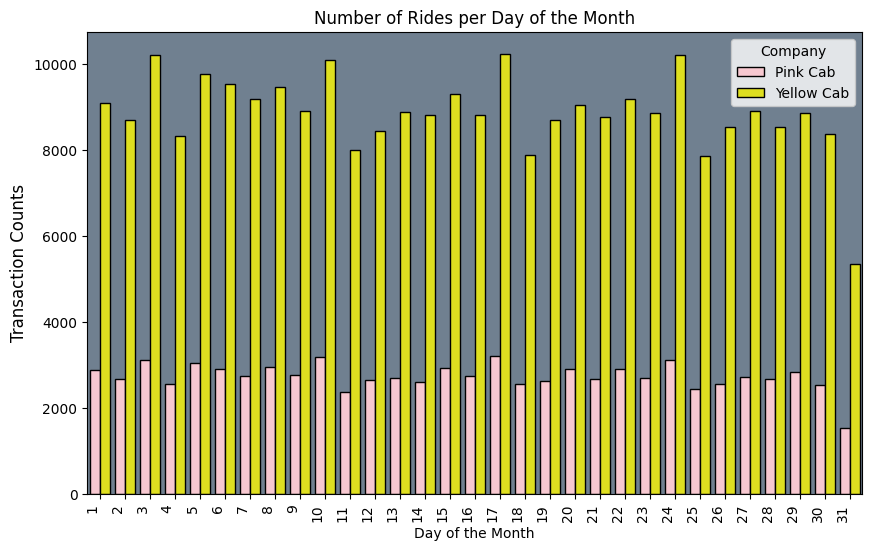

Hypothesis 4: Is there seasonality in demand?


In [236]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assign color for the different companies
company_colors = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Create the countplot with the specified order
plt.figure(figsize=(10, 6))  # Adjust figure size if needed
sns.countplot(
    x='day',  # Changed to 'day' for day of the month
    data=master1_df,
    hue='Company',
    palette=company_colors,
    edgecolor='black',
)
plt.title('Number of Rides per Day of the Month')
plt.xlabel('Day of the Month')
plt.ylabel('Transaction Counts', fontsize=12)
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better readability

# Set background color
ax = plt.gca()  # Get current axes
ax.set_facecolor('slategray')

plt.show()
print("Hypothesis 4: Is there seasonality in demand?")

# **Hypothesis 6: There is seasonality throughout the week for cab rides**

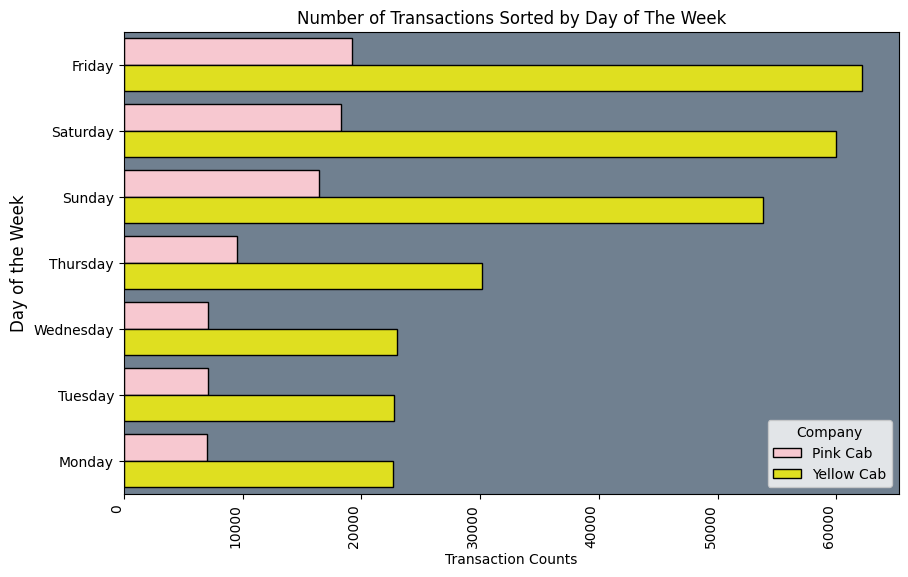

Hypothesis 1: Is the demand for cab rides greater on the weekdays than weekends?


In [157]:
# Plot of Cab Transactions by day of the week
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the order of days based on frequency
day_order = master1_df['day_name'].value_counts().index

# Assign color for the different companies
company_colors = {'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}

# Create the countplot with the specified order
plt.figure(figsize=(10, 6))  # Adjust figure size if needed
sns.countplot(
             y='day_name',
             order = day_order,
             data=master1_df,
             #order=day_order,
             hue='Company',
             palette=company_colors,
             edgecolor='black',
             #legend=False
             )
plt.title('Number of Transactions Sorted by Day of The Week')
plt.xlabel('Transaction Counts')
plt.ylabel('Day of the Week', fontsize=12)
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better readability

# Set background color
ax = plt.gca()  # Get current axes
ax.set_facecolor('slategray')

plt.show()
print("Hypothesis 1: Is the demand for cab rides greater on the weekdays than weekends?")

In [158]:
# Define the desired order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Convert the 'month_name' column to a categorical data type with the specified order
master1_df['month_name'] = pd.Categorical(master1_df['month_name'], categories=month_order, ordered=True)

# Sort the DataFrame based on the 'month_name' column
master1_df_sorted = master1_df.sort_values(by='month_name')

# **Hypothesis 7: There is seasonality throughout the day for cab rides**

In [ ]:
# No data for times duting the day

# **Hypothesis 8: There is seasonality in US holidays for cab rides**

# **Hypothesis 9: Cab rides cost more in higher populated cities than lower populated cities**

# **Hypothesis 10: The majority of cab riders are in higher income brackets in higher populated cities**

In [ ]:
#

# **Hypothesis 11: The majority of cab riders in medium populated cities are in the middle class income bracket**

# **Hypothesis 12: Percentwise, more women take Pink Cab than Yellow Cab as return riders**

In [187]:
master1_df['Gender'].value_counts()

,count
Gender,
Male,205912
Female,153480


In [188]:
master1_df['Gender'].nunique()

2

In [189]:
master1_df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [190]:
# Compare ages
ages = (master1_df['Age'].value_counts())

# sort ages
ages = ages.sort_index()
print(ages)

Age
18    10846
19    11591
20    12229
21    11431
22    11796
23    12327
24    11151
25    11973
26    11655
27    12030
28    11163
29    10675
30    11165
31    10930
32    11959
33    11457
34    11825
35    10555
36    11054
37    11086
38    10906
39    11798
40    11536
41     3852
42     3970
43     3823
44     3725
45     4248
46     3918
47     4087
48     3700
49     4158
50     4089
51     3931
52     3784
53     3641
54     3810
55     3442
56     3742
57     3473
58     4107
59     4068
60     3775
61     4361
62     3530
63     3733
64     3908
65     3379
Name: count, dtype: int64


In [191]:
# vicenarian 20-29, tricenarian 30-39
# quadrigenarian 40-49, quinquagenarian 50-59, sexagenarian 60-69
# break down ages by groups
# 18-24, 25-34, 35-44, 45-54, 55-65


g0 = master1_df[(master1_df['Age'] >=18) & (master1_df['Age'] <=24)]
g1 = master1_df[(master1_df['Age'] >=24) & (master1_df['Age'] <=34)]
g2 = master1_df[(master1_df['Age'] >=35) & (master1_df['Age'] <=44)]
g3 = master1_df[(master1_df['Age'] >=45) & (master1_df['Age'] <=54)]
g4 = master1_df[(master1_df['Age'] >=55) & (master1_df['Age'] <=64)]
g5 = master1_df[(master1_df['Age'] >=65)]

print("group 0:",g0['Age'].value_counts().sort_index())
print("group 1:",g1['Age'].value_counts().sort_index())
print("group 2:",g2['Age'].value_counts().sort_index())
print("group 3:",g3['Age'].value_counts().sort_index())
print("group 4:",g4['Age'].value_counts().sort_index())
print("group 5:",g5['Age'].value_counts().sort_index())

group 0: Age
18    10846
19    11591
20    12229
21    11431
22    11796
23    12327
24    11151
Name: count, dtype: int64
group 1: Age
24    11151
25    11973
26    11655
27    12030
28    11163
29    10675
30    11165
31    10930
32    11959
33    11457
34    11825
Name: count, dtype: int64
group 2: Age
35    10555
36    11054
37    11086
38    10906
39    11798
40    11536
41     3852
42     3970
43     3823
44     3725
Name: count, dtype: int64
group 3: Age
45    4248
46    3918
47    4087
48    3700
49    4158
50    4089
51    3931
52    3784
53    3641
54    3810
Name: count, dtype: int64
group 4: Age
55    3442
56    3742
57    3473
58    4107
59    4068
60    3775
61    4361
62    3530
63    3733
64    3908
Name: count, dtype: int64
group 5: Age
65    3379
Name: count, dtype: int64


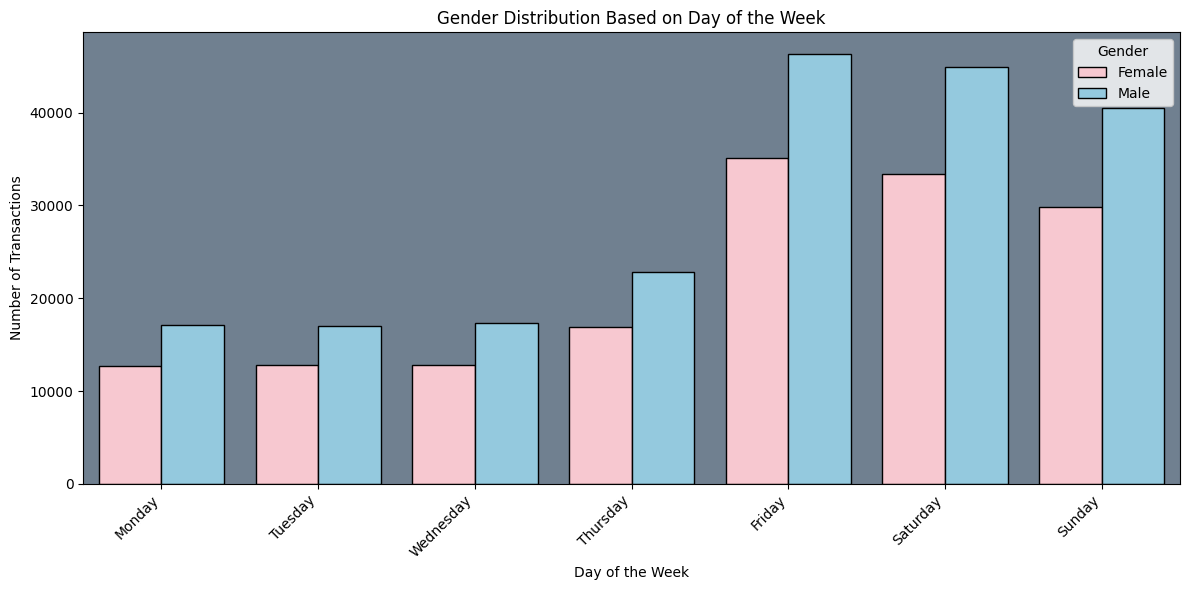

In [192]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group data by day of the week and gender, then count occurrences
gender_by_day = master1_df.groupby(['day_name', 'Gender'])['Transaction ID'].count().reset_index()

# Define the desired order of days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Convert 'day_name' to categorical with ordered days
gender_by_day['day_name'] = pd.Categorical(gender_by_day['day_name'], categories=day_order, ordered=True)

# Create the bar plot using seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='day_name', y='Transaction ID', hue='Gender', data=gender_by_day,
            palette={'Male': 'skyblue', 'Female': 'pink'}, edgecolor='black', order=day_order)

plt.title('Gender Distribution Based on Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

In [193]:
# Gender and age analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# calculate the number of females in age groups
female_counts = master1_df[master1_df['Gender'] == 'Female'].groupby('Age_Group')['Gender'].count()

# Calculate the number of males in age groups
male_counts = master1_df[master1_df['Gender'] == 'Male'].groupby('Age_Group')['Gender'].count()

print(female_counts)
print(male_counts)

Age_Group
G0 (9-19)     35306
G1 (20-30)    49049
G2 (31-40)    34435
G3 (41-50)    17142
G4 (51-60)    15967
G5 (61+)       1581
Name: Gender, dtype: int64
Age_Group
G0 (9-19)     46065
G1 (20-30)    65783
G2 (31-40)    47870
G3 (41-50)    22224
G4 (51-60)    22172
G5 (61+)       1798
Name: Gender, dtype: int64


<ipython-input-193-c5ad49335d69>:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  female_counts = master1_df[master1_df['Gender'] == 'Female'].groupby('Age_Group')['Gender'].count()
<ipython-input-193-c5ad49335d69>:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  male_counts = master1_df[master1_df['Gender'] == 'Male'].groupby('Age_Group')['Gender'].count()


<ipython-input-194-6a6de506bacf>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  female_counts = master1_df[master1_df['Gender'] == 'Female'].groupby('Age_Group')['Gender'].count()
<ipython-input-194-6a6de506bacf>:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  male_counts = master1_df[master1_df['Gender'] == 'Male'].groupby('Age_Group')['Gender'].count()


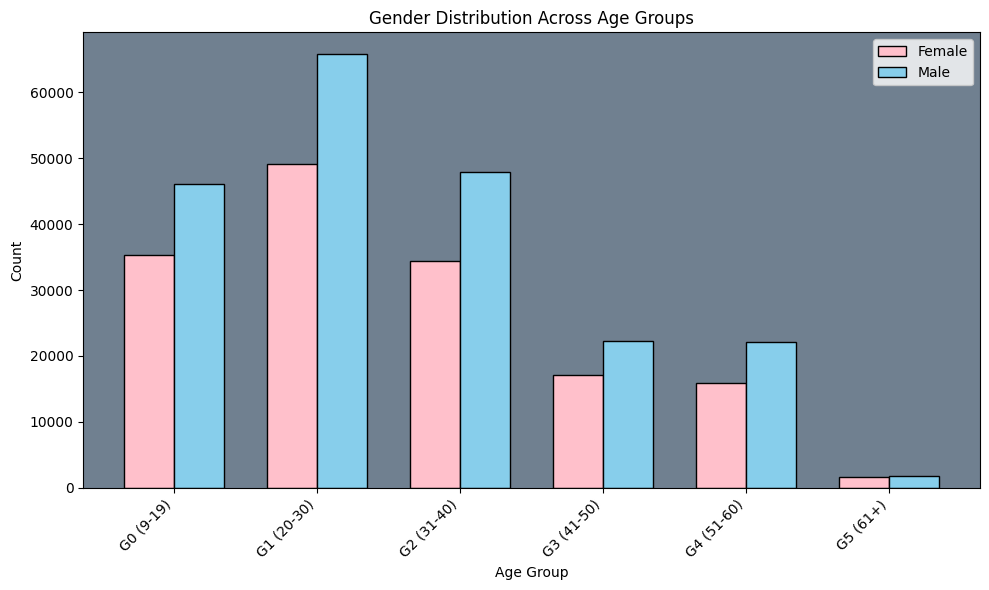

In [194]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of females in age groups
female_counts = master1_df[master1_df['Gender'] == 'Female'].groupby('Age_Group')['Gender'].count()

# Calculate the number of males in age groups
male_counts = master1_df[master1_df['Gender'] == 'Male'].groupby('Age_Group')['Gender'].count()

# Create a bar chart
fig, ax = plt.subplots(figsize=(10, 6))  # Adjust figure size as needed

age_groups = female_counts.index.astype(str) # Get unique age groups as strings

bar_width = 0.35  # Width of each bar
x_pos_female = range(len(age_groups))
x_pos_male = [x + bar_width for x in x_pos_female]

# Plot bars for females using x_pos_female
ax.bar(x_pos_female, female_counts, bar_width, label='Female', color='pink',edgecolor='black')

# Plot bars for males using x_pos_male
ax.bar(x_pos_male, male_counts, bar_width, label='Male', color='skyblue', edgecolor='black')

# Set chart title and labels
ax.set_title('Gender Distribution Across Age Groups')
ax.set_xlabel('Age Group')
ax.set_ylabel('Count')
ax.set_xticks([x + bar_width / 2 for x in x_pos_female])  # Set x-tick positions in the middle
ax.set_xticklabels(age_groups, rotation=45, ha='right')  # Set x-tick labels


# Add legend
ax.legend()

# Rotate x-axis labels if needed

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

# Show the chart
plt.tight_layout()
plt.show()

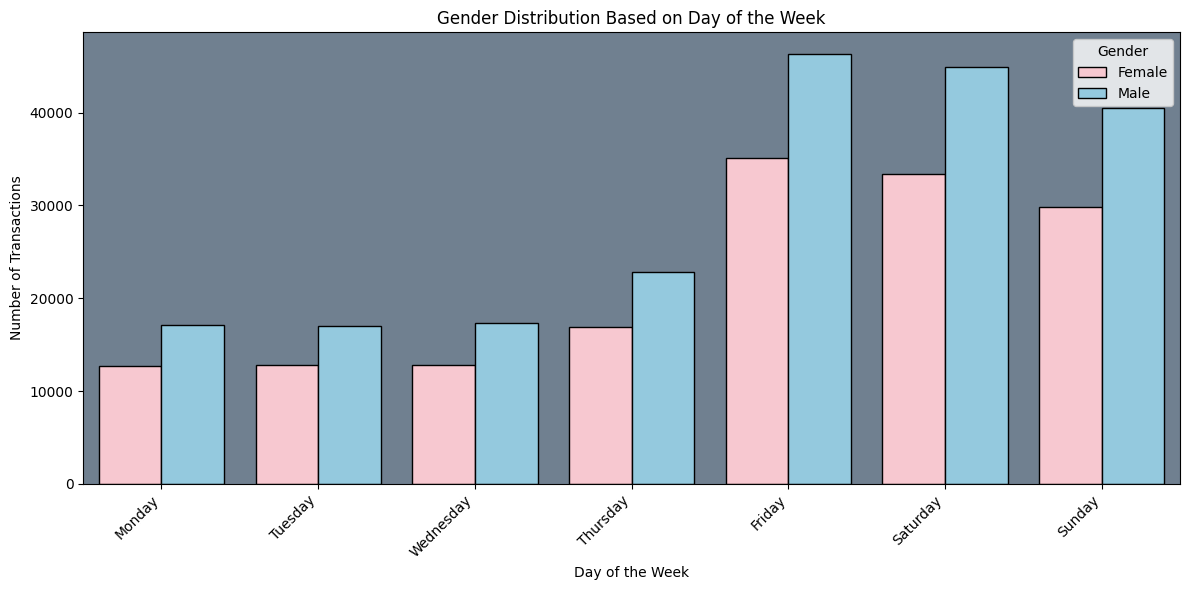

In [195]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group data by day of the week and gender, then count occurrences
gender_by_day = master1_df.groupby(['day_name', 'Gender'])['Transaction ID'].count().reset_index()

# Define the desired order of days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Convert 'day_name' to categorical with ordered days
gender_by_day['day_name'] = pd.Categorical(gender_by_day['day_name'], categories=day_order, ordered=True)

# Create the bar plot using seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='day_name', y='Transaction ID', hue='Gender', data=gender_by_day,
            palette={'Male': 'skyblue', 'Female': 'pink'}, edgecolor='black', order=day_order)

plt.title('Gender Distribution Based on Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

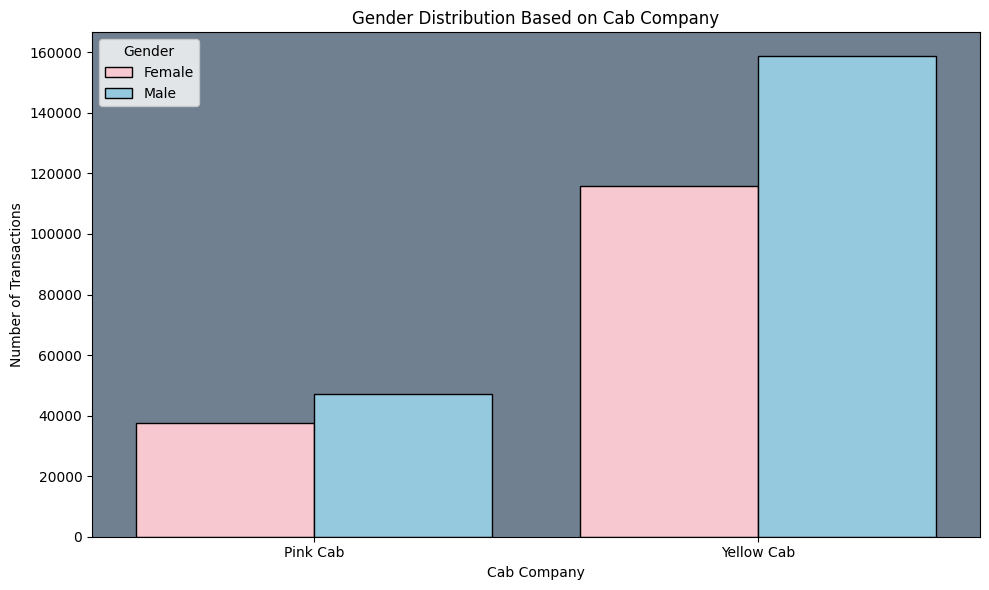

In [196]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group data by Company and Gender, then count occurrences
gender_by_company = master1_df.groupby(['Company', 'Gender'])['Transaction ID'].count().reset_index()

# Create the bar plot using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Company', y='Transaction ID', hue='Gender', data=gender_by_company,
            palette={'Male': 'skyblue', 'Female': 'pink'}, edgecolor='black')

plt.title('Gender Distribution Based on Cab Company')
plt.xlabel('Cab Company')
plt.ylabel('Number of Transactions')

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

In [197]:
# Calculate the number of females that use Pink Cab
pink_cab_female_count = master1_df[(master1_df['Gender'] == 'Female') & (master1_df['Company'] == 'Pink Cab')].shape[0]
print("Pink Cab Female Count:", pink_cab_female_count)


Pink Cab Female Count: 37480


In [198]:
# Calculate the number of males that use Pink Cab
pink_cab_male_count = master1_df[(master1_df['Gender'] == 'Male') & (master1_df['Company'] == 'Pink Cab')].shape[0]
print("Pink Cab Male Count:", pink_cab_male_count)

Pink Cab Male Count: 47231


In [199]:
percent_female_pink = (pink_cab_female_count/(pink_cab_female_count + pink_cab_male_count)) * 100
print("Pink Cab Female Percent:", percent_female_pink)

Pink Cab Female Percent: 44.244549114046585


In [200]:
# Calculate the number of females that use Yellow Cab
yellow_cab_female_count = master1_df[(master1_df['Gender'] == 'Female') & (master1_df['Company'] == 'Yellow Cab')].shape[0]
print("Yellow Cab Female Count:", yellow_cab_female_count)

Yellow Cab Female Count: 116000


In [201]:
# Calculate the number of males that use Yellow Cab
yellow_cab_male_count = master1_df[(master1_df['Gender'] == 'Male') & (master1_df['Company'] == 'Yellow Cab')].shape[0]
print("Yellow Cab Male Count:", yellow_cab_male_count)

Yellow Cab Male Count: 158681


In [204]:
percent_female_yellow = (yellow_cab_female_count/(yellow_cab_female_count + yellow_cab_male_count)) * 100
print("Yellow Cab Female Percent:", percent_female_yellow)

Yellow Cab Female Percent: 42.23080591668153


In [203]:
# Calculate percent distribution of females for pink Cab
pink_cab_female_percent = (pink_cab_df[pink_cab_df['Gender'] == 'Female'].shape[0] / pink_cab_df.shape[0]) * 100
print("Pink Cab Female Percent:", pink_cab_female_percent)

Pink Cab Female Percent: 44.244549114046585


In [177]:
# Calculate percent distribution of females for yellow Cab
yellow_cab_female_percent = (yellow_cab_df[yellow_cab_df['Gender'] == 'Female'].shape[0] / yellow_cab_df.shape[0]) * 100
print("Yellow Cab Female Percent:", yellow_cab_female_percent)

Yellow Cab Female Percent: 42.23080591668153


In [209]:
# customer Id nunique
master1_df['Customer ID'].nunique()

46148

In [211]:
# Group customers that are male
male_customers_df = master1_df[master1_df['Gender'] == 'Male']
male_customers_df.head()

,index,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,...,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled,Age_Group
0,0,10000011,42377,2016-01-08,Pink Cab,ATLANTA GA,30.45,370.95,313.635,2016-01-08,...,Card,Male,28,10813,"814,885","24,701",57.315,1.882266,18.924798,G1 (20-30)
1,1,10000012,42375,2016-01-06,Pink Cab,ATLANTA GA,28.62,358.52,334.854,2016-01-06,...,Card,Male,27,9237,"814,885","24,701",23.666,0.826904,17.787446,G1 (20-30)
2,2,10000013,42371,2016-01-02,Pink Cab,ATLANTA GA,9.04,125.20,97.632,2016-01-02,...,Cash,Male,53,11242,"814,885","24,701",27.568,3.049558,5.618397,G3 (41-50)
3,3,10000014,42376,2016-01-07,Pink Cab,ATLANTA GA,33.17,377.40,351.602,2016-01-07,...,Cash,Male,23,23327,"814,885","24,701",25.798,0.777751,20.615289,G0 (9-19)
4,4,10000015,42372,2016-01-03,Pink Cab,ATLANTA GA,8.73,114.62,97.776,2016-01-03,...,Card,Male,33,8536,"814,885","24,701",16.844,1.929439,5.425730,G1 (20-30)


In [212]:
# Group customers that are female
female_customers_df = master1_df[master1_df['Gender'] == 'Female']
female_customers_df.head()

,index,Transaction ID,Date of Travel,Date Time Stamp,Company,City,KM Travelled,Price Charged,Cost of Trip,date,...,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users,Profit,Profit Per KM,Miles Travelled,Age_Group
3430,3430,10004390,42397,2016-01-28,Pink Cab,SAN DIEGO CA,22.00,213.66,264.000,2016-01-28,...,Cash,Female,40,19131,"959,307","69,995",-50.340,-2.288182,13.673089,G2 (31-40)
3431,3431,10004391,42393,2016-01-24,Pink Cab,SAN DIEGO CA,31.92,400.01,354.312,2016-01-24,...,Card,Female,49,7479,"959,307","69,995",45.698,1.431642,19.838409,G3 (41-50)
3433,3433,10004393,42396,2016-01-27,Pink Cab,SAN DIEGO CA,25.30,297.01,288.420,2016-01-27,...,Cash,Female,62,6163,"959,307","69,995",8.590,0.339526,15.724052,G4 (51-60)
3434,3434,10004394,42400,2016-01-31,Pink Cab,SAN DIEGO CA,9.60,106.55,101.760,2016-01-31,...,Card,Female,22,3867,"959,307","69,995",4.790,0.498958,5.966439,G0 (9-19)
3436,3436,10004396,42392,2016-01-23,Pink Cab,SAN DIEGO CA,18.19,227.95,216.461,2016-01-23,...,Card,Female,31,17012,"959,307","69,995",11.489,0.631611,11.305158,G1 (20-30)


In [217]:
# Check the number of unique customers

print("Number of unique Male Customers:", male_customers_df['Customer ID'].nunique())
print("Number of unique Female Customers:", female_customers_df['Customer ID'].nunique())
print("Total Number of unique Customers:", master1_df['Customer ID'].nunique())


Number of unique Male Customers: 24675
Number of unique Female Customers: 21473
Total Number of unique Customers: 46148


In [218]:
unique_females = female_customers_df['Customer ID'].nunique()
unique_males = male_customers_df['Customer ID'].nunique()
total_unique_customers = master1_df['Customer ID'].nunique()

female_customers = female_customers_df.shape[0]
male_customers = male_customers_df.shape[0]
total_customers= master1_df.shape[0]

returning_female_customers = female_customers - unique_females
returning_male_customers = male_customers - unique_males
returning_total_customers = total_customers - total_unique_customers

print("Number of unique Female Customers:", unique_females)
print("Number of unique Male Customers:", unique_males)
print("Total Number of unique Customers:", total_unique_customers)

print("Number of returning Female Customers:", returning_female_customers)
print("Number of returning Male Customers:", returning_male_customers)
print("Total Number of returning Customers:", returning_total_customers)


Number of unique Female Customers: 21473
Number of unique Male Customers: 24675
Total Number of unique Customers: 46148
Number of returning Female Customers: 132007
Number of returning Male Customers: 181237
Total Number of returning Customers: 313244


In [226]:
unique_females = female_customers_df['Customer ID'].nunique()
unique_males = male_customers_df['Customer ID'].nunique()
total_unique_customers = master1_df['Customer ID'].nunique()

female_customers = female_customers_df.shape[0]
male_customers = male_customers_df.shape[0]
total_customers= master1_df.shape[0]

# Calculate the number of returning customers for each category
returning_female_customers = female_customers - unique_females
returning_male_customers = male_customers - unique_males
returning_total_customers = total_customers - total_unique_customers

#Add Total number of unique customers and returning customers
all_customers= total_unique_customers + returning_total_customers

#Fix: Use the calculated integer values instead of the DataFrames
all_females = unique_females + returning_female_customers
all_males = unique_males + returning_male_customers
print("Total Number of Customers:", all_customers)
print("Total Number of Females:", all_females)
print("Total Number of Males:", all_males)

Total Number of Customers: 359392
Total Number of Females: 153480
Total Number of Males: 205912


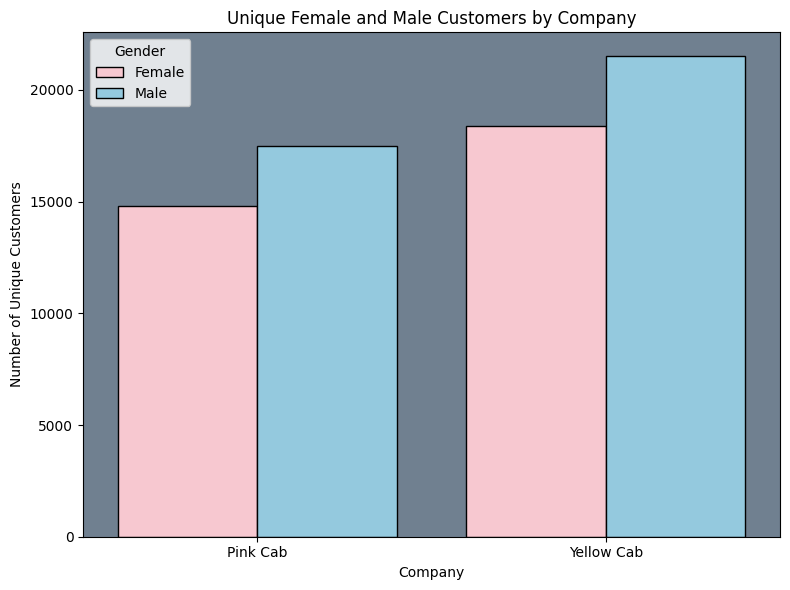

In [219]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for female and male customers
female_customers_df = master1_df[master1_df['Gender'] == 'Female']
male_customers_df = master1_df[master1_df['Gender'] == 'Male']

# Calculate unique customers for each company and gender
unique_customers = pd.DataFrame({
    'Company': pd.concat([female_customers_df['Company'], male_customers_df['Company']]),
    'Gender': pd.concat([female_customers_df['Gender'], male_customers_df['Gender']]),
    'Customer ID': pd.concat([female_customers_df['Customer ID'], male_customers_df['Customer ID']])
}).groupby(['Company', 'Gender'])['Customer ID'].nunique().reset_index()

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='Company', y='Customer ID', hue='Gender', data=unique_customers,
            palette={'Female': 'pink', 'Male': 'skyblue'}, edgecolor='black')

plt.title('Unique Female and Male Customers by Company')
plt.xlabel('Company')
plt.ylabel('Number of Unique Customers')

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

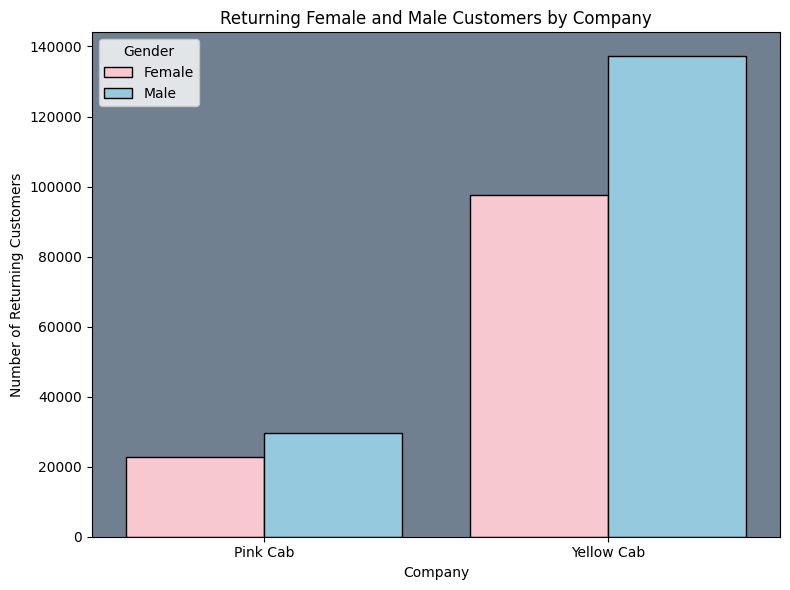

In [220]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for female and male customers
female_customers_df = master1_df[master1_df['Gender'] == 'Female']
male_customers_df = master1_df[master1_df['Gender'] == 'Male']

# Calculate returning customers for each company and gender
def calculate_returning_customers(df):
    total_customers = df.groupby('Company')['Customer ID'].size().reset_index()
    unique_customers = df.groupby('Company')['Customer ID'].nunique().reset_index()
    returning_customers = pd.merge(total_customers, unique_customers, on='Company', suffixes=('_total', '_unique'))
    returning_customers['Returning_Customers'] = returning_customers['Customer ID_total'] - returning_customers['Customer ID_unique']
    return returning_customers[['Company', 'Returning_Customers']]

returning_female_customers = calculate_returning_customers(female_customers_df)
returning_female_customers['Gender'] = 'Female'
returning_male_customers = calculate_returning_customers(male_customers_df)
returning_male_customers['Gender'] = 'Male'

returning_customers = pd.concat([returning_female_customers, returning_male_customers])

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='Company', y='Returning_Customers', hue='Gender', data=returning_customers,
            palette={'Female': 'pink', 'Male': 'skyblue'}, edgecolor='black')

plt.title('Returning Female and Male Customers by Company')
plt.xlabel('Company')
plt.ylabel('Number of Returning Customers')

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

In [227]:
# Filter for female customers
female_customers_df = master1_df[master1_df['Gender'] == 'Female']

# Pink Cab returning female customers
pink_cab_female_df = female_customers_df[female_customers_df['Company'] == 'Pink Cab']
unique_pink_cab_females = pink_cab_female_df['Customer ID'].nunique()
total_pink_cab_females = pink_cab_female_df.shape[0]
returning_pink_cab_females = total_pink_cab_females - unique_pink_cab_females

# Yellow Cab returning female customers
yellow_cab_female_df = female_customers_df[female_customers_df['Company'] == 'Yellow Cab']
unique_yellow_cab_females = yellow_cab_female_df['Customer ID'].nunique()
total_yellow_cab_females = yellow_cab_female_df.shape[0]
returning_yellow_cab_females = total_yellow_cab_females - unique_yellow_cab_females

print("Number of returning female customers for Pink Cab:", returning_pink_cab_females)
print("Number of returning female customers for Yellow Cab:", returning_yellow_cab_females)


Number of returning female customers for Pink Cab: 22661
Number of returning female customers for Yellow Cab: 97606


In [231]:
# Calculte the percent of returning female cutomers for Pink Cab
pink_cab_female_percent = (returning_pink_cab_females / total_pink_cab_females) * 100
print("Percent of returning female customers for Pink Cab:", pink_cab_female_percent)

Percent of returning female customers for Pink Cab: 60.461579509071505


In [234]:
# Calculte the percent of returning female cutomers for Yellow Cab
yellow_cab_female_percent = (returning_yellow_cab_females / total_yellow_cab_females) * 100
print("Percent of returning female customers for Yellow Cab:", yellow_cab_female_percent)

Percent of returning female customers for Yellow Cab: 84.14310344827585


<ipython-input-233-30823944f4ee>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company', y='Returning Female Customers (%)', data=df,


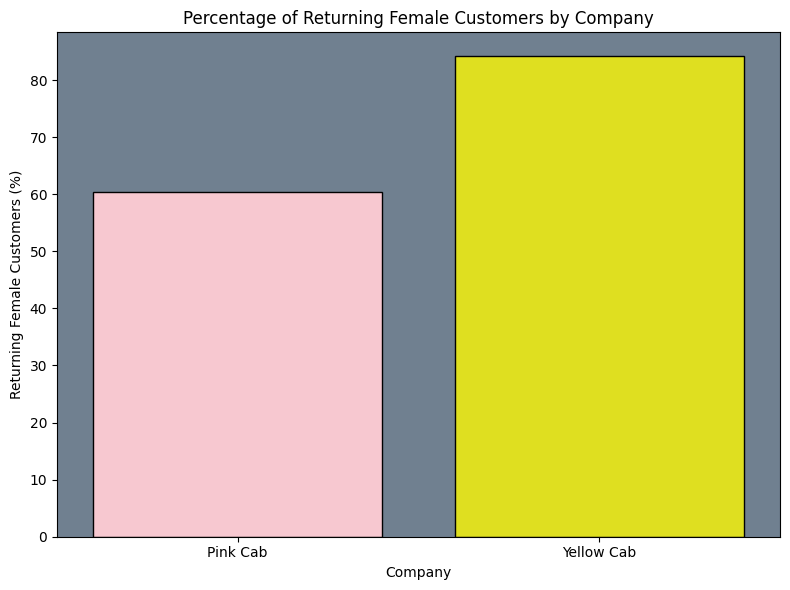

In [233]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ... (Your existing code to calculate returning_pink_cab_females, returning_yellow_cab_females,
#      total_pink_cab_females, and total_yellow_cab_females) ...

# Calculate percentages
pink_cab_female_percent = (returning_pink_cab_females / total_pink_cab_females) * 100
yellow_cab_female_percent = (returning_yellow_cab_females / total_yellow_cab_females) * 100

# Create a DataFrame for the bar chart
data = {
    'Company': ['Pink Cab', 'Yellow Cab'],
    'Returning Female Customers (%)': [pink_cab_female_percent, yellow_cab_female_percent]
}
df = pd.DataFrame(data)

# Create the bar chart
plt.figure(figsize=(8, 6))  # Adjust figure size as needed
sns.barplot(x='Company', y='Returning Female Customers (%)', data=df,
            palette={'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}, edgecolor='black')
plt.title('Percentage of Returning Female Customers by Company')
plt.xlabel('Company')
plt.ylabel('Returning Female Customers (%)')

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

<ipython-input-230-d9cd53420ea9>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company', y='Returning Female Customers', data=df,


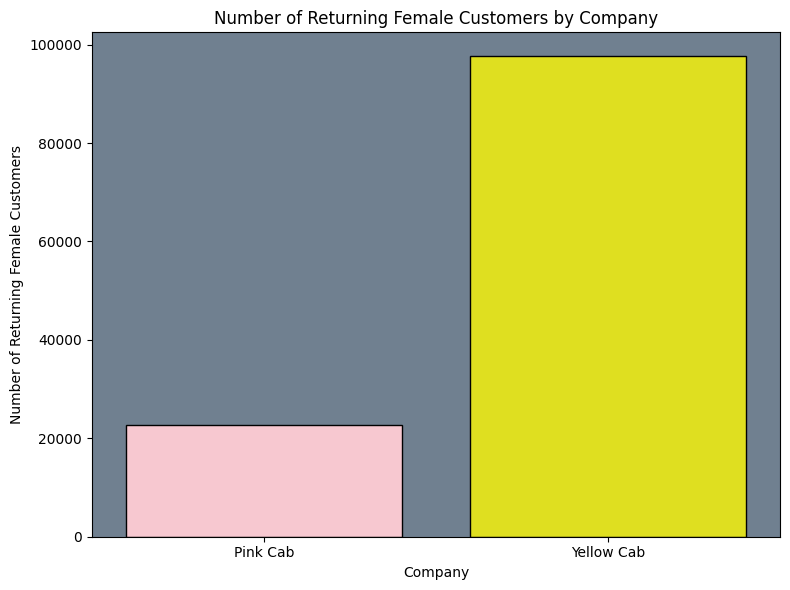

In [230]:
import matplotlib.pyplot as plt
import seaborn as sns

# ... (Your existing code to calculate returning_pink_cab_females and returning_yellow_cab_females) ...

# Create a DataFrame for the bar chart
data = {
    'Company': ['Pink Cab', 'Yellow Cab'],
    'Returning Female Customers': [returning_pink_cab_females, returning_yellow_cab_females]
}
df = pd.DataFrame(data)

# Create the bar chart
plt.figure(figsize=(8, 6))  # Adjust figure size as needed
sns.barplot(x='Company', y='Returning Female Customers', data=df,
            palette={'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}, edgecolor='black')
plt.title('Number of Returning Female Customers by Company')
plt.xlabel('Company')
plt.ylabel('Number of Returning Female Customers')

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

# **Hypothesis 12 Results**

The total number of customers is 359,392. The total number of female customers is 153,480 and the total number of male customers is 205912. The total number of female riders that rode a cab just once was 21,473. The total number of male riders that rode a cab just once was 24,675. The total number of return female customers was 132,007. The total number of return male customers was 181237. Percentwise, Pink Cab has 60.5% return female riders and Yellow Cab has 84.1% return female riders.

Reject Hypothesis 12:Percentwise, more women take Pink Cab than Yellow Cab as return riders.


# **Hypothesis 13: The majority of cab riders are men**

In [205]:
# Calculate the number of Female riders in master1_df
female_count = master1_df[master1_df['Gender'] == 'Female'].shape[0]
print("Female Count:", female_count)


Female Count: 153480


In [206]:
# calculate the number of Male riders in master1_df
male_count = master1_df[master1_df['Gender'] == 'Male'].shape[0]
print("Male Count:", male_count)

Male Count: 205912


In [207]:
# Calculate the total number of riders in master1_df
total_riders = female_count + male_count
print("Total Riders:", total_riders)

Total Riders: 359392


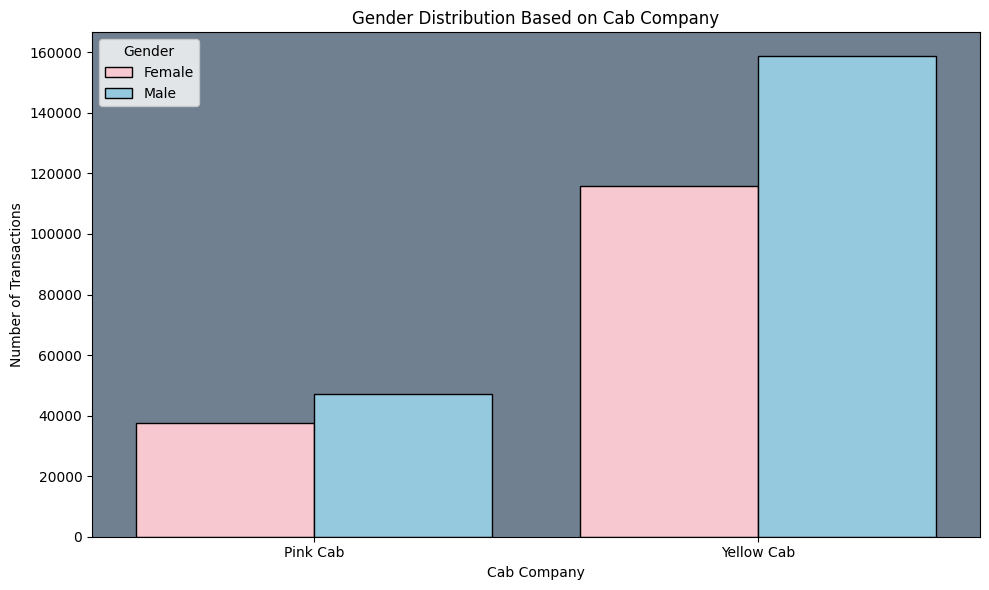

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group data by Company and Gender, then count occurrences
gender_by_company = master1_df.groupby(['Company', 'Gender'])['Transaction ID'].count().reset_index()

# Create the bar plot using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Company', y='Transaction ID', hue='Gender', data=gender_by_company,
            palette={'Male': 'skyblue', 'Female': 'pink'}, edgecolor='black')

plt.title('Gender Distribution Based on Cab Company')
plt.xlabel('Cab Company')
plt.ylabel('Number of Transactions')

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

plt.tight_layout()
plt.show()

## **Hypothesis 13 Results**

During the time period of 1-31-2016 to 12-31-2018, the total number of riders was 359392. The number of male riders was 205912 and the number of female riders was 153480.

Accept Hypothesis 13: The majority of cab riders are men.

# **Hypothesis 14: The majority of cab riders are the ages between 20 and 30**

In [178]:
# Compare ages
ages = (master1_df['Age'].value_counts())

# sort ages
ages = ages.sort_index()
print(ages)

Age
18    10846
19    11591
20    12229
21    11431
22    11796
23    12327
24    11151
25    11973
26    11655
27    12030
28    11163
29    10675
30    11165
31    10930
32    11959
33    11457
34    11825
35    10555
36    11054
37    11086
38    10906
39    11798
40    11536
41     3852
42     3970
43     3823
44     3725
45     4248
46     3918
47     4087
48     3700
49     4158
50     4089
51     3931
52     3784
53     3641
54     3810
55     3442
56     3742
57     3473
58     4107
59     4068
60     3775
61     4361
62     3530
63     3733
64     3908
65     3379
Name: count, dtype: int64


In [179]:
# vicenarian 20-29, tricenarian 30-39
# quadrigenarian 40-49, quinquagenarian 50-59, sexagenarian 60-69
# break down ages by groups
# 18-24, 25-34, 35-44, 45-54, 55-65


g0 = master1_df[(master1_df['Age'] >=18) & (master1_df['Age'] <=24)]
g1 = master1_df[(master1_df['Age'] >=24) & (master1_df['Age'] <=34)]
g2 = master1_df[(master1_df['Age'] >=35) & (master1_df['Age'] <=44)]
g3 = master1_df[(master1_df['Age'] >=45) & (master1_df['Age'] <=54)]
g4 = master1_df[(master1_df['Age'] >=55) & (master1_df['Age'] <=64)]
g5 = master1_df[(master1_df['Age'] >=65)]

print("group 0:",g0['Age'].value_counts().sort_index())
print("group 1:",g1['Age'].value_counts().sort_index())
print("group 2:",g2['Age'].value_counts().sort_index())
print("group 3:",g3['Age'].value_counts().sort_index())
print("group 4:",g4['Age'].value_counts().sort_index())
print("group 5:",g5['Age'].value_counts().sort_index())

group 0: Age
18    10846
19    11591
20    12229
21    11431
22    11796
23    12327
24    11151
Name: count, dtype: int64
group 1: Age
24    11151
25    11973
26    11655
27    12030
28    11163
29    10675
30    11165
31    10930
32    11959
33    11457
34    11825
Name: count, dtype: int64
group 2: Age
35    10555
36    11054
37    11086
38    10906
39    11798
40    11536
41     3852
42     3970
43     3823
44     3725
Name: count, dtype: int64
group 3: Age
45    4248
46    3918
47    4087
48    3700
49    4158
50    4089
51    3931
52    3784
53    3641
54    3810
Name: count, dtype: int64
group 4: Age
55    3442
56    3742
57    3473
58    4107
59    4068
60    3775
61    4361
62    3530
63    3733
64    3908
Name: count, dtype: int64
group 5: Age
65    3379
Name: count, dtype: int64


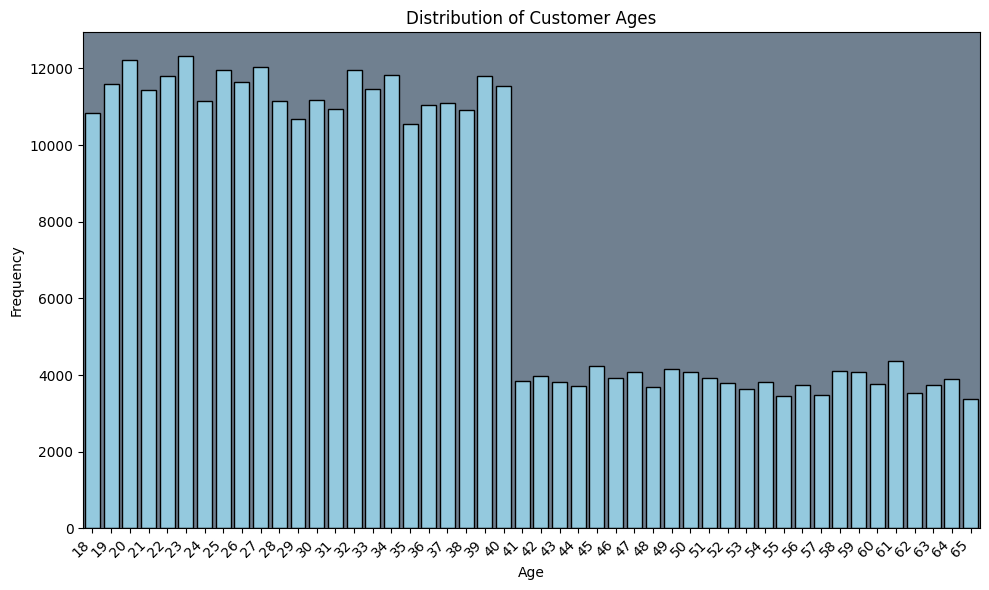

In [180]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sort customer ages and get their frequencies
age_counts = master1_df['Age'].sort_values().value_counts()

# Create a bar chart using seaborn
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.barplot(x=age_counts.index, y=age_counts.values, color='skyblue', edgecolor='black')

plt.title('Distribution of Customer Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

# Rotate x-axis labels if needed
plt.xticks(rotation=45, ha='right')  # Adjust rotation as needed

plt.tight_layout()
plt.show()

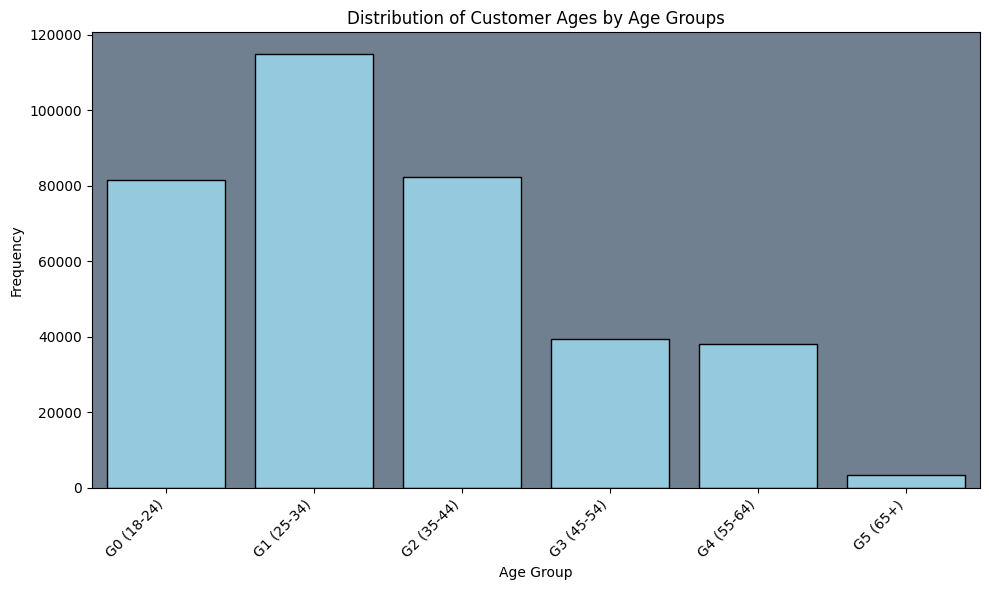

In [181]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define age group boundaries
age_bins = [18, 25, 35, 45, 55, 65, 100]  # Adjust as needed
age_labels = ['G0 (18-24)', 'G1 (25-34)', 'G2 (35-44)', 'G3 (45-54)', 'G4 (55-64)', 'G5 (65+)']

# Create age groups
master1_df['Age_Group'] = pd.cut(master1_df['Age'], bins=age_bins, labels=age_labels, right=False)

# Get the distribution of customers in each age group
age_group_counts = master1_df['Age_Group'].value_counts().sort_index()

# Create a bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, color='skyblue', edgecolor='black')

plt.title('Distribution of Customer Ages by Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Frequency')

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

# Rotate x-axis labels if needed
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

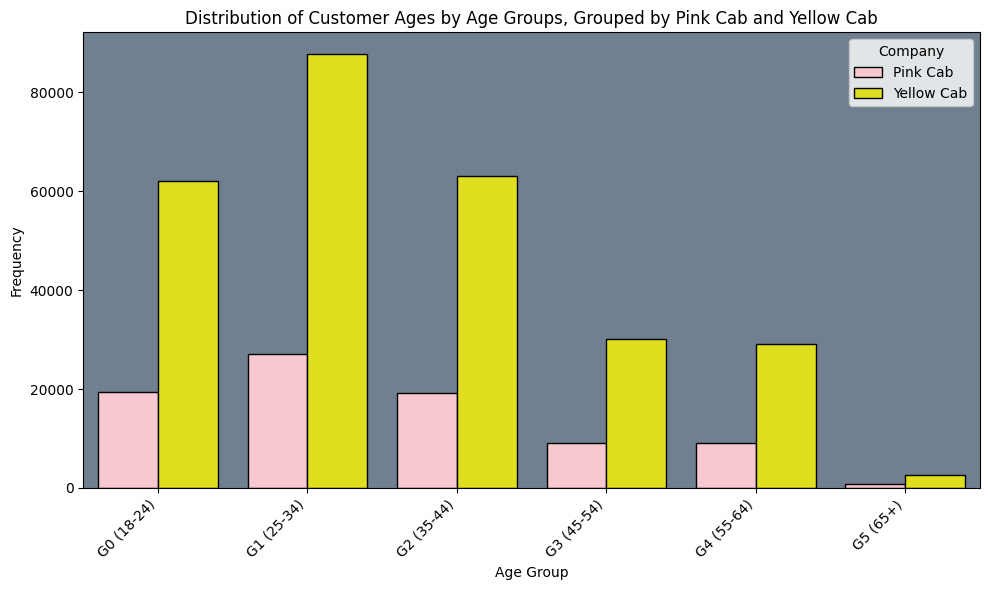

In [185]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define age group boundaries
age_bins = [18, 25, 35, 45, 55, 65, 100]  # Adjust as needed
age_labels = ['G0 (18-24)', 'G1 (25-34)', 'G2 (35-44)', 'G3 (45-54)', 'G4 (55-64)', 'G5 (65+)']

# Create age groups
master1_df['Age_Group'] = pd.cut(master1_df['Age'], bins=age_bins, labels=age_labels, right=False)

# Create a bar chart using seaborn, grouped by company
plt.figure(figsize=(10, 6))
sns.countplot(x='Age_Group', hue='Company', data=master1_df,
              palette={'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}, edgecolor='black',
              order=age_labels)  # Order by age group labels

plt.title('Distribution of Customer Ages by Age Groups, Grouped by Pink Cab and Yellow Cab')
plt.xlabel('Age Group')
plt.ylabel('Frequency')

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

# Rotate x-axis labels if needed
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

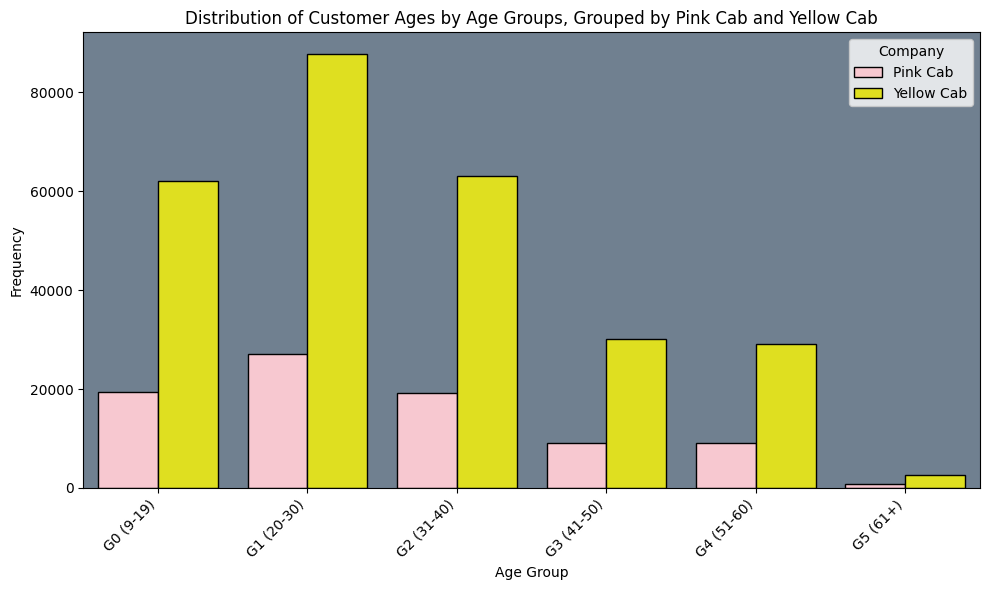

In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define age group boundaries
age_bins = [18, 25, 35, 45, 55, 65, 100]  # Adjust as needed
age_labels = ['G0 (9-19)', 'G1 (20-30)', 'G2 (31-40)', 'G3 (41-50)', 'G4 (51-60)', 'G5 (61+)']

# Create age groups
master1_df['Age_Group'] = pd.cut(master1_df['Age'], bins=age_bins, labels=age_labels, right=False)

# Create a bar chart using seaborn, grouped by company
plt.figure(figsize=(10, 6))
sns.countplot(x='Age_Group', hue='Company', data=master1_df,
              palette={'Pink Cab': 'pink', 'Yellow Cab': 'yellow'}, edgecolor='black',
              order=age_labels)  # Order by age group labels

plt.title('Distribution of Customer Ages by Age Groups, Grouped by Pink Cab and Yellow Cab')
plt.xlabel('Age Group')
plt.ylabel('Frequency')

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

# Rotate x-axis labels if needed
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

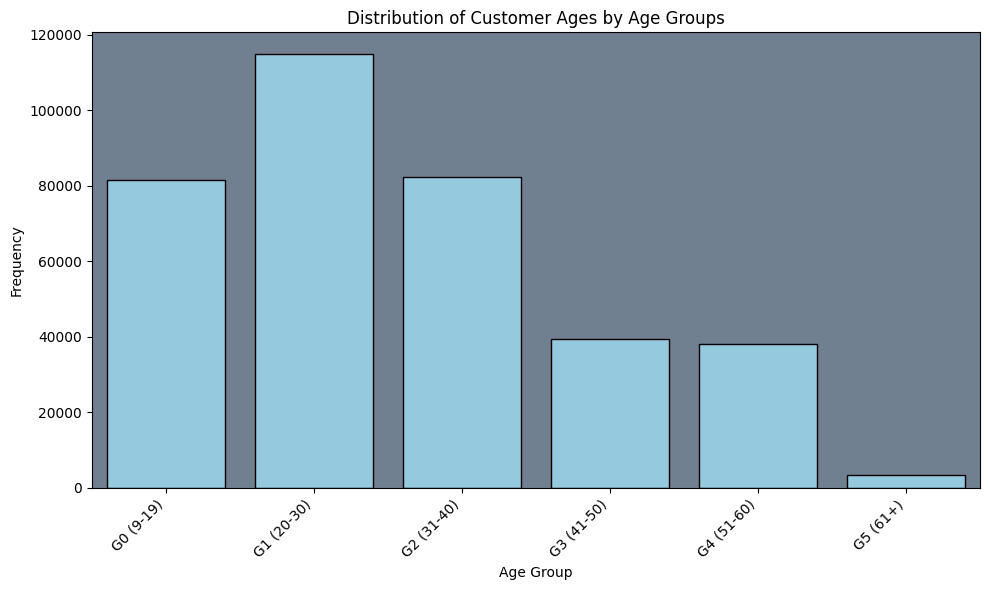

In [184]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define age group boundaries
age_bins = [18, 25, 35, 45, 55, 65, 100]  # Adjust as needed
age_labels = ['G0 (9-19)', 'G1 (20-30)', 'G2 (31-40)', 'G3 (41-50)', 'G4 (51-60)', 'G5 (61+)']

# Create age groups
master1_df['Age_Group'] = pd.cut(master1_df['Age'], bins=age_bins, labels=age_labels, right=False)

# Get the distribution of customers in each age group
age_group_counts = master1_df['Age_Group'].value_counts().sort_index()

# Create a bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, color='skyblue', edgecolor='black')

plt.title('Distribution of Customer Ages by Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Frequency')

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

# Rotate x-axis labels if needed
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

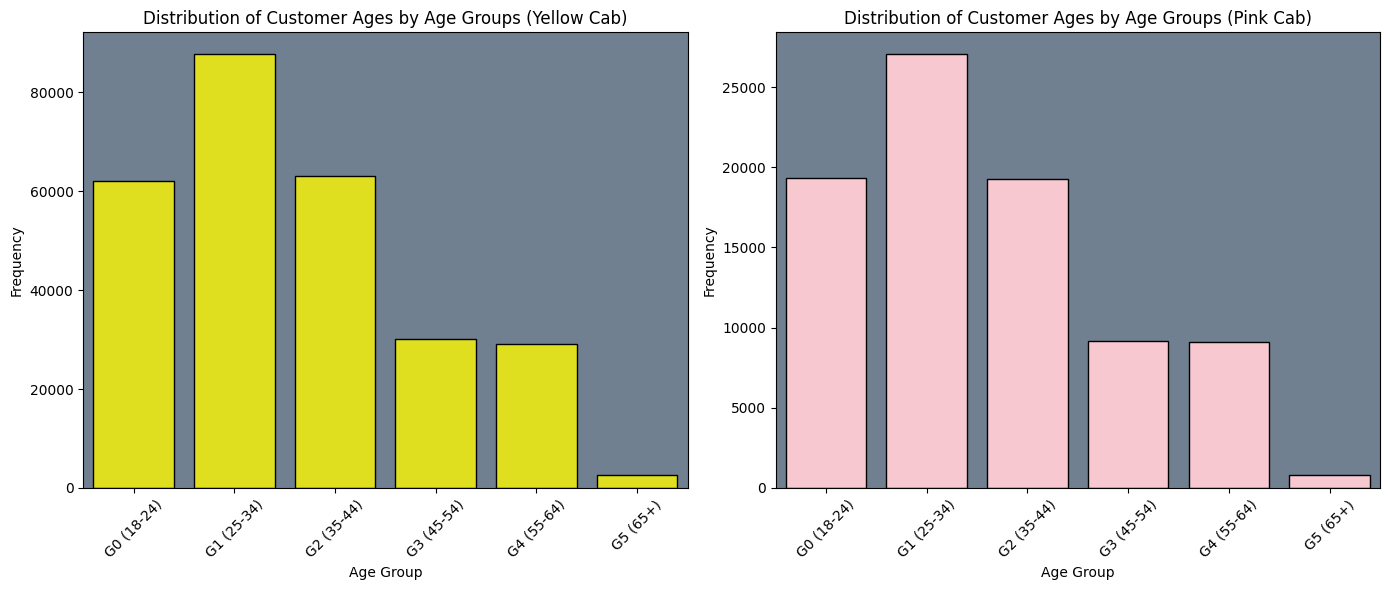

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define age group boundaries
age_bins = [18, 25, 35, 45, 55, 65, 100]  # Adjust as needed
age_labels = ['G0 (18-24)', 'G1 (25-34)', 'G2 (35-44)', 'G3 (45-54)', 'G4 (55-64)', 'G5 (65+)']

# Create age groups for the entire dataset
master1_df['Age_Group'] = pd.cut(master1_df['Age'], bins=age_bins, labels=age_labels, right=False)

# Filter data for Yellow Cab and Pink Cab
yellow_cab_df = master1_df[master1_df['Company'] == 'Yellow Cab']
pink_cab_df = master1_df[master1_df['Company'] == 'Pink Cab']

# Get age group distributions for each company
yellow_cab_age_group_counts = yellow_cab_df['Age_Group'].value_counts().sort_index()
pink_cab_age_group_counts = pink_cab_df['Age_Group'].value_counts().sort_index()

# Create bar charts using seaborn
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns of subplots

# Yellow Cab bar chart
sns.barplot(x=yellow_cab_age_group_counts.index, y=yellow_cab_age_group_counts.values,
            color='yellow', edgecolor='black', ax=axes[0])
axes[0].set_title('Distribution of Customer Ages by Age Groups (Yellow Cab)')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Frequency')
axes[0].set_facecolor('slategray')
axes[0].tick_params(axis='x', rotation=45)

# Pink Cab bar chart
sns.barplot(x=pink_cab_age_group_counts.index, y=pink_cab_age_group_counts.values,
            color='pink', edgecolor='black', ax=axes[1])
axes[1].set_title('Distribution of Customer Ages by Age Groups (Pink Cab)')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Frequency')
axes[1].set_facecolor('slategray')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<ipython-input-183-5502c5650be6>:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_counts = master1_df.groupby(['Company', 'Age_Group'])['Age'].count().reset_index(name='Count')


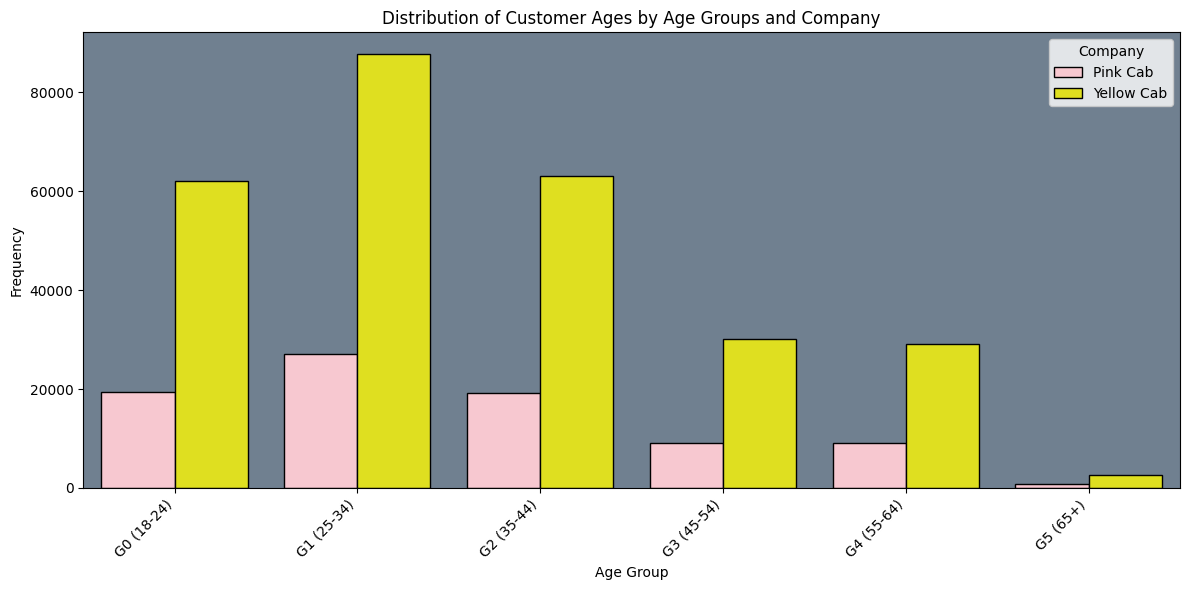

In [183]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define age group boundaries
age_bins = [18, 25, 35, 45, 55, 65, 100]  # Adjust as needed
age_labels = ['G0 (18-24)', 'G1 (25-34)', 'G2 (35-44)', 'G3 (45-54)', 'G4 (55-64)', 'G5 (65+)']

# Create age groups for the entire dataset
master1_df['Age_Group'] = pd.cut(master1_df['Age'], bins=age_bins, labels=age_labels, right=False)

# Get age group distributions for each company
age_group_counts = master1_df.groupby(['Company', 'Age_Group'])['Age'].count().reset_index(name='Count')

# Create a grouped bar chart using seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Age_Group', y='Count', hue='Company', data=age_group_counts,
            palette={'Yellow Cab': 'yellow', 'Pink Cab': 'pink'}, edgecolor='black')

plt.title('Distribution of Customer Ages by Age Groups and Company')
plt.xlabel('Age Group')
plt.ylabel('Frequency')

# Set background color
ax = plt.gca()
ax.set_facecolor('slategray')

# Rotate x-axis labels if needed
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## **Hypothesis 14 Results**

The greatest number of riders is are in the age range of 20-30. The least number of riders is in the age range of 61+.

Accept Hypothesis 14: The majority of cab riders are the ages between 20 and 30.

# **Summary**

Both Yellow Cab and Pink Cab serve all 19 cities. Yellow Cab does a higher volume of business than Pink Cab. Yellow Cab has higher profit per KM than pink Cab Company. There is annual seasonality to the cab businiess. The winter months have higher ridership than the other seasons. There is weekly seasonality to to the cab business. Friday is the busiest day. Monday is the least busy day. There is a lot more business on the weekends than the weekdays. More men ride cabs than women. The age range most likely to ride cabs is the age range of 20-30 years. Yellow Cab does double the profit per kilometer than Pink Cab. In Female ridership, 84% female riders of Yellow Cab are return Riders and only 60% female riders are return riders for Pink Cab.

# **Recommendation**

It is recommended that XYZ company acquire Yellow Cab company.